## Exploratory Data Analysis

##### TODO
- organise files and folders
- split config and settings
- create file with functions
- organise Results

#### Configuration

In [71]:
#_____________________________________________________
from dotenv import load_dotenv
import os 
load_dotenv()  # reads .env file
#_____________________________________________________

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from datetime import datetime
from IPython.display import display, HTML
from urllib.parse import urlsplit

#### Functions

In [72]:
# Tables loading function based on the open connection to the database and list of table names
def tab_load(engine, tables):
    tabs_dict = {}
    for tab_name in tables:
        query = f"SELECT * FROM {tab_name}"
        tabs_dict[tab_name] = pd.read_sql_query(query, con=engine)
    return tabs_dict

In [80]:
# Chi-square estimation

def chi_square_with_target(df, target_col):
    """
    Perform chi-square test of independence between a target categorical column 
    and all other columns in the DataFrame.
    """
    results = []
    
    # Ensure target column is categorical or object type
    if df[target_col].dtype not in ['object', 'category', 'int']:
        raise ValueError("Target column must be categorical or integer.")

    for col in df.columns:
        if col == target_col:
            continue
            
        # Skip non-categorical columns (continuous numeric data is not suitable for chi-square)
        if df[col].dtype not in ['object', 'category', 'int']:
            continue
            
        # Drop rows with NaN in either column
        valid_mask = df[[target_col, col]].notna().all(axis=1)
        sub_df = df.loc[valid_mask, [target_col, col]]
        
        # Create contingency table
        contingency_table = pd.crosstab(sub_df[target_col], sub_df[col])
        
        # Perform chi-square test
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        
        results.append({
            'target_column': target_col,
            'compared_column': col,
            'chi2_statistic': round(chi2, 2),
            'p_value': p,
            'degrees_of_freedom': dof
        })
        
    return pd.DataFrame(results)

In [74]:
#Statistical reporting Block
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy import stats
from scipy.stats import pearsonr, spearmanr, chi2_contingency, boxcox
from IPython.display import display, Image as IPyImage

sns.set_theme(style="whitegrid")

# --------------------------------------------------
# Paths
# Notebook expected in ~/Scripts/
# Results required in ~/Results/
# --------------------------------------------------
SCRIPTS_DIR = Path("~/Scripts").expanduser()
RESULTS_DIR = Path("~/Results").expanduser()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def classify_series_type(s: pd.Series, ordinal_threshold: int = 10) -> str:
    """
    Heuristic type classification for correlation selection.
    numeric   -> continuous numeric
    ordinal   -> integer-like / low-cardinality numeric
    categorical -> object/category/bool
    datetime  -> datetime
    """
    if pd.api.types.is_datetime64_any_dtype(s):
        return "datetime"

    if pd.api.types.is_bool_dtype(s):
        return "categorical"

    if pd.api.types.is_numeric_dtype(s):
        non_null = s.dropna()
        nunique = non_null.nunique()
        if pd.api.types.is_integer_dtype(s) and nunique <= ordinal_threshold:
            return "ordinal"
        return "numeric"

    return "categorical"


def skew_interpretation(skew_value: float) -> str:
    a = abs(skew_value)
    if a < 0.5:
        return "Approximately symmetric."
    elif a < 1.0:
        return "Moderately skewed."
    else:
        return "Highly skewed."


def normality_improvement_text(original_skew: float, transformed_skew: float) -> str:
    orig_abs = abs(original_skew)
    trans_abs = abs(transformed_skew)

    if np.isnan(trans_abs):
        return "Transformation not available."

    if trans_abs < orig_abs - 0.1:
        if trans_abs < 0.5:
            return "Improved strongly; distribution is closer to symmetric."
        return "Improved; skewness decreased."
    elif abs(trans_abs - orig_abs) <= 0.1:
        return "Little change in skewness."
    else:
        return "Did not improve normality; skewness increased."


def prepare_numeric_series(df: pd.DataFrame, target_col: str) -> pd.Series:
    s = pd.to_numeric(df[target_col], errors="coerce")
    s = s.dropna().astype(float)
    if s.empty:
        raise ValueError(f"Column '{target_col}' has no usable numeric values after coercion.")
    return s


def summarize_distribution(s: pd.Series) -> dict:
    n = len(s)
    mean_val = s.mean()
    median_val = s.median()
    std_val = s.std(ddof=1)
    se = std_val / np.sqrt(n) if n > 1 else np.nan
    ci95 = stats.t.ppf(0.975, df=n-1) * se if n > 1 else np.nan

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    skew_val = s.skew()

    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    outliers = s[(s < lower_fence) | (s > upper_fence)]

    return {
        "n": int(n),
        "mean": float(mean_val),
        "median": float(median_val),
        "std": float(std_val),
        "se": float(se) if pd.notna(se) else np.nan,
        "ci95_low": float(mean_val - ci95) if pd.notna(ci95) else np.nan,
        "ci95_high": float(mean_val + ci95) if pd.notna(ci95) else np.nan,
        "q1": float(q1),
        "q3": float(q3),
        "iqr": float(iqr),
        "lower_fence": float(lower_fence),
        "upper_fence": float(upper_fence),
        "outlier_count": int(len(outliers)),
        "skewness": float(skew_val),
        "skewness_interpretation": skew_interpretation(skew_val),
        "outliers": outliers.copy()
    }


def create_value_counts_table(series: pd.Series, column_name: str) -> pd.DataFrame:
    non_null = series.dropna()
    counts = non_null.value_counts(dropna=False, sort=False)

    try:
        counts = counts.sort_index()
    except Exception:
        counts = counts.sort_index(key=lambda idx: idx.astype(str))

    freq = counts / non_null.shape[0] if non_null.shape[0] > 0 else np.nan

    tbl = pd.DataFrame({
        "column": column_name,
        "value": counts.index.astype(str),
        "count": counts.values,
        "frequency_non_null": np.round(freq.values, 6)
    })

    tbl.attrs["number_non_null"] = int(non_null.shape[0])
    tbl.attrs["number_unique"] = int(non_null.nunique(dropna=True))
    return tbl


def create_transformation_skewness_table(s: pd.Series) -> pd.DataFrame:
    rows = []
    original_skew = s.skew()

    rows.append({
        "method": "Original",
        "skewness": original_skew,
        "interpretation": skew_interpretation(original_skew),
        "normality_improvement": "Baseline."
    })

    # Log transformation
    if (s > 0).all():
        log_s = np.log(s)
        log_skew = pd.Series(log_s).skew()
    else:
        shift = 1 - s.min() if s.min() <= 0 else 0
        log_s = np.log(s + shift)
        log_skew = pd.Series(log_s).skew()

    rows.append({
        "method": "Log Transformation",
        "skewness": log_skew,
        "interpretation": skew_interpretation(log_skew),
        "normality_improvement": normality_improvement_text(original_skew, log_skew)
    })

    # Square root transformation
    if (s >= 0).all():
        sqrt_s = np.sqrt(s)
        sqrt_skew = pd.Series(sqrt_s).skew()
    else:
        shift = -s.min()
        sqrt_s = np.sqrt(s + shift)
        sqrt_skew = pd.Series(sqrt_s).skew()

    rows.append({
        "method": "Square Root Transformation",
        "skewness": sqrt_skew,
        "interpretation": skew_interpretation(sqrt_skew),
        "normality_improvement": normality_improvement_text(original_skew, sqrt_skew)
    })

    # Box-Cox transformation
    try:
        if (s > 0).all():
            bc_input = s.copy()
        else:
            shift = 1 - s.min()
            bc_input = s + shift

        bc_values, bc_lambda = boxcox(bc_input)
        bc_skew = pd.Series(bc_values).skew()
        bc_note = f"Improved using lambda={bc_lambda:.4f}." if abs(bc_skew) < abs(original_skew) else f"Lambda={bc_lambda:.4f} did not improve enough."
    except Exception:
        bc_skew = np.nan
        bc_note = "Box-Cox could not be computed."

    rows.append({
        "method": "Box-Cox Transformation",
        "skewness": bc_skew,
        "interpretation": skew_interpretation(bc_skew) if pd.notna(bc_skew) else "Not available.",
        "normality_improvement": normality_improvement_text(original_skew, bc_skew) + f" {bc_note}"
    })

    return pd.DataFrame(rows)


def correlation_table(
    df: pd.DataFrame,
    target_col: str,
    ordinal_threshold: int = 10,
    max_categories: int = 50,
    alpha: float = 0.05
) -> pd.DataFrame:
    target_raw = df[target_col]
    target_type = classify_series_type(target_raw, ordinal_threshold=ordinal_threshold)

    results = []

    for col in df.columns:
        if col == target_col:
            continue

        other = df[col]
        other_type = classify_series_type(other, ordinal_threshold=ordinal_threshold)

        test_name = None
        stat = np.nan
        pval = np.nan
        note = ""

        # Numeric target
        if target_type == "numeric":
            target_num = pd.to_numeric(target_raw, errors="coerce")

            if other_type == "numeric":
                other_num = pd.to_numeric(other, errors="coerce")
                tmp = pd.DataFrame({"x": target_num, "y": other_num}).dropna()
                if len(tmp) >= 3:
                    stat, pval = pearsonr(tmp["x"], tmp["y"])
                    test_name = "Pearson"
                else:
                    note = "Not enough paired non-null values."

            elif other_type == "ordinal":
                other_num = pd.to_numeric(other, errors="coerce")
                tmp = pd.DataFrame({"x": target_num, "y": other_num}).dropna()
                if len(tmp) >= 3:
                    stat, pval = spearmanr(tmp["x"], tmp["y"])
                    test_name = "Spearman"
                else:
                    note = "Not enough paired non-null values."

            elif other_type == "categorical":
                tmp = pd.DataFrame({"target": target_num, "group": other}).dropna()
                if tmp["group"].nunique() > 1:
                    try:
                        tmp["target_bin"] = pd.qcut(
                            tmp["target"],
                            q=min(5, tmp["target"].nunique()),
                            duplicates="drop"
                        )
                        if tmp["group"].nunique() <= max_categories and tmp["target_bin"].nunique() > 1:
                            ct = pd.crosstab(tmp["target_bin"], tmp["group"])
                            chi2, pval, _, _ = chi2_contingency(ct)
                            stat = chi2
                            test_name = "Chi-square"
                        else:
                            note = "Too many categories or insufficient bins."
                    except Exception:
                        note = "Could not bin target for chi-square."
                else:
                    note = "Not enough category variation."

            else:
                note = "Unsupported comparison type."

        # Ordinal target
        elif target_type == "ordinal":
            target_ord = pd.to_numeric(target_raw, errors="coerce")

            if other_type in ["numeric", "ordinal"]:
                other_num = pd.to_numeric(other, errors="coerce")
                tmp = pd.DataFrame({"x": target_ord, "y": other_num}).dropna()
                if len(tmp) >= 3:
                    stat, pval = spearmanr(tmp["x"], tmp["y"])
                    test_name = "Spearman"
                else:
                    note = "Not enough paired non-null values."

            elif other_type == "categorical":
                tmp = pd.DataFrame({"target": target_ord, "group": other}).dropna()
                try:
                    tmp["target_bin"] = pd.qcut(
                        tmp["target"],
                        q=min(5, tmp["target"].nunique()),
                        duplicates="drop"
                    )
                    if tmp["group"].nunique() <= max_categories and tmp["target_bin"].nunique() > 1:
                        ct = pd.crosstab(tmp["target_bin"], tmp["group"])
                        chi2, pval, _, _ = chi2_contingency(ct)
                        stat = chi2
                        test_name = "Chi-square"
                    else:
                        note = "Too many categories or insufficient bins."
                except Exception:
                    note = "Could not bin ordinal target for chi-square."

            else:
                note = "Unsupported comparison type."

        # Categorical target
        elif target_type == "categorical":
            if other_type == "categorical":
                tmp = pd.DataFrame({"x": target_raw, "y": other}).dropna()
                if tmp["x"].nunique() <= max_categories and tmp["y"].nunique() <= max_categories:
                    ct = pd.crosstab(tmp["x"], tmp["y"])
                    if ct.shape[0] > 1 and ct.shape[1] > 1:
                        chi2, pval, _, _ = chi2_contingency(ct)
                        stat = chi2
                        test_name = "Chi-square"
                    else:
                        note = "Contingency table too small."
                else:
                    note = "Too many categories."

            elif other_type in ["numeric", "ordinal"]:
                tmp = pd.DataFrame({
                    "target": target_raw,
                    "x": pd.to_numeric(other, errors="coerce")
                }).dropna()
                try:
                    tmp["x_bin"] = pd.qcut(
                        tmp["x"],
                        q=min(5, tmp["x"].nunique()),
                        duplicates="drop"
                    )
                    if tmp["target"].nunique() <= max_categories and tmp["x_bin"].nunique() > 1:
                        ct = pd.crosstab(tmp["target"], tmp["x_bin"])
                        chi2, pval, _, _ = chi2_contingency(ct)
                        stat = chi2
                        test_name = "Chi-square"
                    else:
                        note = "Too many categories or insufficient bins."
                except Exception:
                    note = "Could not bin numeric comparison variable."

            else:
                note = "Unsupported comparison type."

        else:
            note = "Datetime target not handled for this table."

        # Significance interpretation
        if pd.notna(pval):
            if pval < alpha:
                significance = "Significant"
                significance_interpretation = f"Statistically significant at p < {alpha}."
            else:
                significance = "Not significant"
                significance_interpretation = f"Not statistically significant at p < {alpha}."
        else:
            significance = "Not available"
            significance_interpretation = "P-value not available."

        results.append({
            "target_column": target_col,
            "target_type": target_type,
            "other_column": col,
            "other_type": other_type,
            "test": test_name,
            "statistic": stat,
            "p_value": pval,
            "significance": significance,
            "significance_interpretation": significance_interpretation,
            "note": note
        })

    return pd.DataFrame(results)


def plot_violin_and_histogram(df: pd.DataFrame, target_col: str, results_dir: Path = RESULTS_DIR, show_in_notebook: bool = True):
    s = prepare_numeric_series(df, target_col)
    stats_dict = summarize_distribution(s)

    median_val = stats_dict["median"]
    mean_val = stats_dict["mean"]
    std_val = stats_dict["std"]
    q1 = stats_dict["q1"]
    q3 = stats_dict["q3"]
    iqr = stats_dict["iqr"]
    outliers = stats_dict["outliers"]
    ci95_low = stats_dict["ci95_low"]
    ci95_high = stats_dict["ci95_high"]

    df_plot = pd.DataFrame({
        "category": ["All"] * len(s),
        "value": s.values
    })

    ordered = ["All"]

    violin_path = results_dir / f"violin_{target_col}.png"
    hist_path = results_dir / f"histogram_{target_col}.png"

    # Violin plot
    fig, ax = plt.subplots(figsize=(6, 6))

    sns.violinplot(
        x="category",
        y="value",
        data=df_plot,
        cut=0,
        density_norm="width",
        inner=None,
        linewidth=1,
        color="#DDDDDD",
        saturation=1,
        order=ordered,
        bw_method=0.2,
        ax=ax
    )

    sns.stripplot(
        x="category",
        y="value",
        data=df_plot.sample(min(len(df_plot), 1500), random_state=42) if len(df_plot) > 1500 else df_plot,
        jitter=True,
        linewidth=0.5,
        order=ordered,
        color="gray",
        alpha=0.30,
        size=3,
        ax=ax
    )

    marker_df = pd.DataFrame({
        "category": ["All", "All", "All"],
        "value": [median_val, q1, q3],
        "label": ["Median", "Q1", "Q3"]
    })

    sns.scatterplot(
        data=marker_df[marker_df["label"] == "Median"],
        x="category", y="value",
        color="blue", edgecolor="black", s=120, ax=ax, legend=False
    )

    sns.scatterplot(
        data=marker_df[marker_df["label"].isin(["Q1", "Q3"])],
        x="category", y="value",
        color="green", edgecolor="black", s=100, ax=ax, legend=False
    )

    if len(outliers) > 0:
        out_df = pd.DataFrame({"category": ["All"] * len(outliers), "value": outliers.values})
        sns.scatterplot(
            data=out_df,
            x="category", y="value",
            color="red", edgecolor="black", linewidth=0.4, s=35, alpha=0.8, ax=ax, legend=False
        )

    ax.set_title(
        f"Violin plot of {target_col}\nBlue=Median | Green=Q1,Q3 | Red=Outliers | IQR={iqr:.2f}",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("")
    ax.set_ylabel(target_col)
    sns.despine(left=True, ax=ax)
    plt.tight_layout()
    fig.savefig(violin_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    # Histogram
    fig2, ax2 = plt.subplots(figsize=(6, 6))

    ax2.hist(s, bins=40, color="#DDDDDD", edgecolor="black", linewidth=1, alpha=0.9)
    ax2.axvline(mean_val, color="black", linestyle="-", linewidth=2, label=f"Mean = {mean_val:.2f}")
    ax2.axvline(median_val, color="blue", linestyle="-", linewidth=2, label=f"Median = {median_val:.2f}")
    ax2.axvline(mean_val - std_val, color="gray", linestyle="--", linewidth=1.5, label=f"Mean - SD = {mean_val - std_val:.2f}")
    ax2.axvline(mean_val + std_val, color="gray", linestyle="--", linewidth=1.5, label=f"Mean + SD = {mean_val + std_val:.2f}")
    ax2.axvline(ci95_low, color="green", linestyle="--", linewidth=1.5, label=f"95% CI low = {ci95_low:.2f}")
    ax2.axvline(ci95_high, color="green", linestyle="--", linewidth=1.5, label=f"95% CI high = {ci95_high:.2f}")

    ax2.set_title(
        f"Histogram of {target_col}\nBlack=Mean | Blue=Median | Gray=±1 SD | Green=95% CI",
        fontsize=13, fontweight="bold"
    )
    ax2.set_xlabel(target_col)
    ax2.set_ylabel("Frequency")
    ax2.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    fig2.savefig(hist_path, dpi=300, bbox_inches="tight")
    plt.close(fig2)

    if show_in_notebook:
        display(IPyImage(filename=str(violin_path)))
        display(IPyImage(filename=str(hist_path)))

    return {
        "violin_path": violin_path,
        "hist_path": hist_path,
        "summary_stats": stats_dict
    }


def analyze_single_field(df: pd.DataFrame, target_col: str, results_dir: Path = RESULTS_DIR, show_in_notebook: bool = True):
    """
    Full one-field workflow:
    1) plots
    2) summary statistics table
    3) unique values table
    4) correlation table with all other fields
    5) transformation skewness table
    6) saves csv outputs
    """
    result = plot_violin_and_histogram(df, target_col, results_dir=results_dir, show_in_notebook=show_in_notebook)

    s_num = prepare_numeric_series(df, target_col)
    dist = summarize_distribution(s_num)

    summary_table = pd.DataFrame([{
        "column": target_col,
        "n_non_null_numeric": dist["n"],
        "mean": dist["mean"],
        "median": dist["median"],
        "std": dist["std"],
        "ci95_low": dist["ci95_low"],
        "ci95_high": dist["ci95_high"],
        "q1": dist["q1"],
        "q3": dist["q3"],
        "iqr": dist["iqr"],
        "lower_fence": dist["lower_fence"],
        "upper_fence": dist["upper_fence"],
        "outlier_count": dist["outlier_count"],
        "skewness": dist["skewness"],
        "skewness_interpretation": dist["skewness_interpretation"]
    }])

    unique_table = create_value_counts_table(df[target_col], target_col)
    corr_tbl = correlation_table(df, target_col)
    transform_tbl = create_transformation_skewness_table(s_num)

    summary_path = results_dir / f"summary_{target_col}.csv"
    unique_path = results_dir / f"unique_values_{target_col}.csv"
    corr_path = results_dir / f"correlations_{target_col}.csv"
    trans_path = results_dir / f"transformations_skewness_{target_col}.csv"

    summary_table.to_csv(summary_path, index=False)
    unique_table.to_csv(unique_path, index=False)
    corr_tbl.to_csv(corr_path, index=False)
    transform_tbl.to_csv(trans_path, index=False)

    print(f"All files saved locally")

    print("\nSummary statistics")
    display(summary_table)

    print("\nUnique values table")
    print(f"Number of non-nulls: {unique_table.attrs.get('number_non_null')}")
    print(f"Number of unique values: {unique_table.attrs.get('number_unique')}")
    display(unique_table)

    print("\nCorrelation table")
    display(corr_tbl)

    print("\nTransformation skewness table")
    display(transform_tbl)

    return {
        "plots": result,
        "summary_table": summary_table,
        "unique_table": unique_table,
        "correlation_table": corr_tbl,
        "transformation_table": transform_tbl,
        "saved_files": {
            "summary_csv": summary_path,
            "unique_csv": unique_path,
            "correlations_csv": corr_path,
            "transformations_csv": trans_path,
            "violin_png": result["violin_path"],
            "histogram_png": result["hist_path"]
        }
    }


##############
### EXTRACTION & LOAD
#############

#### Connection to the file with data

In [75]:
# if connection to database fail, use connection to the local file
from pathlib import Path
import os
import pandas as pd
import glob

def get_notebook_dir():
    """Gets the directory of the current Jupyter notebook or Python script."""
    try:
        # Specific variable available in VS Code Jupyter environment
        return Path(__vsc_ipynb_file__).parent
    except NameError:
        # Fallback for standard .py scripts or other environments
        return Path(__file__).parent if '__file__' in globals() else Path.cwd()

# 1. Get the directory where the notebook is located (Equip_29/Scripts)
notebook_dir = get_notebook_dir()

# 2. Navigate to the '01_raw' folder
# Structure: ../Data/Sprint_01/01_raw/
raw_dir = notebook_dir.parent / 'Data' / 'Sprint_01' / '01_raw'

# 3. Find the first .parquet file in that directory
parquet_files = list(raw_dir.glob('*.parquet'))

if not parquet_files:
    raise FileNotFoundError(f"No .parquet files found in: {raw_dir}")

# If you expect only one .parquet file, use the first (and only) one
parquet_path = parquet_files[0]

# Optionally, if you want to be explicit about which one (e.g., newest by name/order):
# parquet_path = sorted(parquet_files)[-1]  # last in sorted order

# 4. Load the data
alojamentos_df = pd.read_parquet(parquet_path)

print(f"Successfully loaded data from: {parquet_path}")

Successfully loaded data from: f:\_LearningMaterials\BarcelonaActiva\Simulació Empresarial\eq29_alojturistico\ProjecteData\Equip_29\Data\Sprint_01\01_raw\25_05_26_pisos_turisticos_bruto.parquet


#### **REPORT**

In [69]:
df = alojamentos_df[['neighbourhood_name', 'neighbourhood_district', 'city',
                                     'room_type',  'accommodates', 'bathrooms', 'bedrooms', 'beds',
                                     'price',
                                     'minimum_nights', 'maximum_nights', 'insert_date',
                                     'availability_30', 'availability_60', 'availability_90', 'availability_365',
                                     'number_of_reviews', 'first_review_date', 'last_review_date', 'review_scores_rating', 'review_scores_accuracy',
                                     'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location',
                                     'review_scores_value', 'reviews_per_month',
                                     'is_instant_bookable' 
                                    ]].copy()

##### **Numeric fields**

###### Accommodates

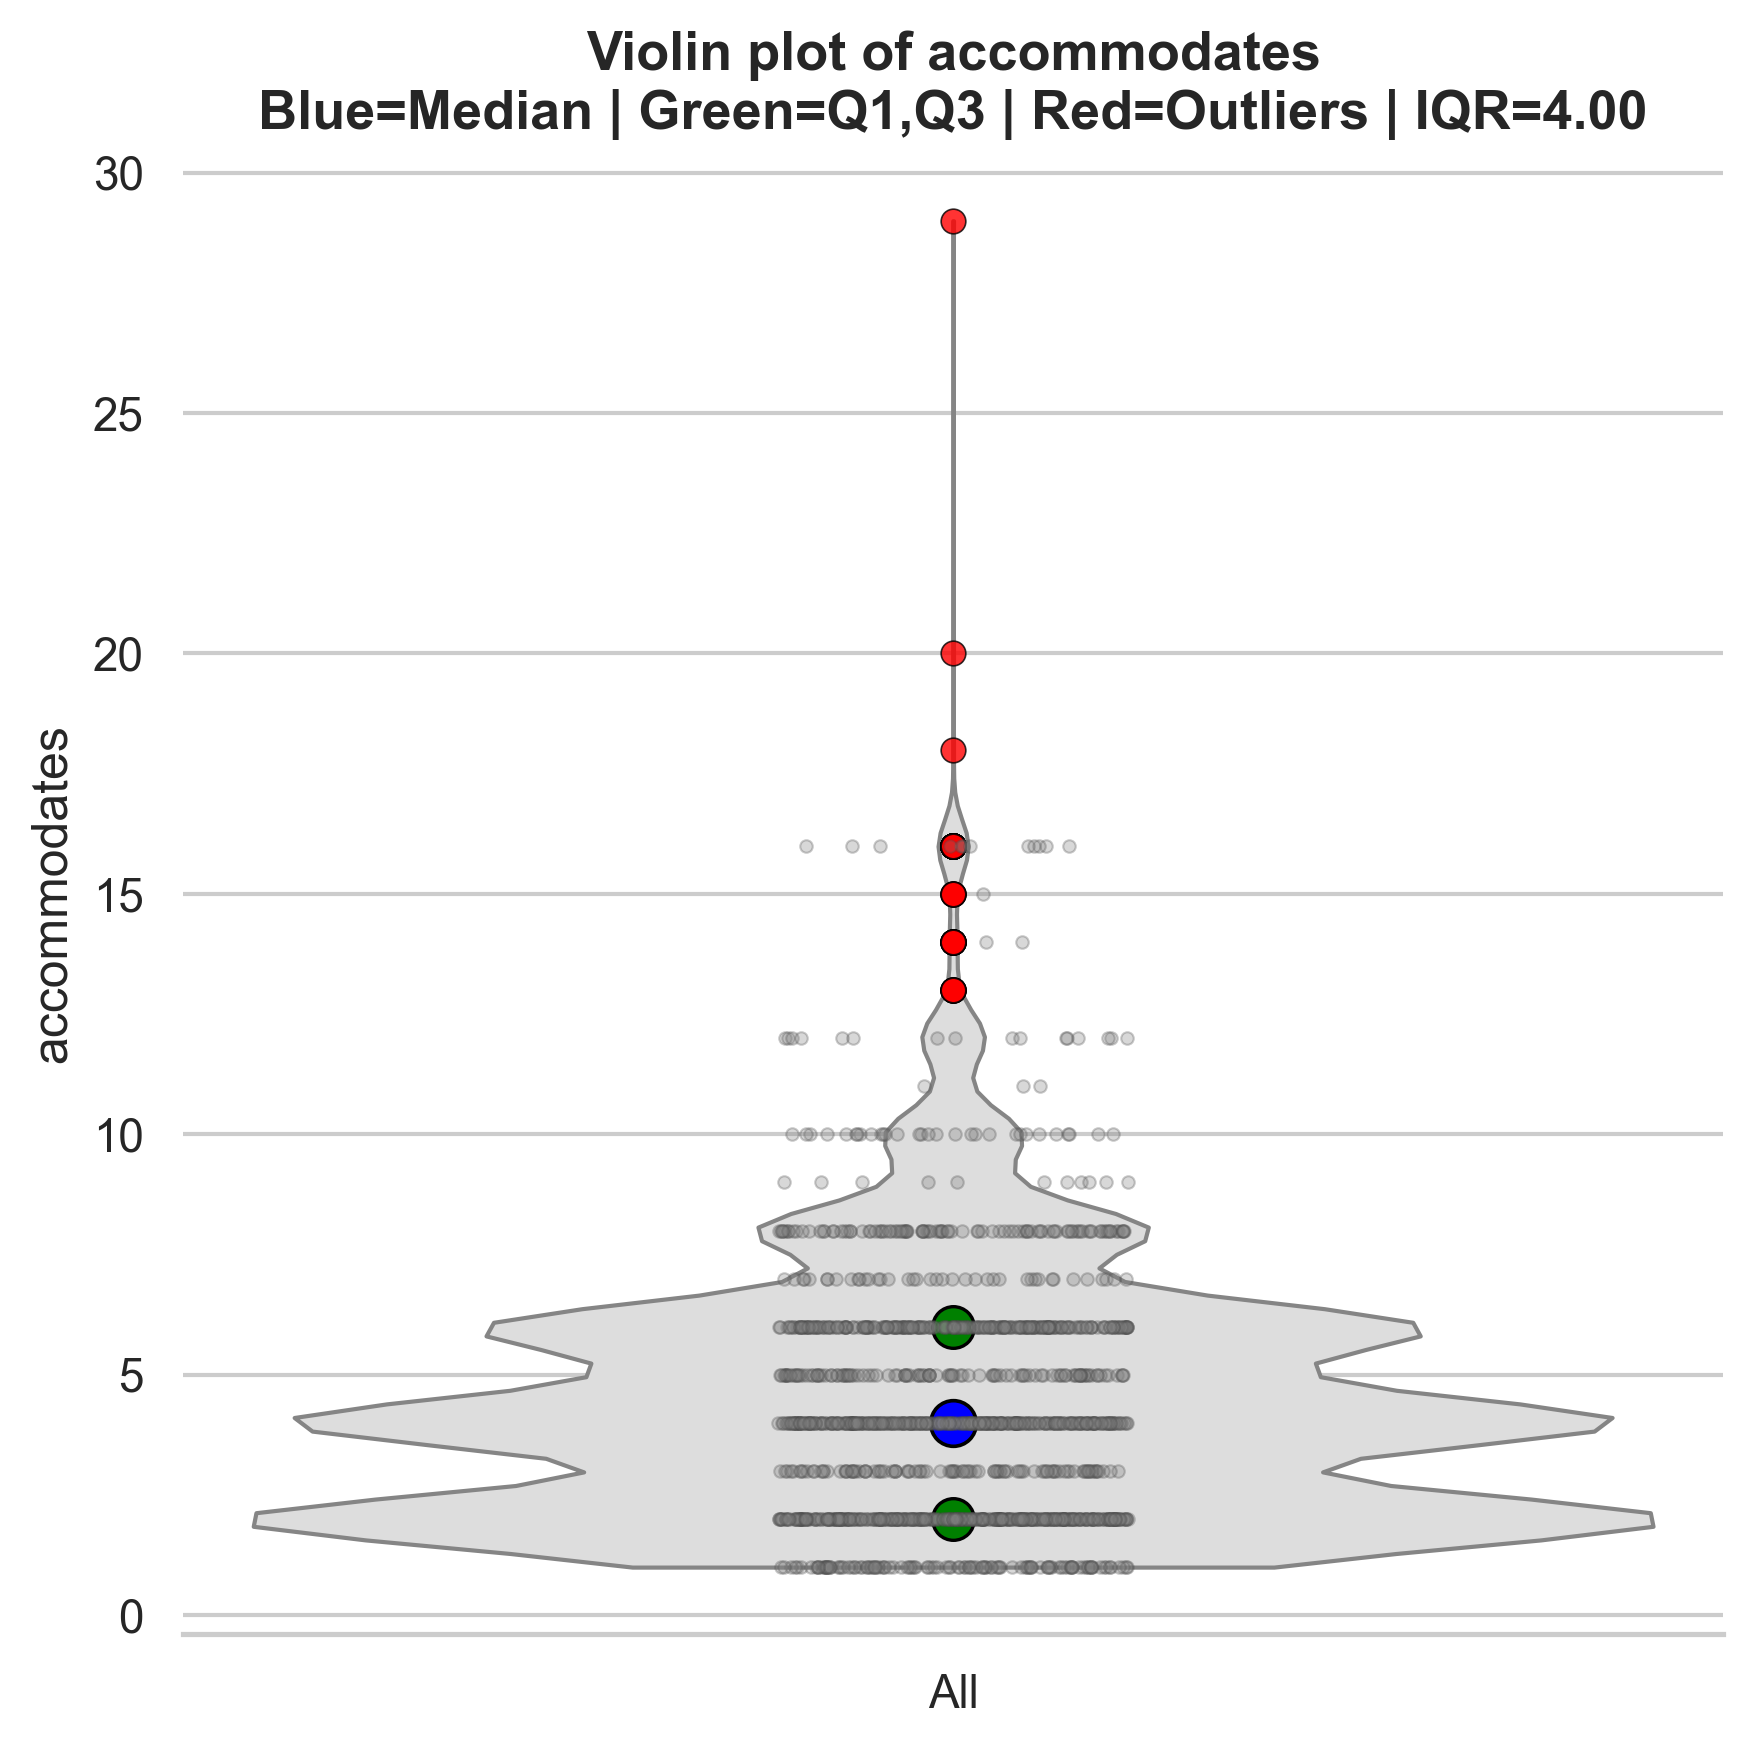

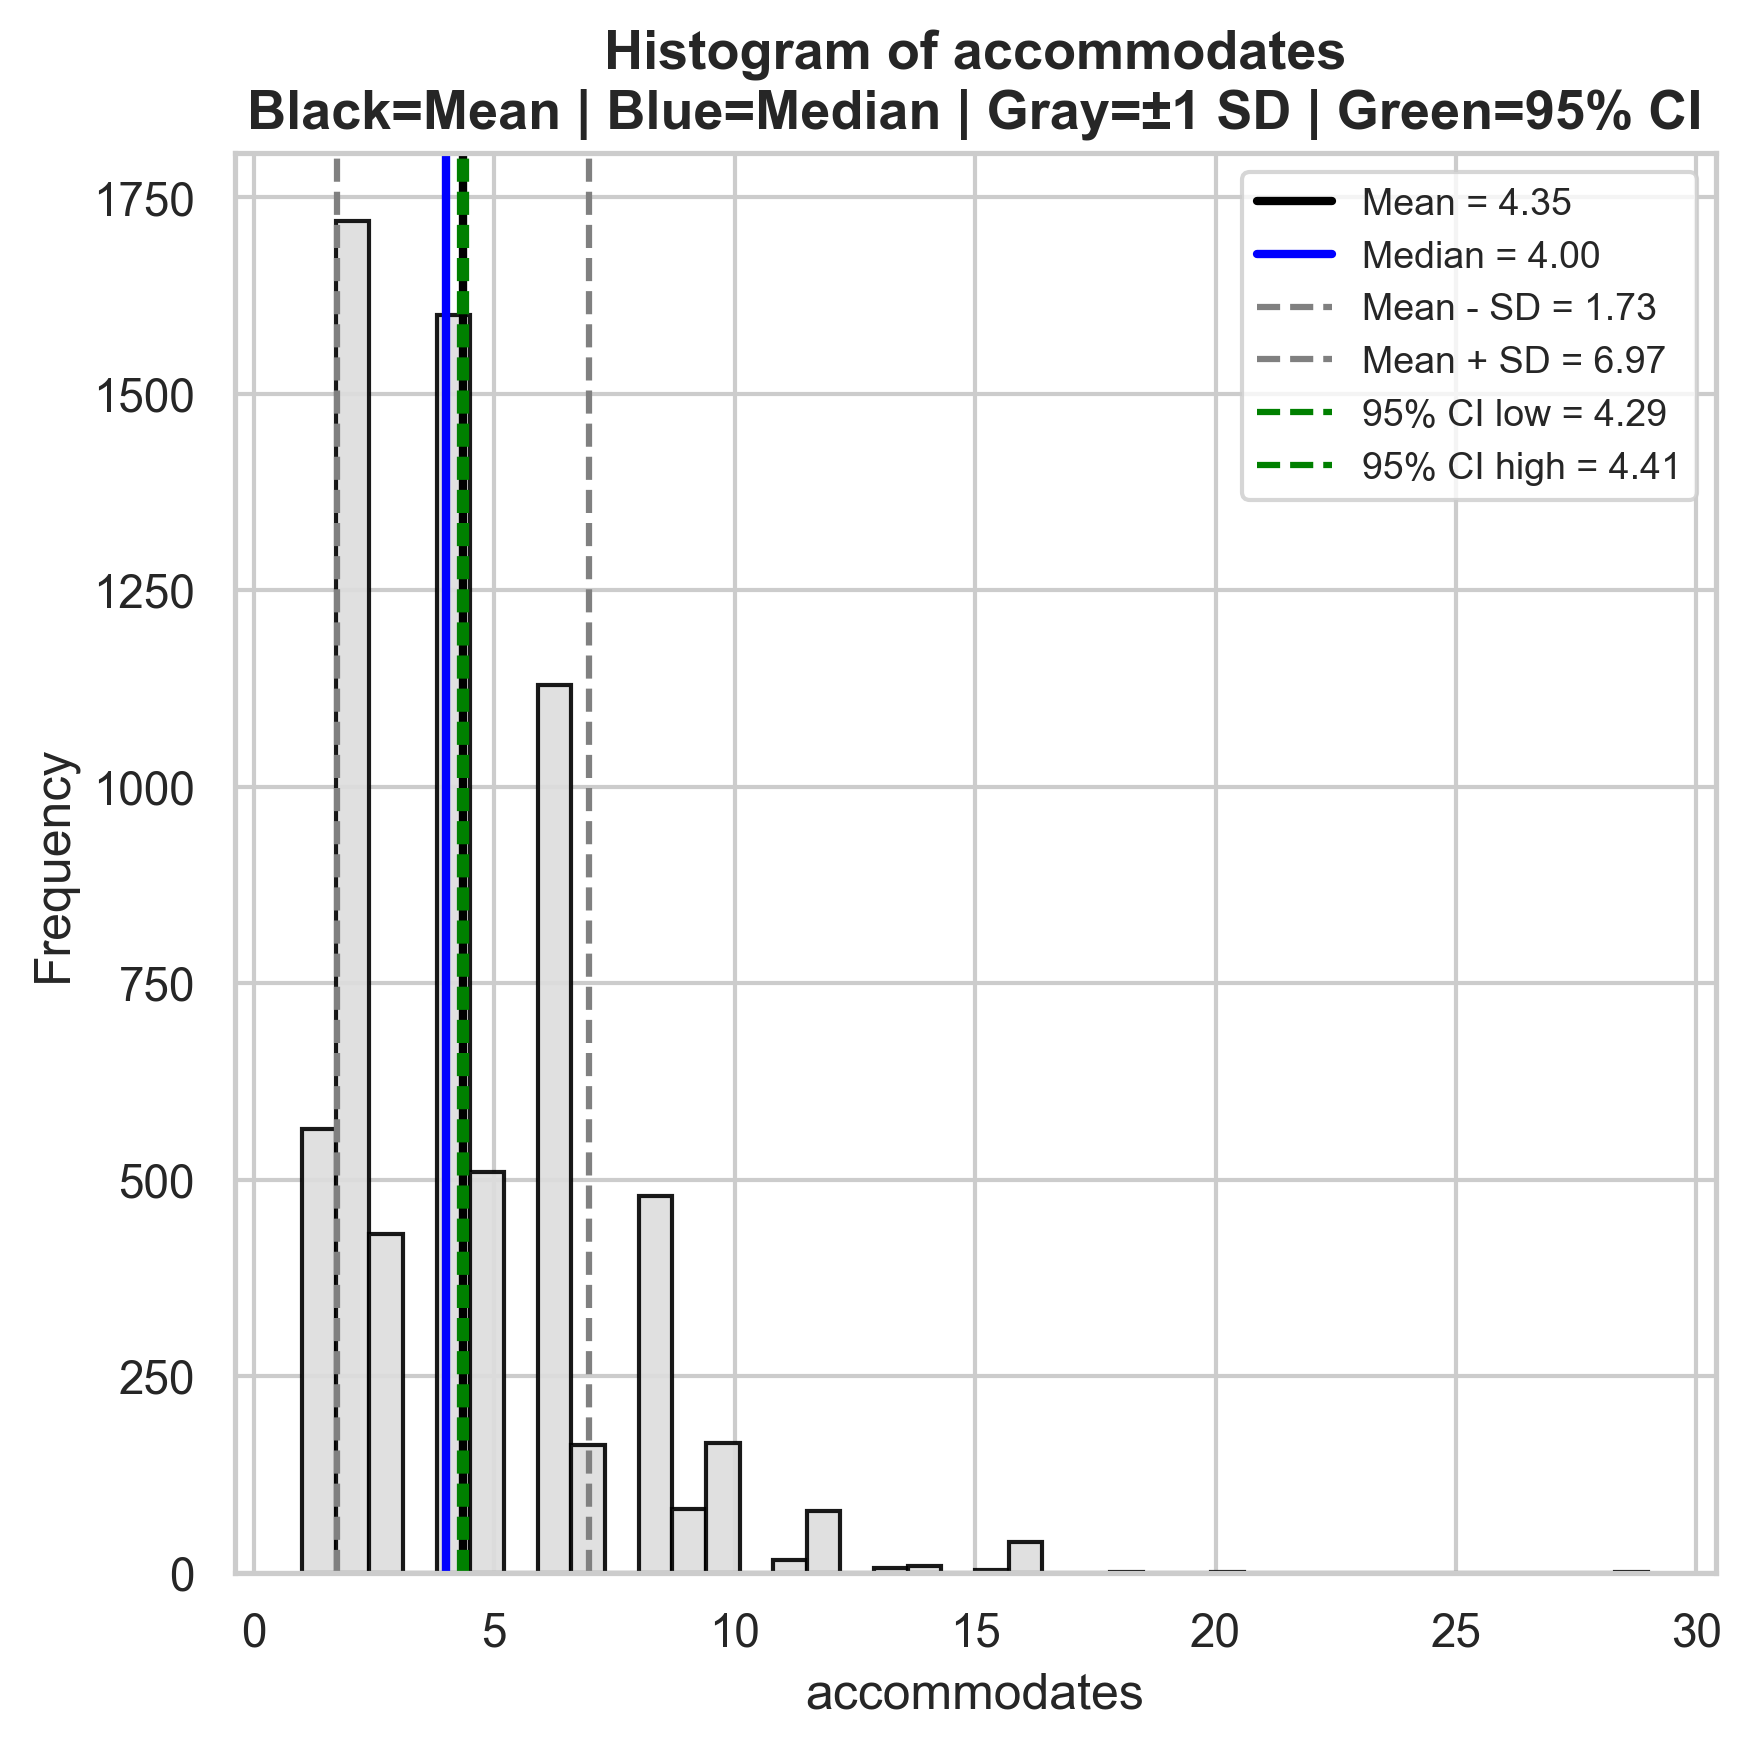

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,accommodates,7001,4.351807,4.0,2.620646,4.290409,4.413205,2.0,6.0,4.0,-4.0,12.0,61,1.305574,Highly skewed.



Unique values table
Number of non-nulls: 7001
Number of unique values: 19


,column,value,count,frequency_non_null
0,accommodates,1,565,0.080703
1,accommodates,2,1720,0.245679
2,accommodates,3,431,0.061563
3,accommodates,4,1600,0.228539
4,accommodates,5,510,0.072847
5,accommodates,6,1130,0.161406
6,accommodates,7,163,0.023282
7,accommodates,8,480,0.068562
8,accommodates,9,81,0.011570
9,accommodates,10,165,0.023568



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,accommodates,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,accommodates,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,accommodates,numeric,city,categorical,Chi-square,1787.653796,0.000000e+00,Significant,Statistically significant at p < 0.05.,
3,accommodates,numeric,room_type,categorical,Chi-square,3865.258907,0.000000e+00,Significant,Statistically significant at p < 0.05.,
4,accommodates,numeric,bathrooms,categorical,Chi-square,3388.622640,0.000000e+00,Significant,Statistically significant at p < 0.05.,
5,accommodates,numeric,bedrooms,categorical,Chi-square,9352.365132,0.000000e+00,Significant,Statistically significant at p < 0.05.,
6,accommodates,numeric,beds,numeric,Pearson,0.881985,0.000000e+00,Significant,Statistically significant at p < 0.05.,
7,accommodates,numeric,price,numeric,Pearson,0.623792,0.000000e+00,Significant,Statistically significant at p < 0.05.,
8,accommodates,numeric,minimum_nights,numeric,Pearson,-0.036176,2.467075e-03,Significant,Statistically significant at p < 0.05.,
9,accommodates,numeric,maximum_nights,numeric,Pearson,0.077129,1.033119e-10,Significant,Statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,1.305574,Highly skewed.,Baseline.
1,Log Transformation,-0.299903,Approximately symmetric.,Improved strongly; distribution is closer to s...
2,Square Root Transformation,0.408793,Approximately symmetric.,Improved strongly; distribution is closer to s...
3,Box-Cox Transformation,-0.023411,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [70]:
analysis = analyze_single_field(df, 
                                target_col="accommodates", 
                                results_dir=RESULTS_DIR, 
                                show_in_notebook=True)

###### Number of beds

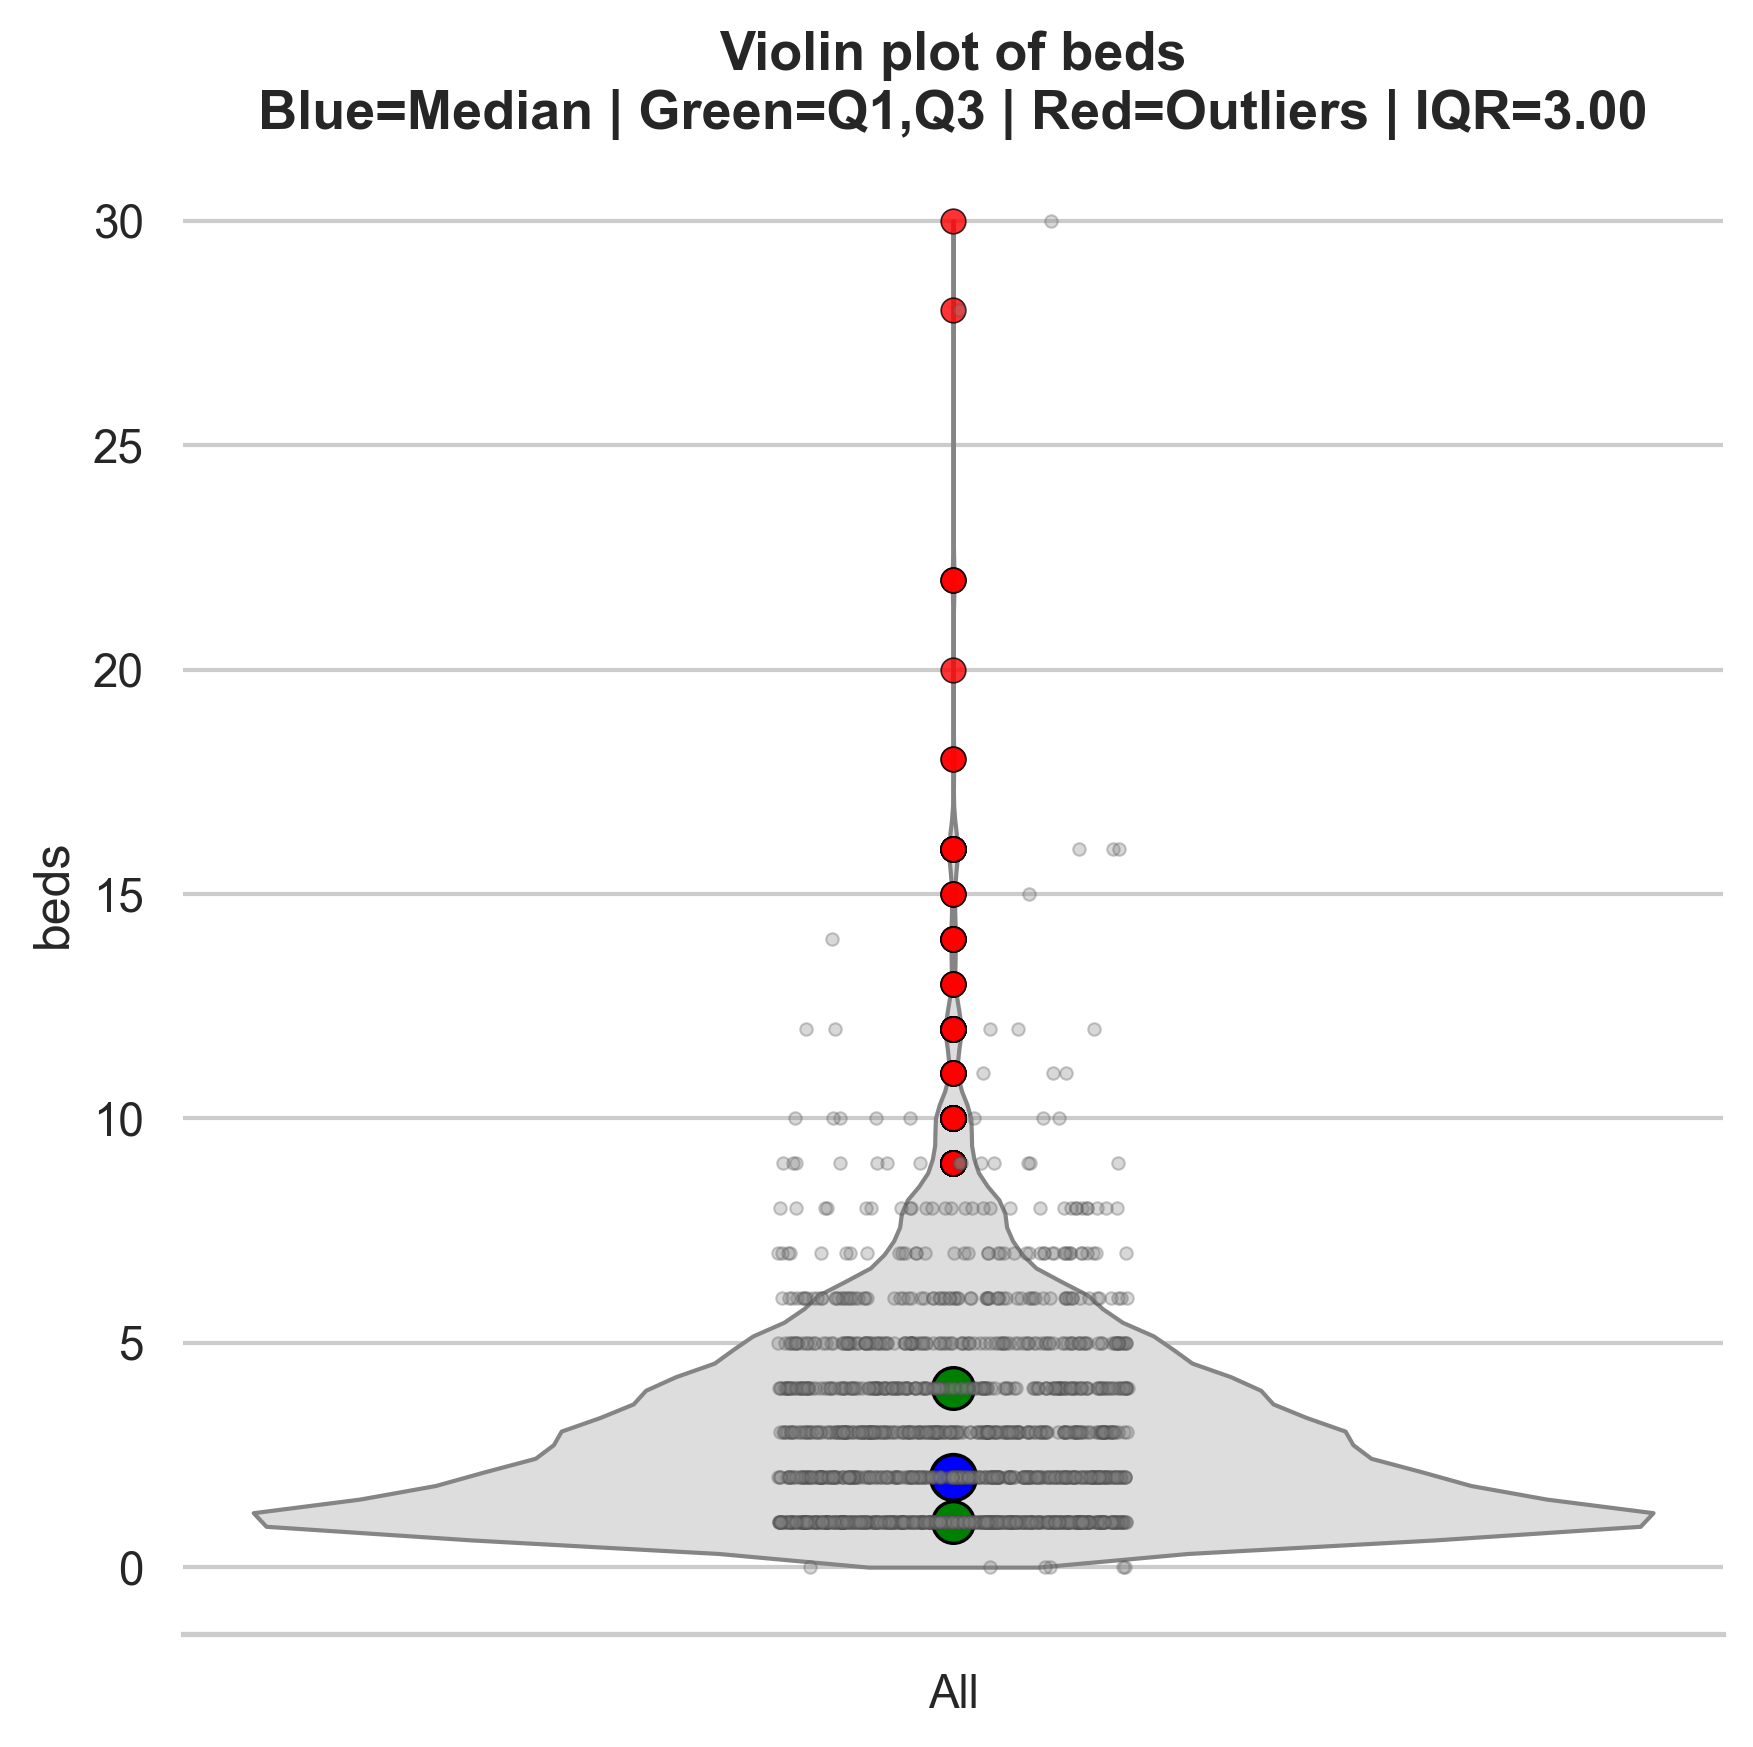

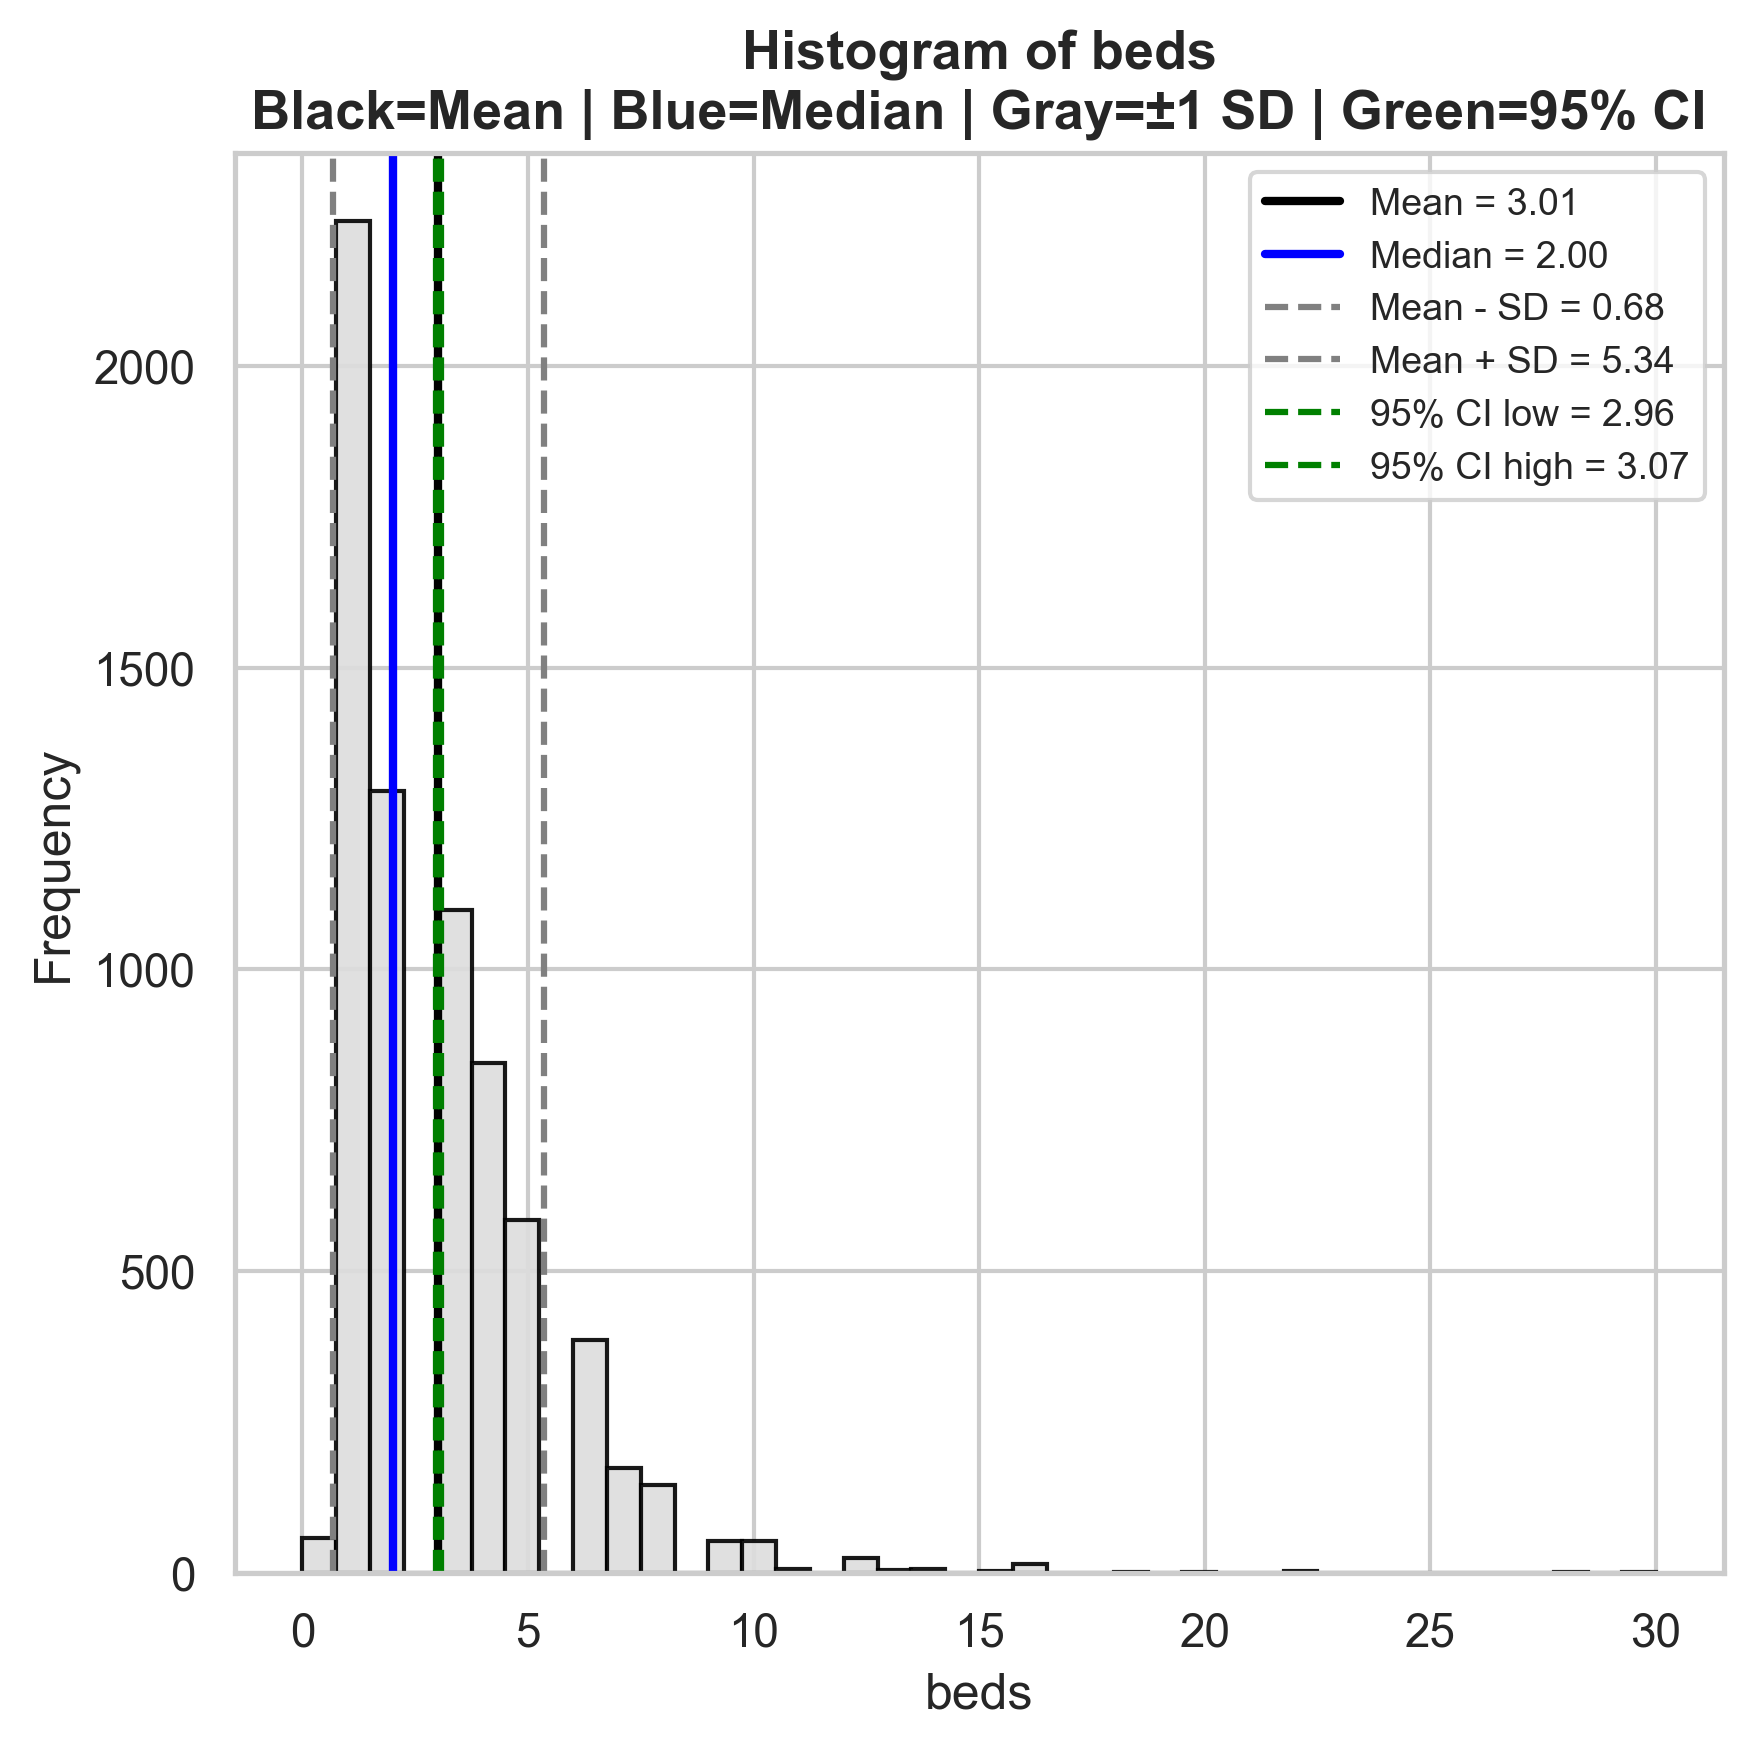

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,beds,6998,3.013575,2.0,2.330849,2.958955,3.068195,1.0,4.0,3.0,-3.5,8.5,174,2.156505,Highly skewed.



Unique values table
Number of non-nulls: 6998
Number of unique values: 22


,column,value,count,frequency_non_null
0,beds,0.0,58,0.008288
1,beds,1.0,2240,0.320091
2,beds,2.0,1296,0.185196
3,beds,3.0,1099,0.157045
4,beds,4.0,844,0.120606
5,beds,5.0,584,0.083452
6,beds,6.0,385,0.055016
7,beds,7.0,173,0.024721
8,beds,8.0,145,0.020720
9,beds,9.0,53,0.007574



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,beds,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,beds,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,beds,numeric,city,categorical,Chi-square,1981.151721,0.000000e+00,Significant,Statistically significant at p < 0.05.,
3,beds,numeric,room_type,categorical,Chi-square,2754.433418,0.000000e+00,Significant,Statistically significant at p < 0.05.,
4,beds,numeric,accommodates,numeric,Pearson,0.881985,0.000000e+00,Significant,Statistically significant at p < 0.05.,
5,beds,numeric,bathrooms,categorical,Chi-square,3193.580889,0.000000e+00,Significant,Statistically significant at p < 0.05.,
6,beds,numeric,bedrooms,categorical,Chi-square,8685.503868,0.000000e+00,Significant,Statistically significant at p < 0.05.,
7,beds,numeric,price,numeric,Pearson,0.584479,0.000000e+00,Significant,Statistically significant at p < 0.05.,
8,beds,numeric,minimum_nights,numeric,Pearson,-0.026444,2.695425e-02,Significant,Statistically significant at p < 0.05.,
9,beds,numeric,maximum_nights,numeric,Pearson,0.058816,8.498805e-07,Significant,Statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,2.156505,Highly skewed.,Baseline.
1,Log Transformation,0.357716,Approximately symmetric.,Improved strongly; distribution is closer to s...
2,Square Root Transformation,0.694450,Moderately skewed.,Improved; skewness decreased.
3,Box-Cox Transformation,0.036889,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [39]:
analysis = analyze_single_field(df, 
                                target_col="beds", 
                                results_dir=RESULTS_DIR, 
                                show_in_notebook=True)

###### Price

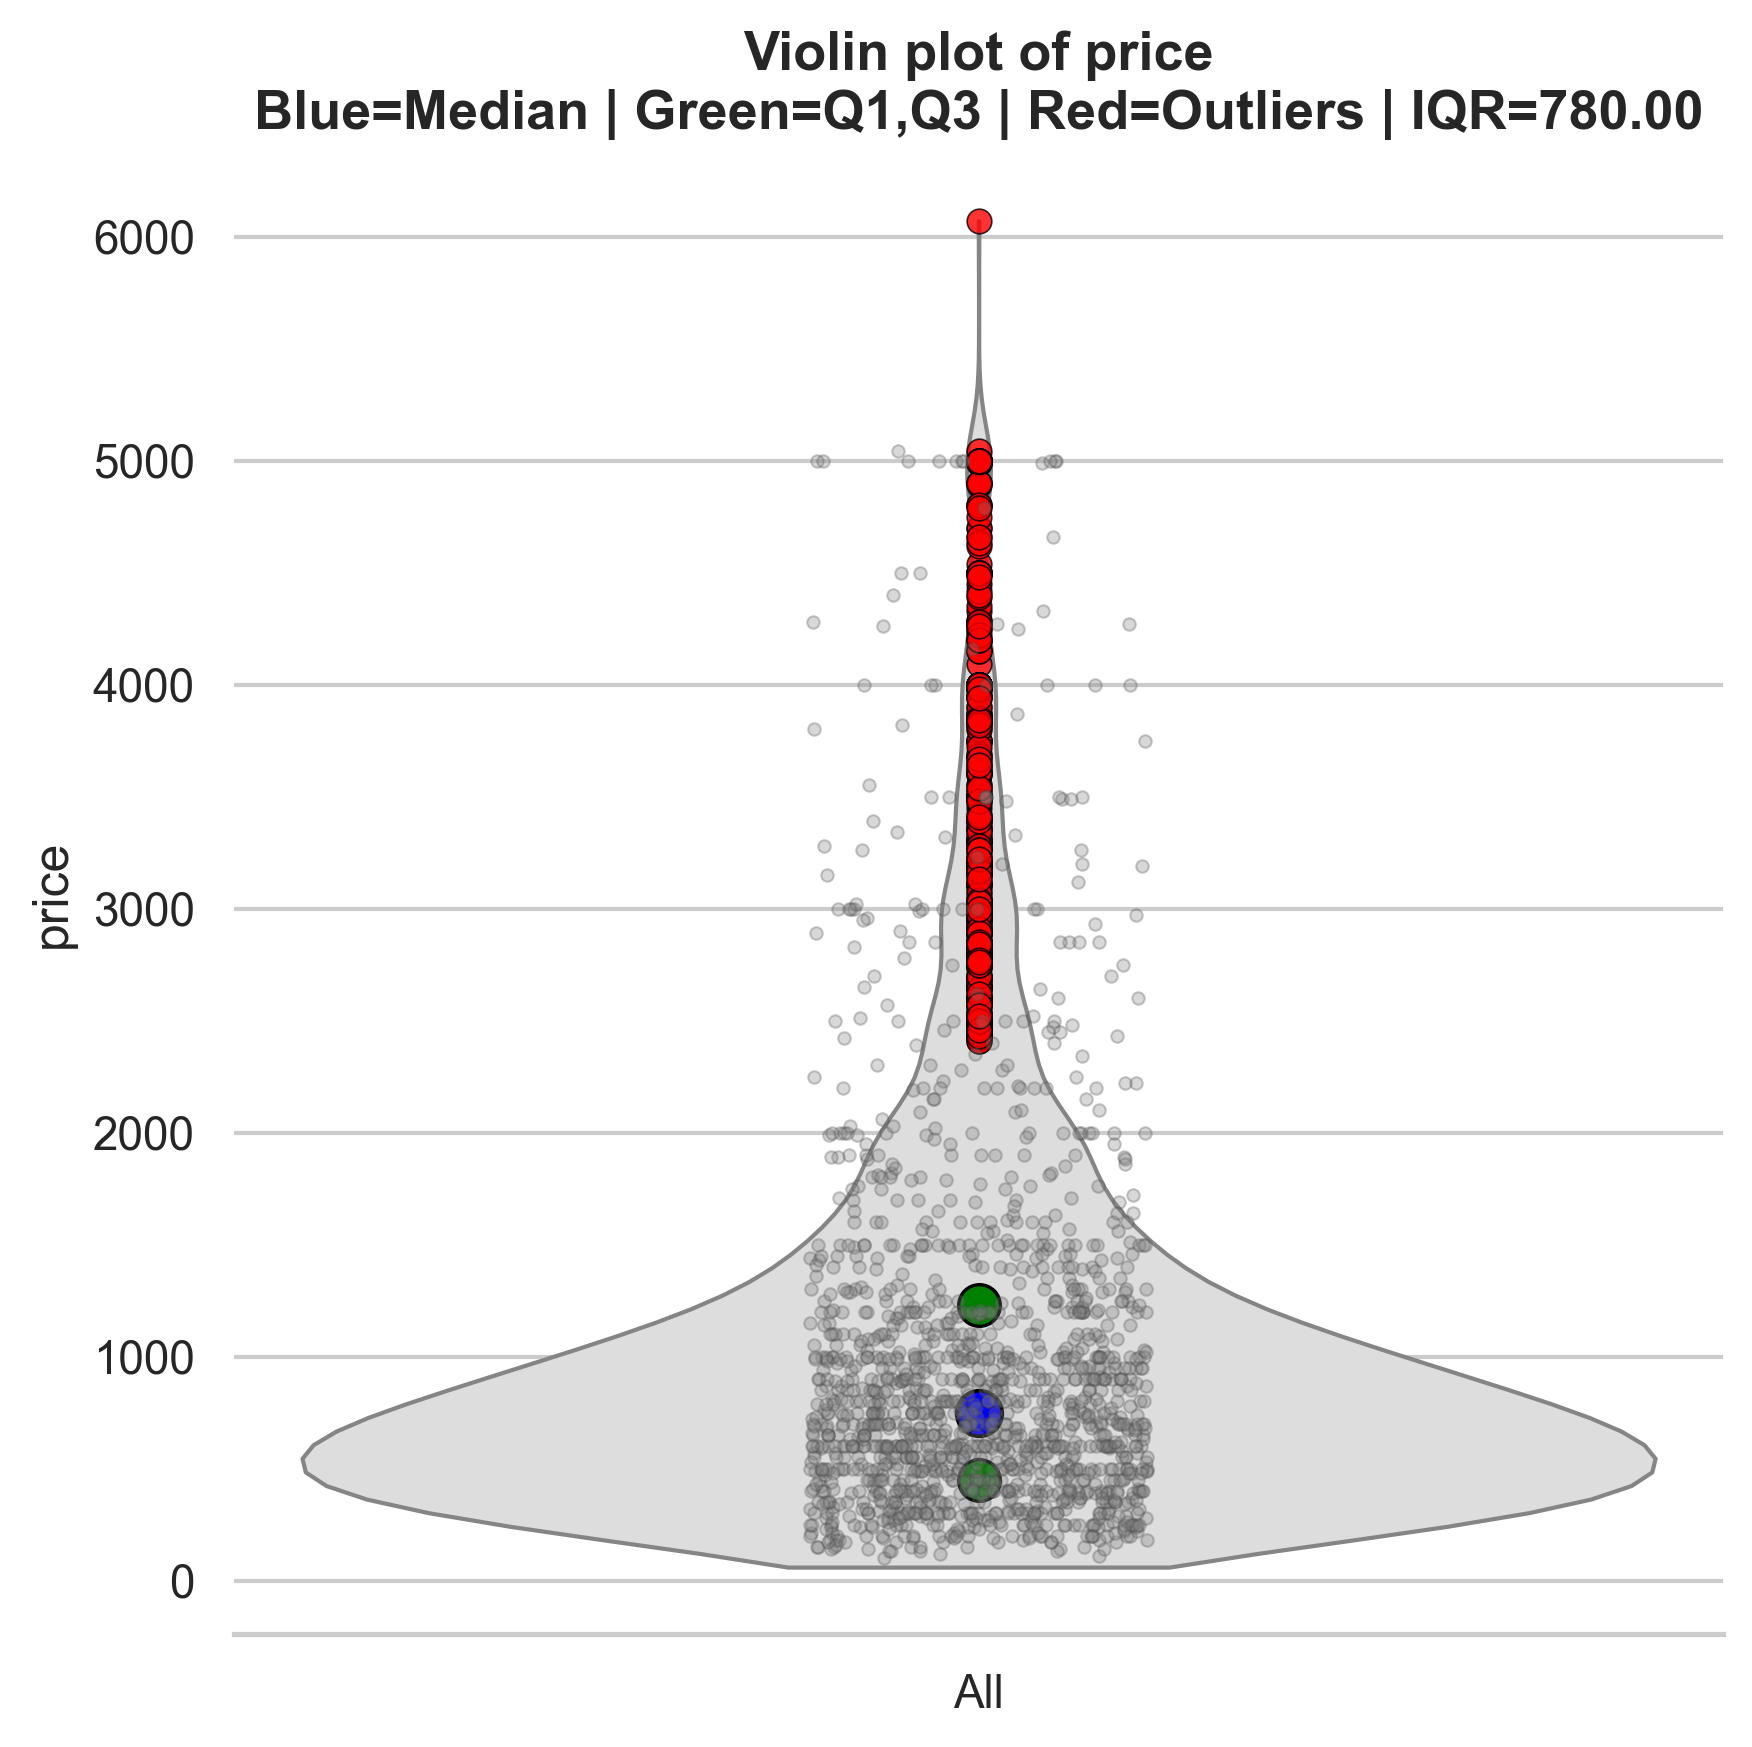

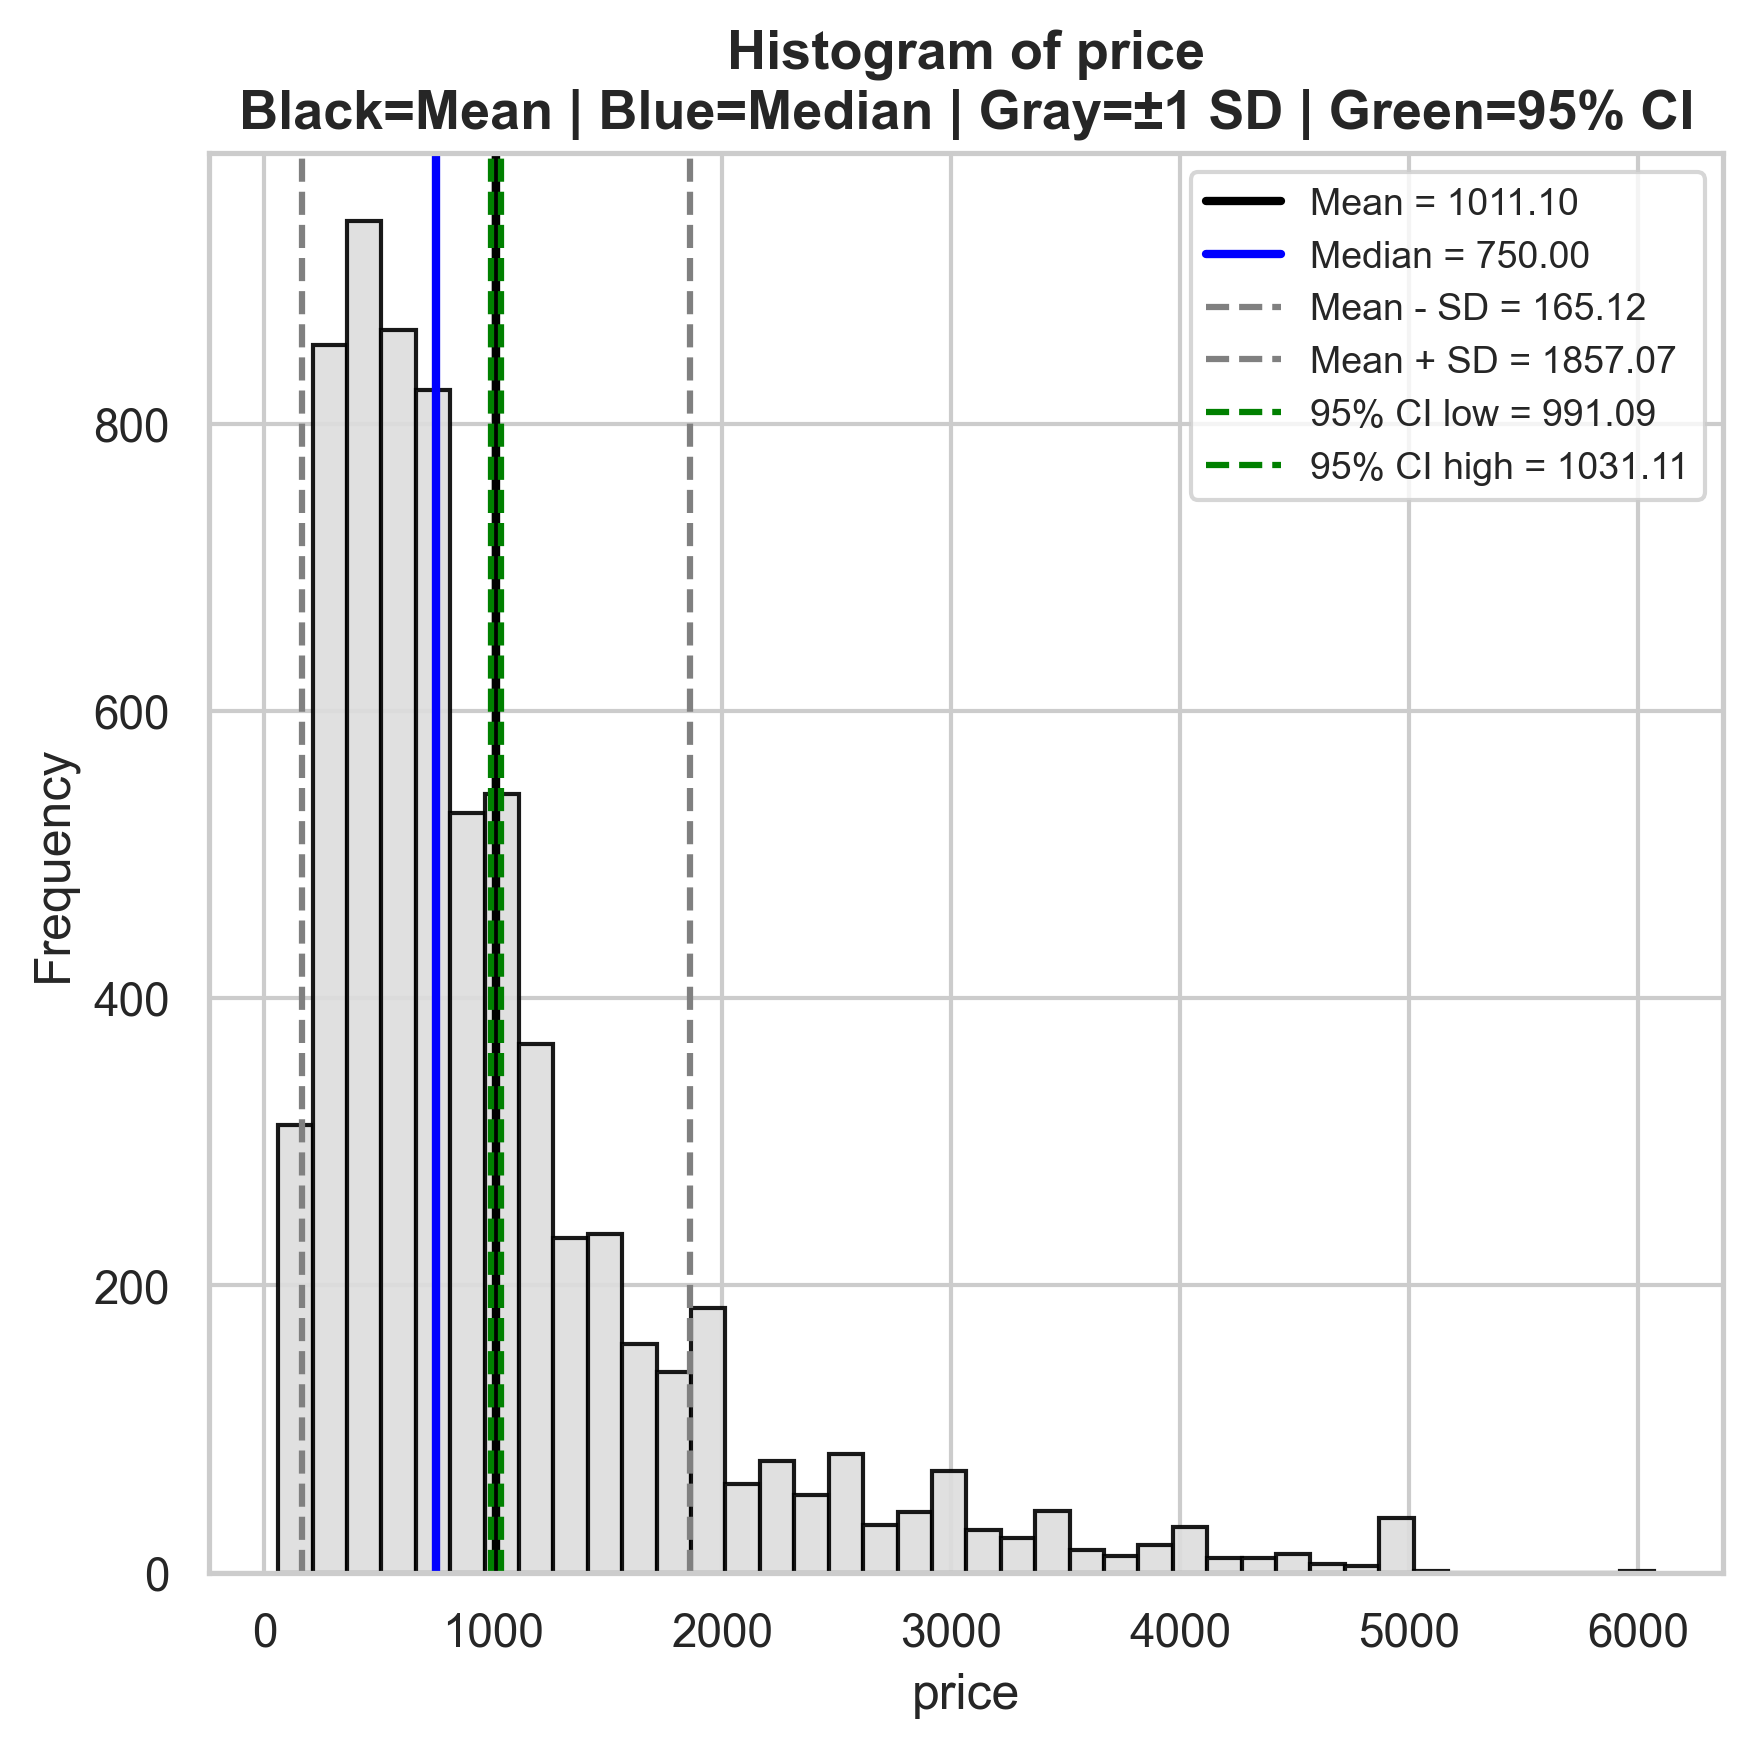

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,price,6870,1011.098108,750.0,845.975377,991.090094,1031.106121,450.0,1230.0,780.0,-720.0,2400.0,509,2.067854,Highly skewed.



Unique values table
Number of non-nulls: 6870
Number of unique values: 383


,column,value,count,frequency_non_null
0,price,60.0,1,0.000146
1,price,80.0,5,0.000728
2,price,90.0,2,0.000291
3,price,100.0,12,0.001747
4,price,110.0,2,0.000291
...,...,...,...,...
378,price,4900.0,3,0.000437
379,price,4990.0,3,0.000437
380,price,5000.0,31,0.004512
381,price,5043.0,1,0.000146



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,price,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,price,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,price,numeric,city,categorical,Chi-square,1436.977564,2.048259e-285,Significant,Statistically significant at p < 0.05.,
3,price,numeric,room_type,categorical,Chi-square,3322.230171,0.000000e+00,Significant,Statistically significant at p < 0.05.,
4,price,numeric,accommodates,numeric,Pearson,0.623792,0.000000e+00,Significant,Statistically significant at p < 0.05.,
5,price,numeric,bathrooms,categorical,Chi-square,2105.843948,0.000000e+00,Significant,Statistically significant at p < 0.05.,
6,price,numeric,bedrooms,categorical,Chi-square,3746.895898,0.000000e+00,Significant,Statistically significant at p < 0.05.,
7,price,numeric,beds,numeric,Pearson,0.584479,0.000000e+00,Significant,Statistically significant at p < 0.05.,
8,price,numeric,minimum_nights,numeric,Pearson,-0.015838,1.893191e-01,Not significant,Not statistically significant at p < 0.05.,
9,price,numeric,maximum_nights,numeric,Pearson,0.033930,4.914128e-03,Significant,Statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,2.067854,Highly skewed.,Baseline.
1,Log Transformation,0.071785,Approximately symmetric.,Improved strongly; distribution is closer to s...
2,Square Root Transformation,1.059304,Highly skewed.,Improved; skewness decreased.
3,Box-Cox Transformation,0.002072,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [34]:
analysis = analyze_single_field(df, 
                                target_col="price", 
                                results_dir=RESULTS_DIR, 
                                show_in_notebook=True)


In [ ]:
sns.heatmap(df.groupby(['city', 'room_type'])['price'].mean().round(1).unstack(fill_value=0), annot=True, cmap='YlGnBu', fmt='g')

###### Minimal number of nights

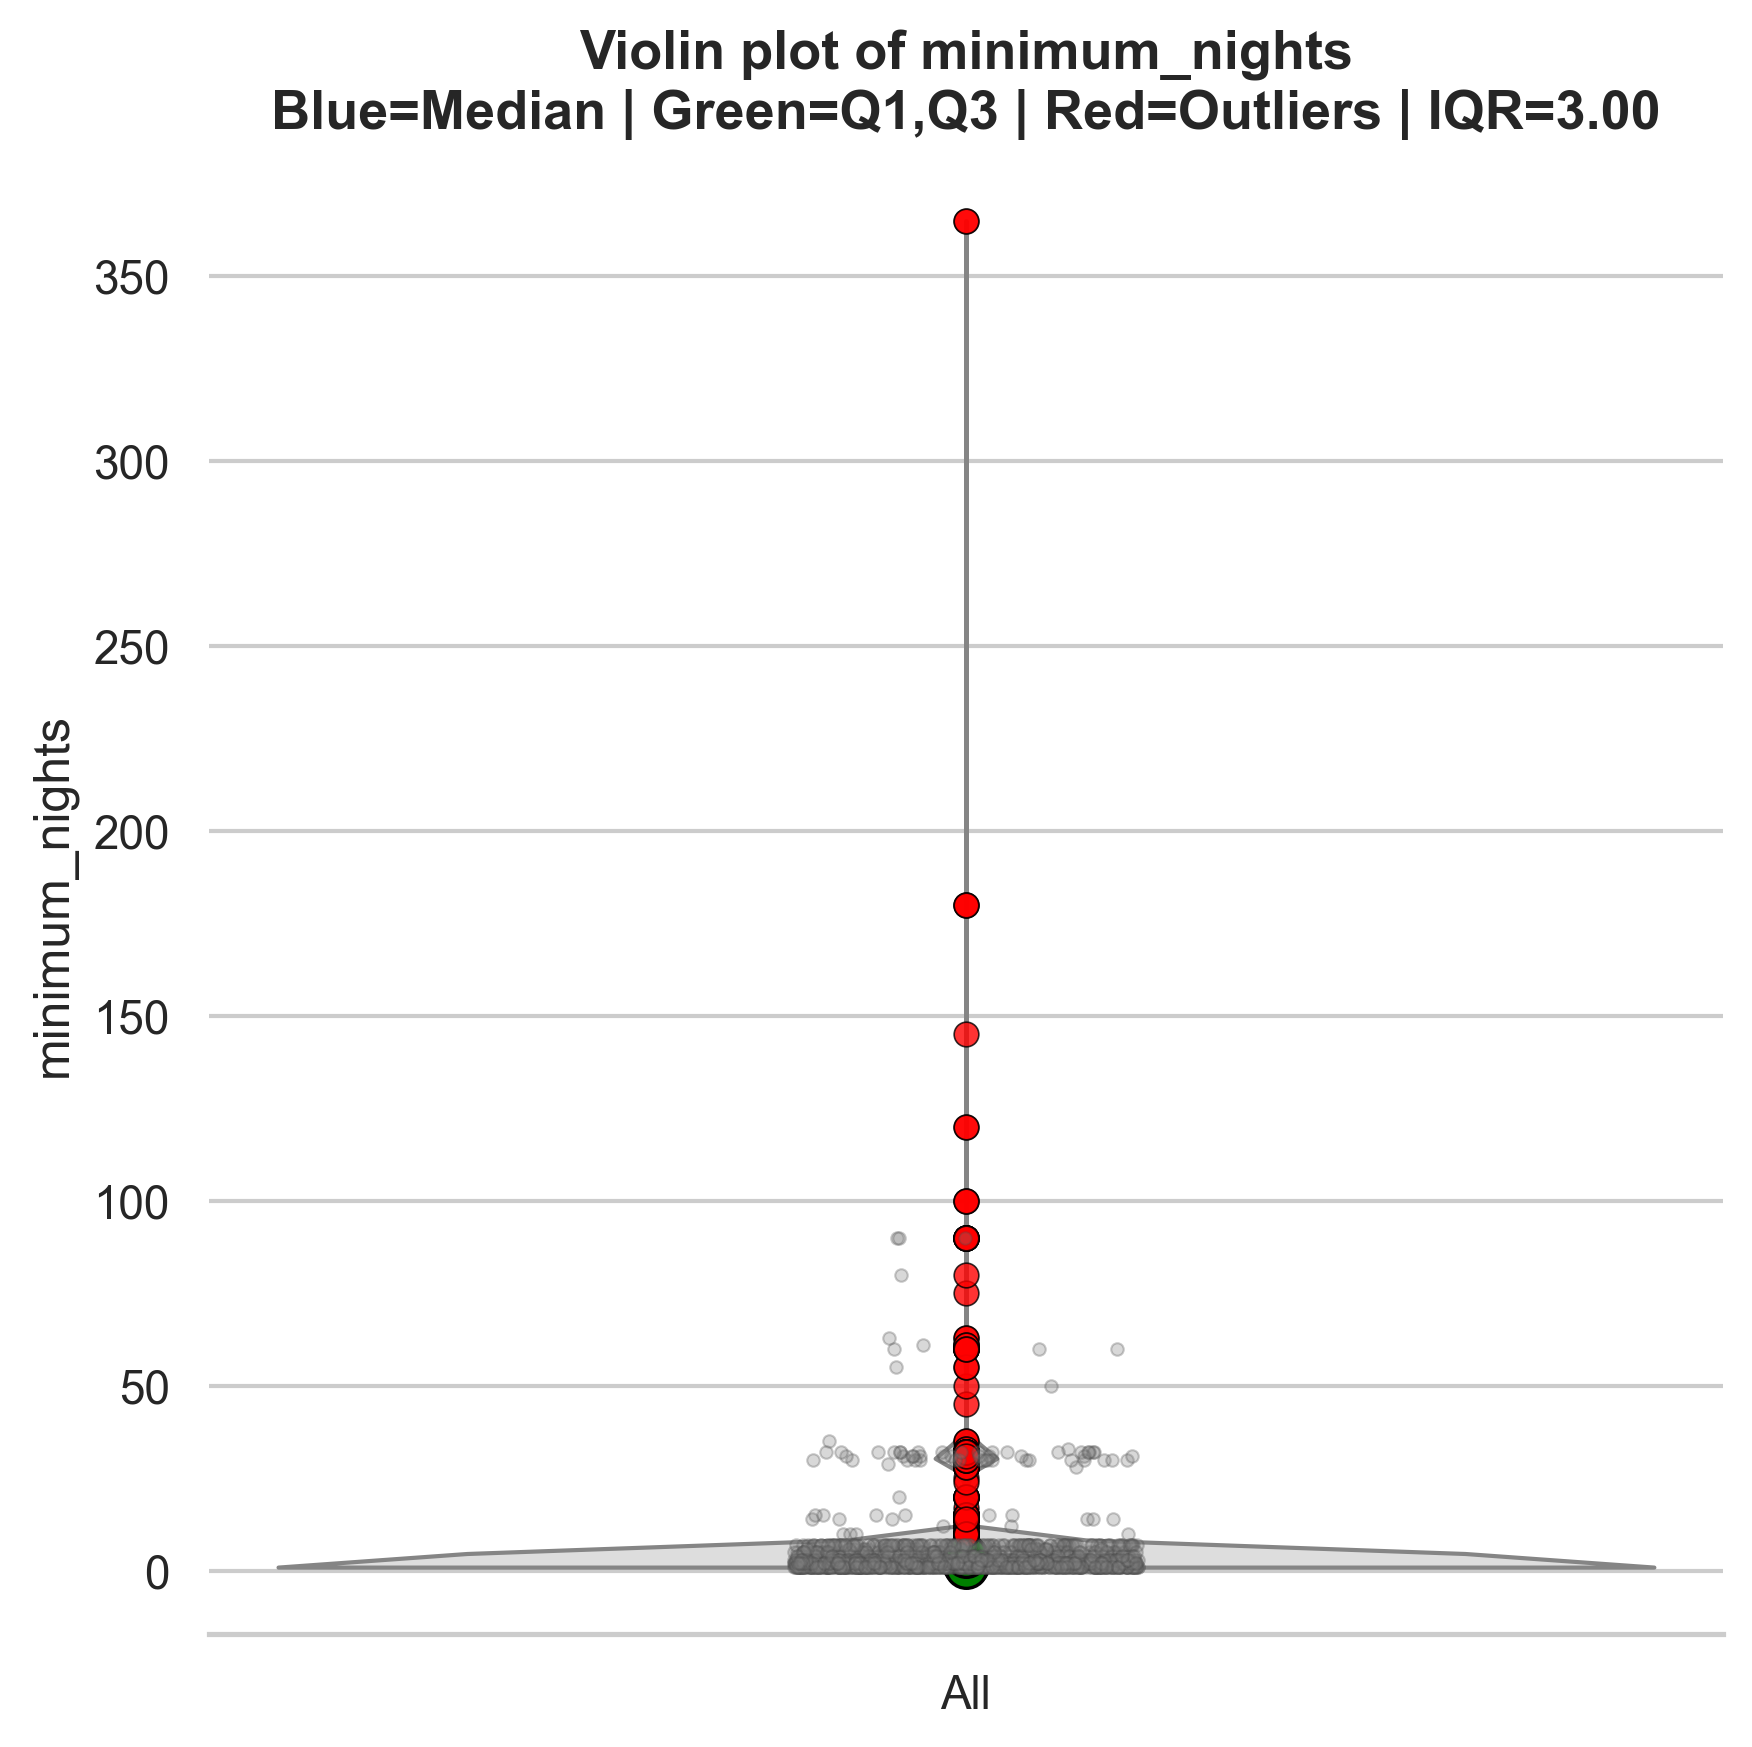

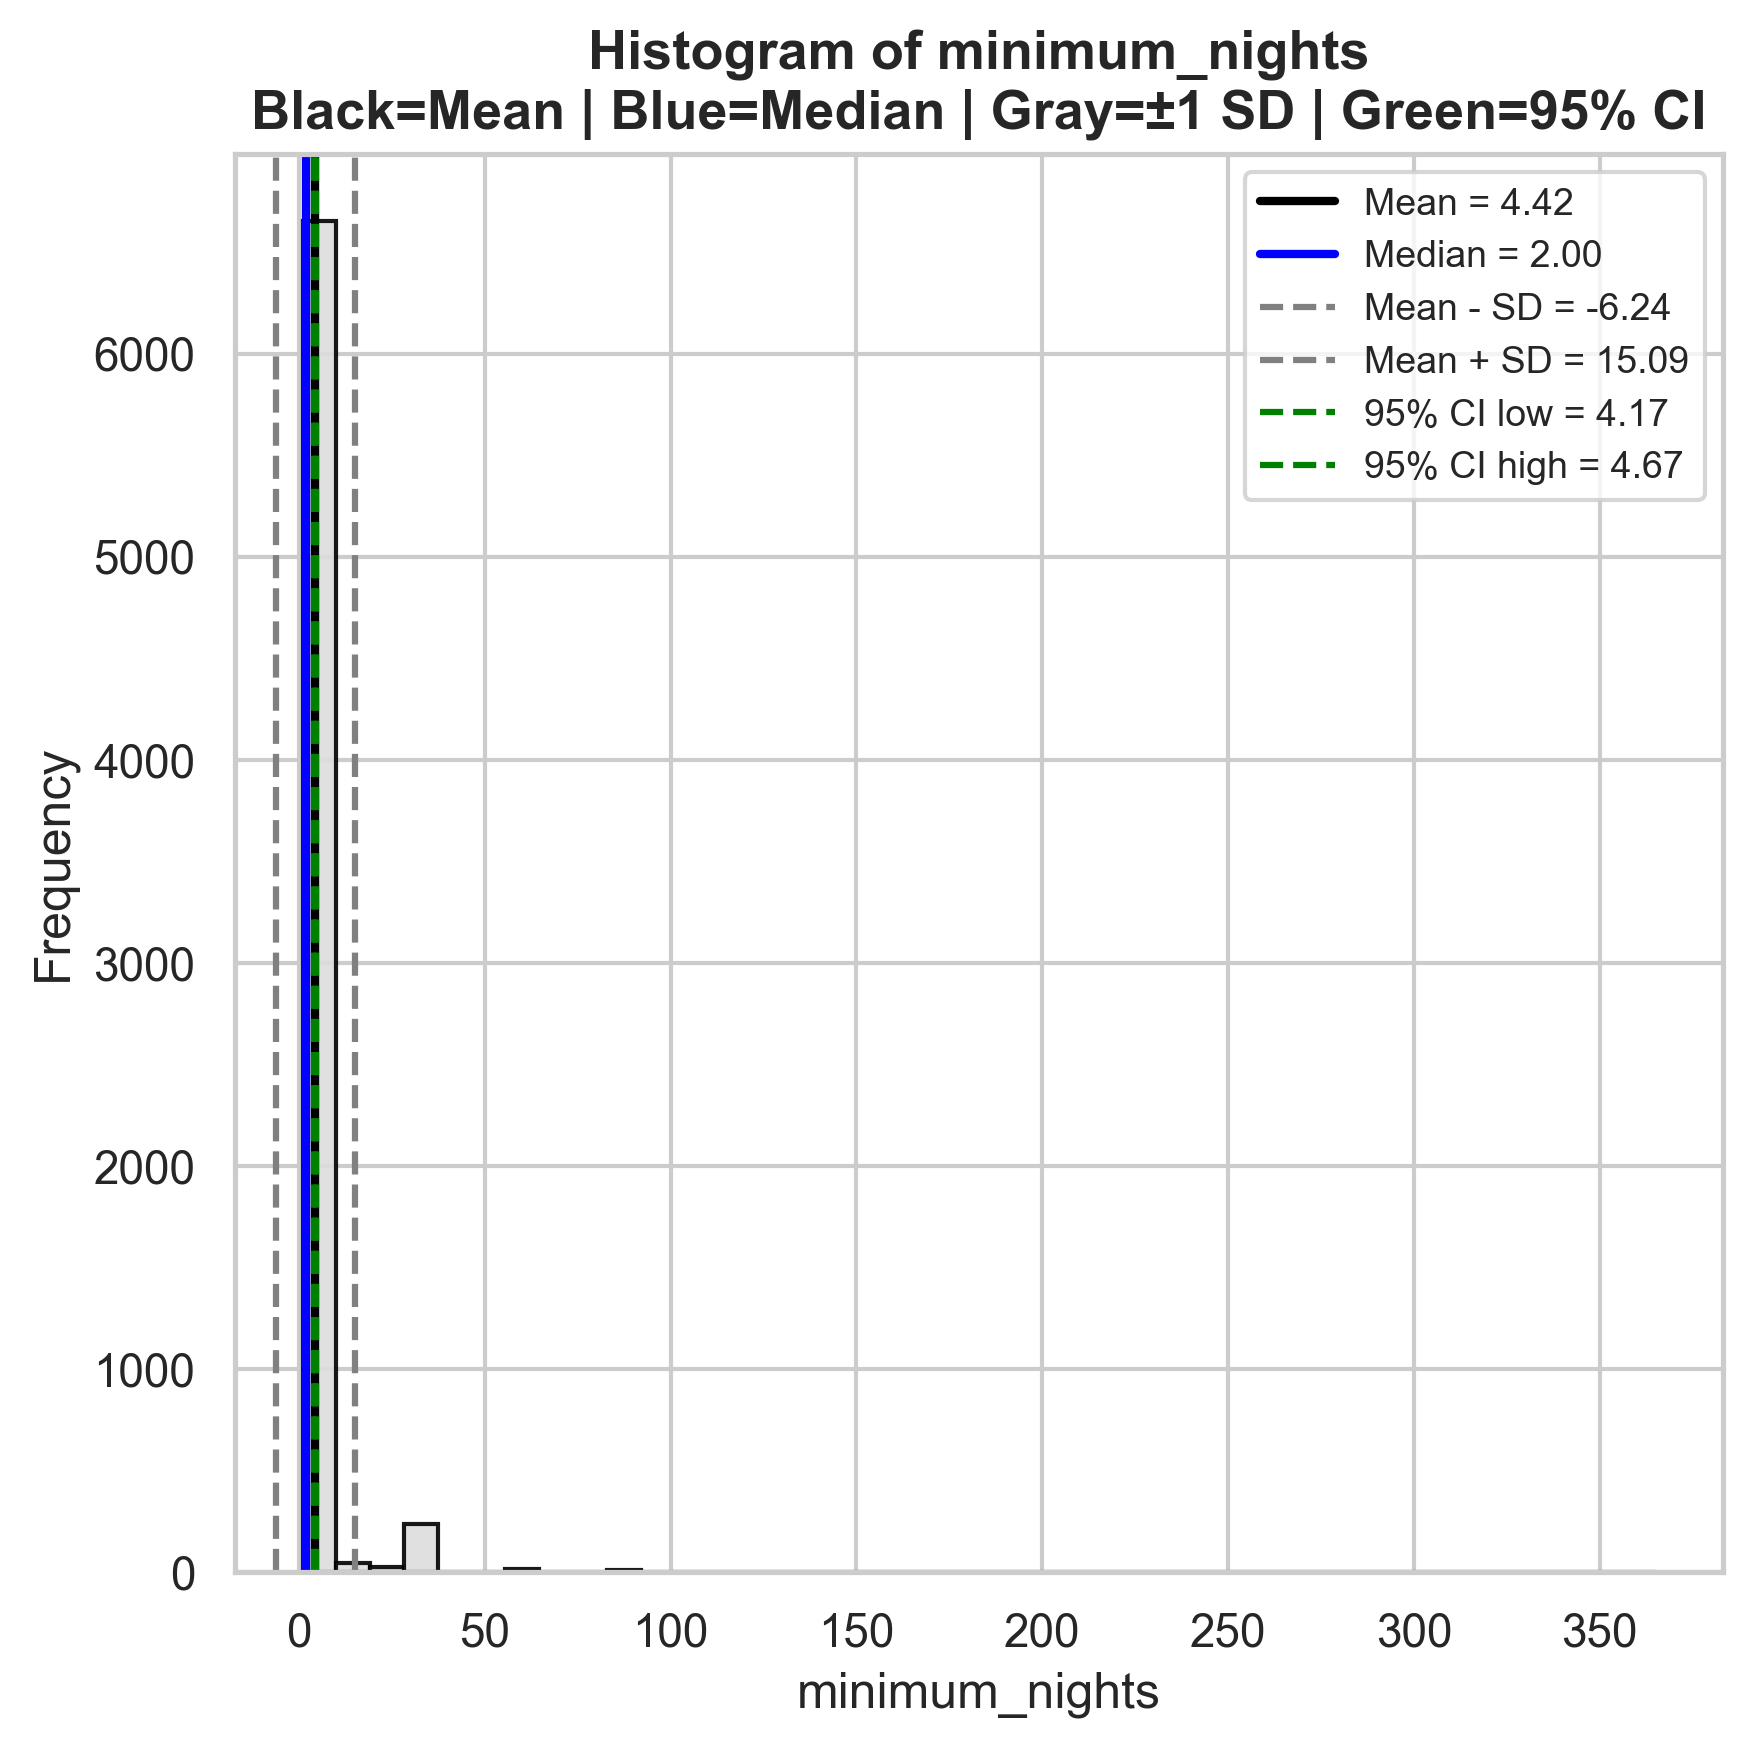

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,minimum_nights,7001,4.424939,2.0,10.669575,4.174968,4.674911,1.0,4.0,3.0,-3.5,8.5,366,15.709851,Highly skewed.



Unique values table
Number of non-nulls: 7001
Number of unique values: 38


,column,value,count,frequency_non_null
0,minimum_nights,1,2007,0.286673
1,minimum_nights,2,1920,0.274247
2,minimum_nights,3,1140,0.162834
3,minimum_nights,4,436,0.062277
4,minimum_nights,5,418,0.059706
5,minimum_nights,6,122,0.017426
6,minimum_nights,7,586,0.083702
7,minimum_nights,8,6,0.000857
8,minimum_nights,10,16,0.002285
9,minimum_nights,11,2,0.000286



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,minimum_nights,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,minimum_nights,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,minimum_nights,numeric,city,categorical,Chi-square,1089.178622,2.715288e-217,Significant,Statistically significant at p < 0.05.,
3,minimum_nights,numeric,room_type,categorical,Chi-square,298.333772,5.889721e-59,Significant,Statistically significant at p < 0.05.,
4,minimum_nights,numeric,accommodates,numeric,Pearson,-0.036176,2.467075e-03,Significant,Statistically significant at p < 0.05.,
5,minimum_nights,numeric,bathrooms,categorical,Chi-square,444.312325,7.858296e-72,Significant,Statistically significant at p < 0.05.,
6,minimum_nights,numeric,bedrooms,categorical,Chi-square,528.922279,3.533326e-87,Significant,Statistically significant at p < 0.05.,
7,minimum_nights,numeric,beds,numeric,Pearson,-0.026444,2.695425e-02,Significant,Statistically significant at p < 0.05.,
8,minimum_nights,numeric,price,numeric,Pearson,-0.015838,1.893191e-01,Not significant,Not statistically significant at p < 0.05.,
9,minimum_nights,numeric,maximum_nights,numeric,Pearson,-0.016810,1.596158e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,15.709851,Highly skewed.,Baseline.
1,Log Transformation,1.254647,Highly skewed.,Improved; skewness decreased.
2,Square Root Transformation,4.275819,Highly skewed.,Improved; skewness decreased.
3,Box-Cox Transformation,0.106267,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [42]:
analysis = analyze_single_field(df, 
                                target_col="minimum_nights", 
                                results_dir=RESULTS_DIR, 
                                show_in_notebook=True)

###### Maximal numbert of nights

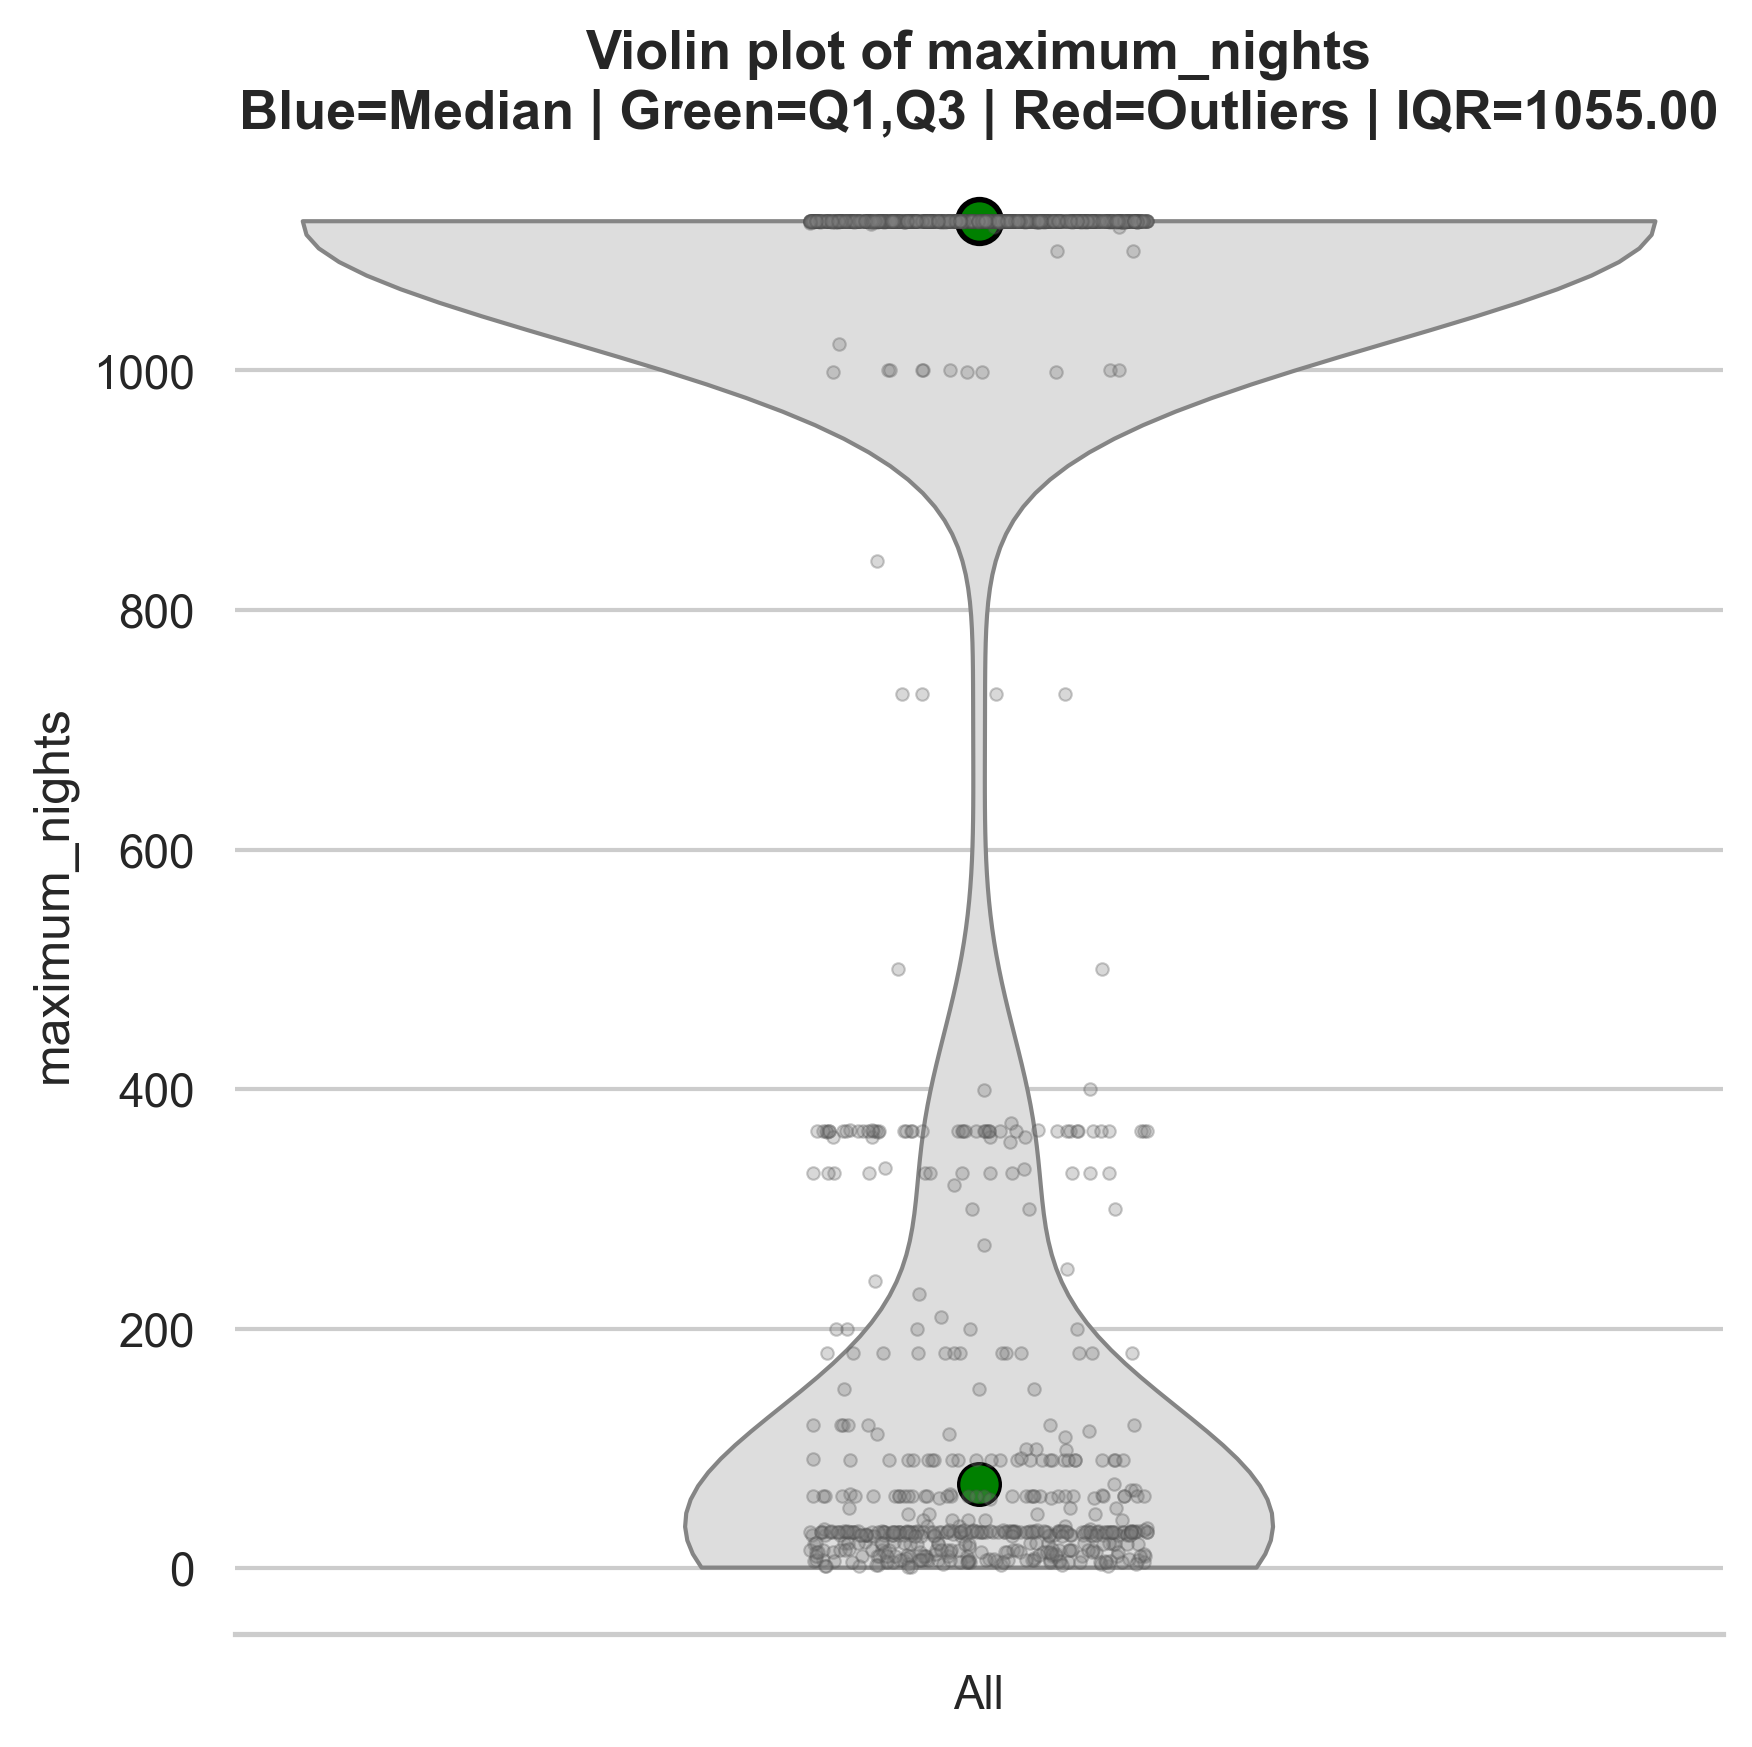

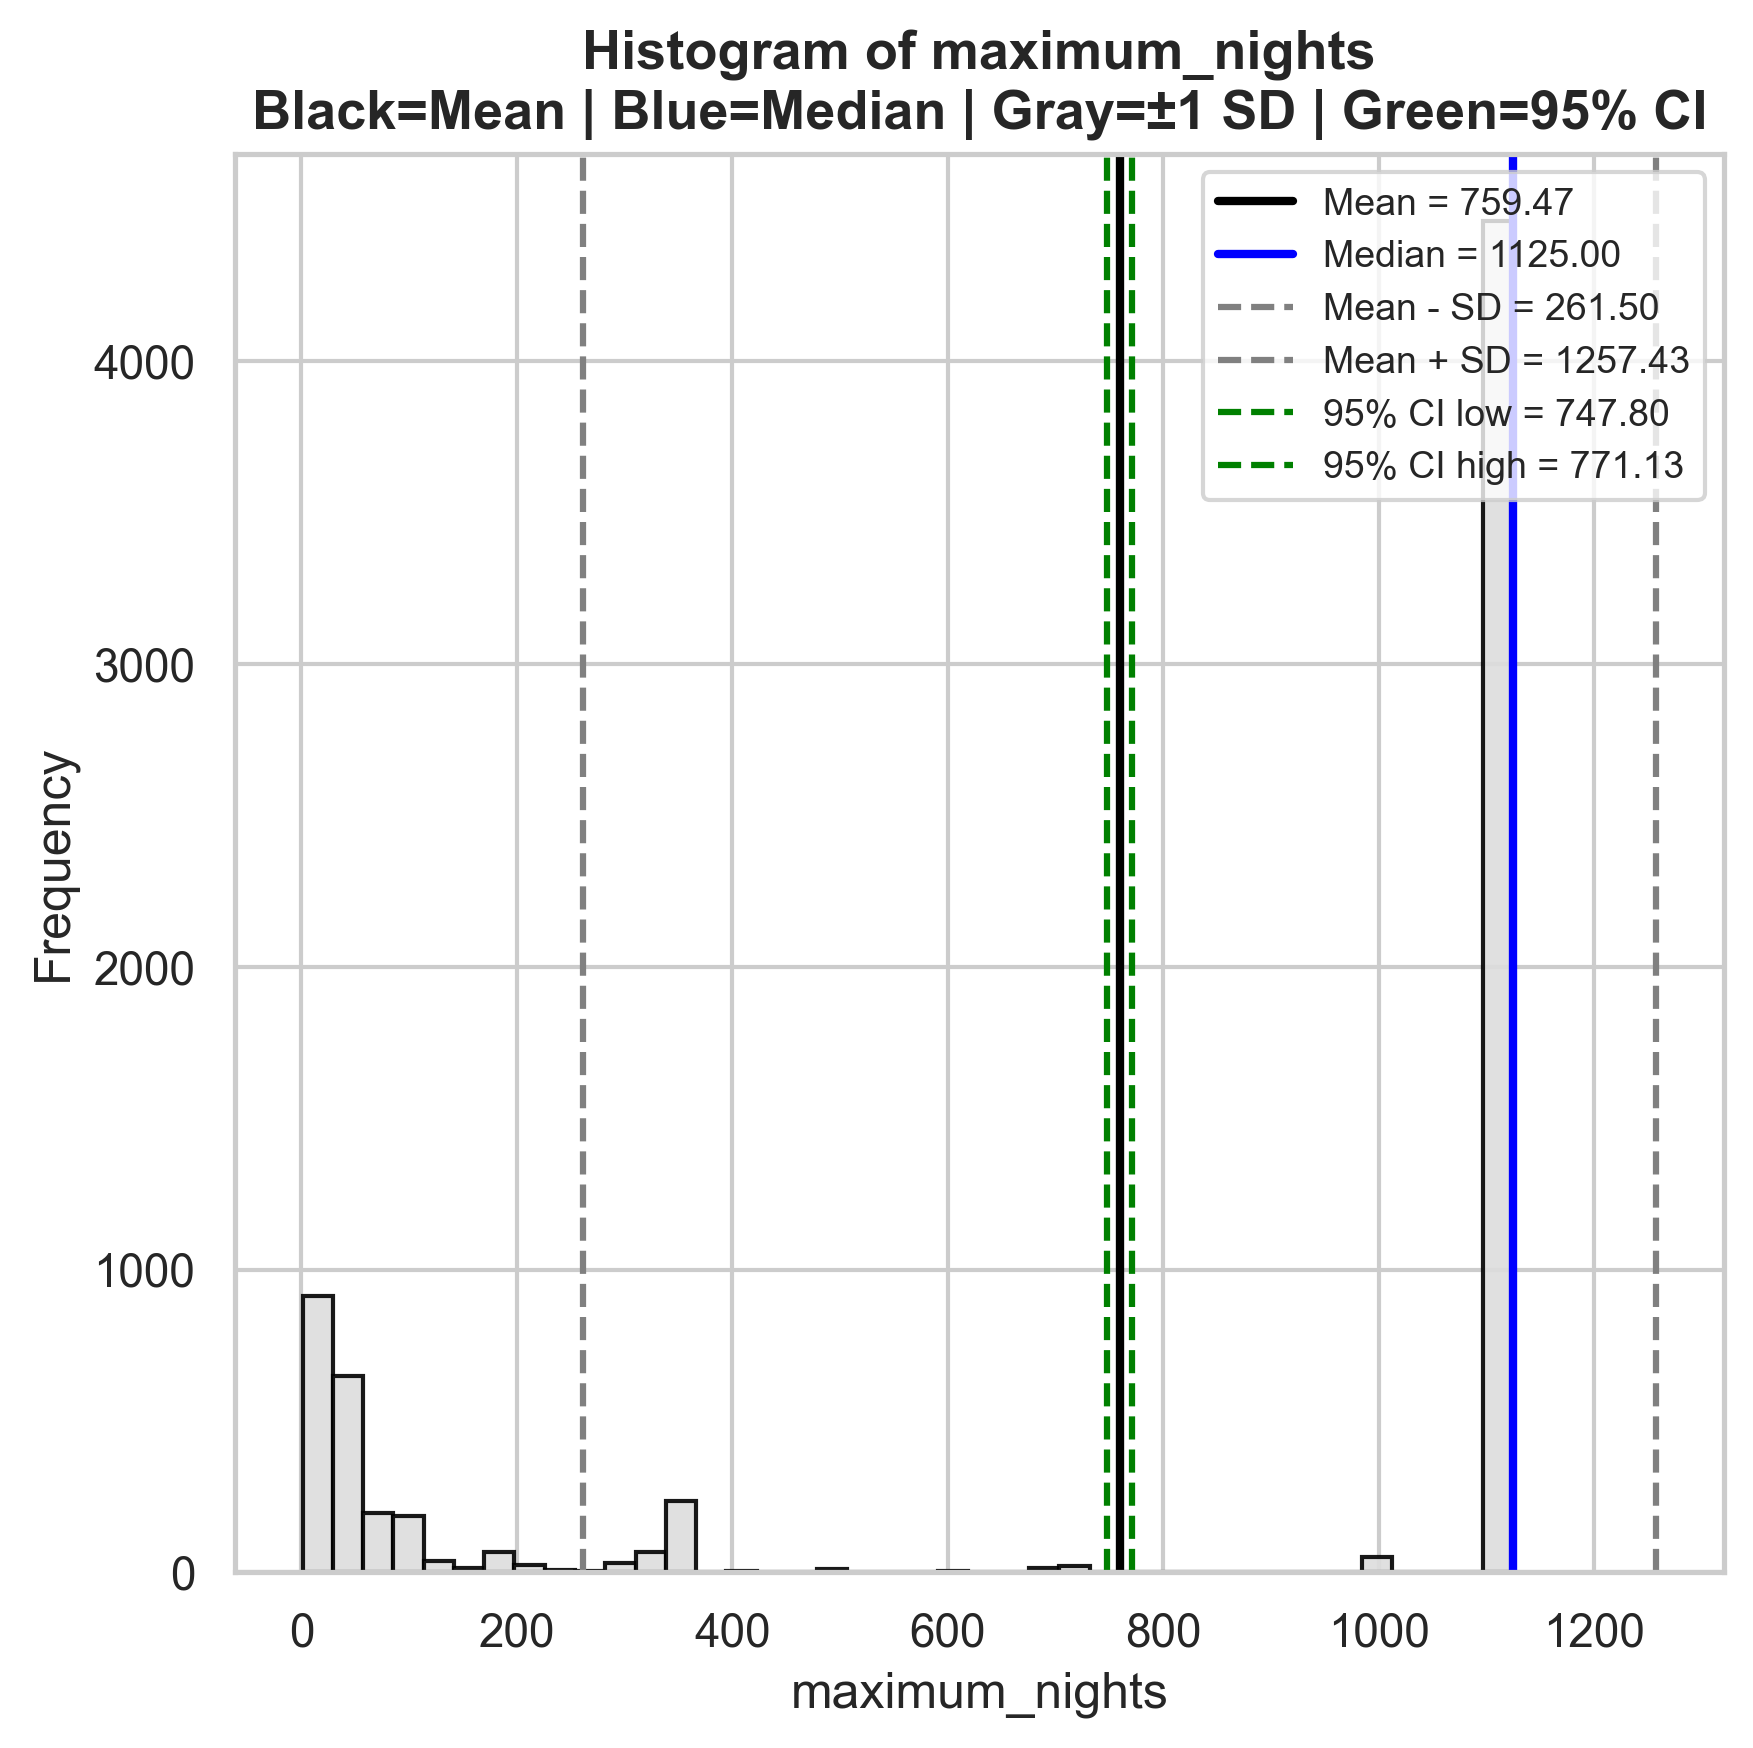

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,maximum_nights,7001,759.467647,1125.0,497.964843,747.801114,771.134181,70.0,1125.0,1055.0,-1512.5,2707.5,0,-0.675227,Moderately skewed.



Unique values table
Number of non-nulls: 7001
Number of unique values: 129


,column,value,count,frequency_non_null
0,maximum_nights,1,4,0.000571
1,maximum_nights,2,11,0.001571
2,maximum_nights,3,28,0.003999
3,maximum_nights,4,23,0.003285
4,maximum_nights,5,46,0.006570
...,...,...,...,...
124,maximum_nights,1120,17,0.002428
125,maximum_nights,1122,3,0.000429
126,maximum_nights,1123,10,0.001428
127,maximum_nights,1124,194,0.027710



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,maximum_nights,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,maximum_nights,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,maximum_nights,numeric,city,categorical,Chi-square,61.651710,7.058084e-11,Significant,Statistically significant at p < 0.05.,
3,maximum_nights,numeric,room_type,categorical,Chi-square,161.467034,8.841507e-35,Significant,Statistically significant at p < 0.05.,
4,maximum_nights,numeric,accommodates,numeric,Pearson,0.077129,1.033119e-10,Significant,Statistically significant at p < 0.05.,
5,maximum_nights,numeric,bathrooms,categorical,Chi-square,35.836169,3.442306e-04,Significant,Statistically significant at p < 0.05.,
6,maximum_nights,numeric,bedrooms,categorical,Chi-square,68.073599,1.812756e-09,Significant,Statistically significant at p < 0.05.,
7,maximum_nights,numeric,beds,numeric,Pearson,0.058816,8.498805e-07,Significant,Statistically significant at p < 0.05.,
8,maximum_nights,numeric,price,numeric,Pearson,0.033930,4.914128e-03,Significant,Statistically significant at p < 0.05.,
9,maximum_nights,numeric,minimum_nights,numeric,Pearson,-0.016810,1.596158e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-0.675227,Moderately skewed.,Baseline.
1,Log Transformation,-1.102501,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-0.779548,Moderately skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.741184,Moderately skewed.,Little change in skewness. Lambda=0.6328 did n...


In [45]:
analysis = analyze_single_field(df, 
                                target_col="maximum_nights", 
                                results_dir=RESULTS_DIR, 
                                show_in_notebook=True)

###### Availability 30 days

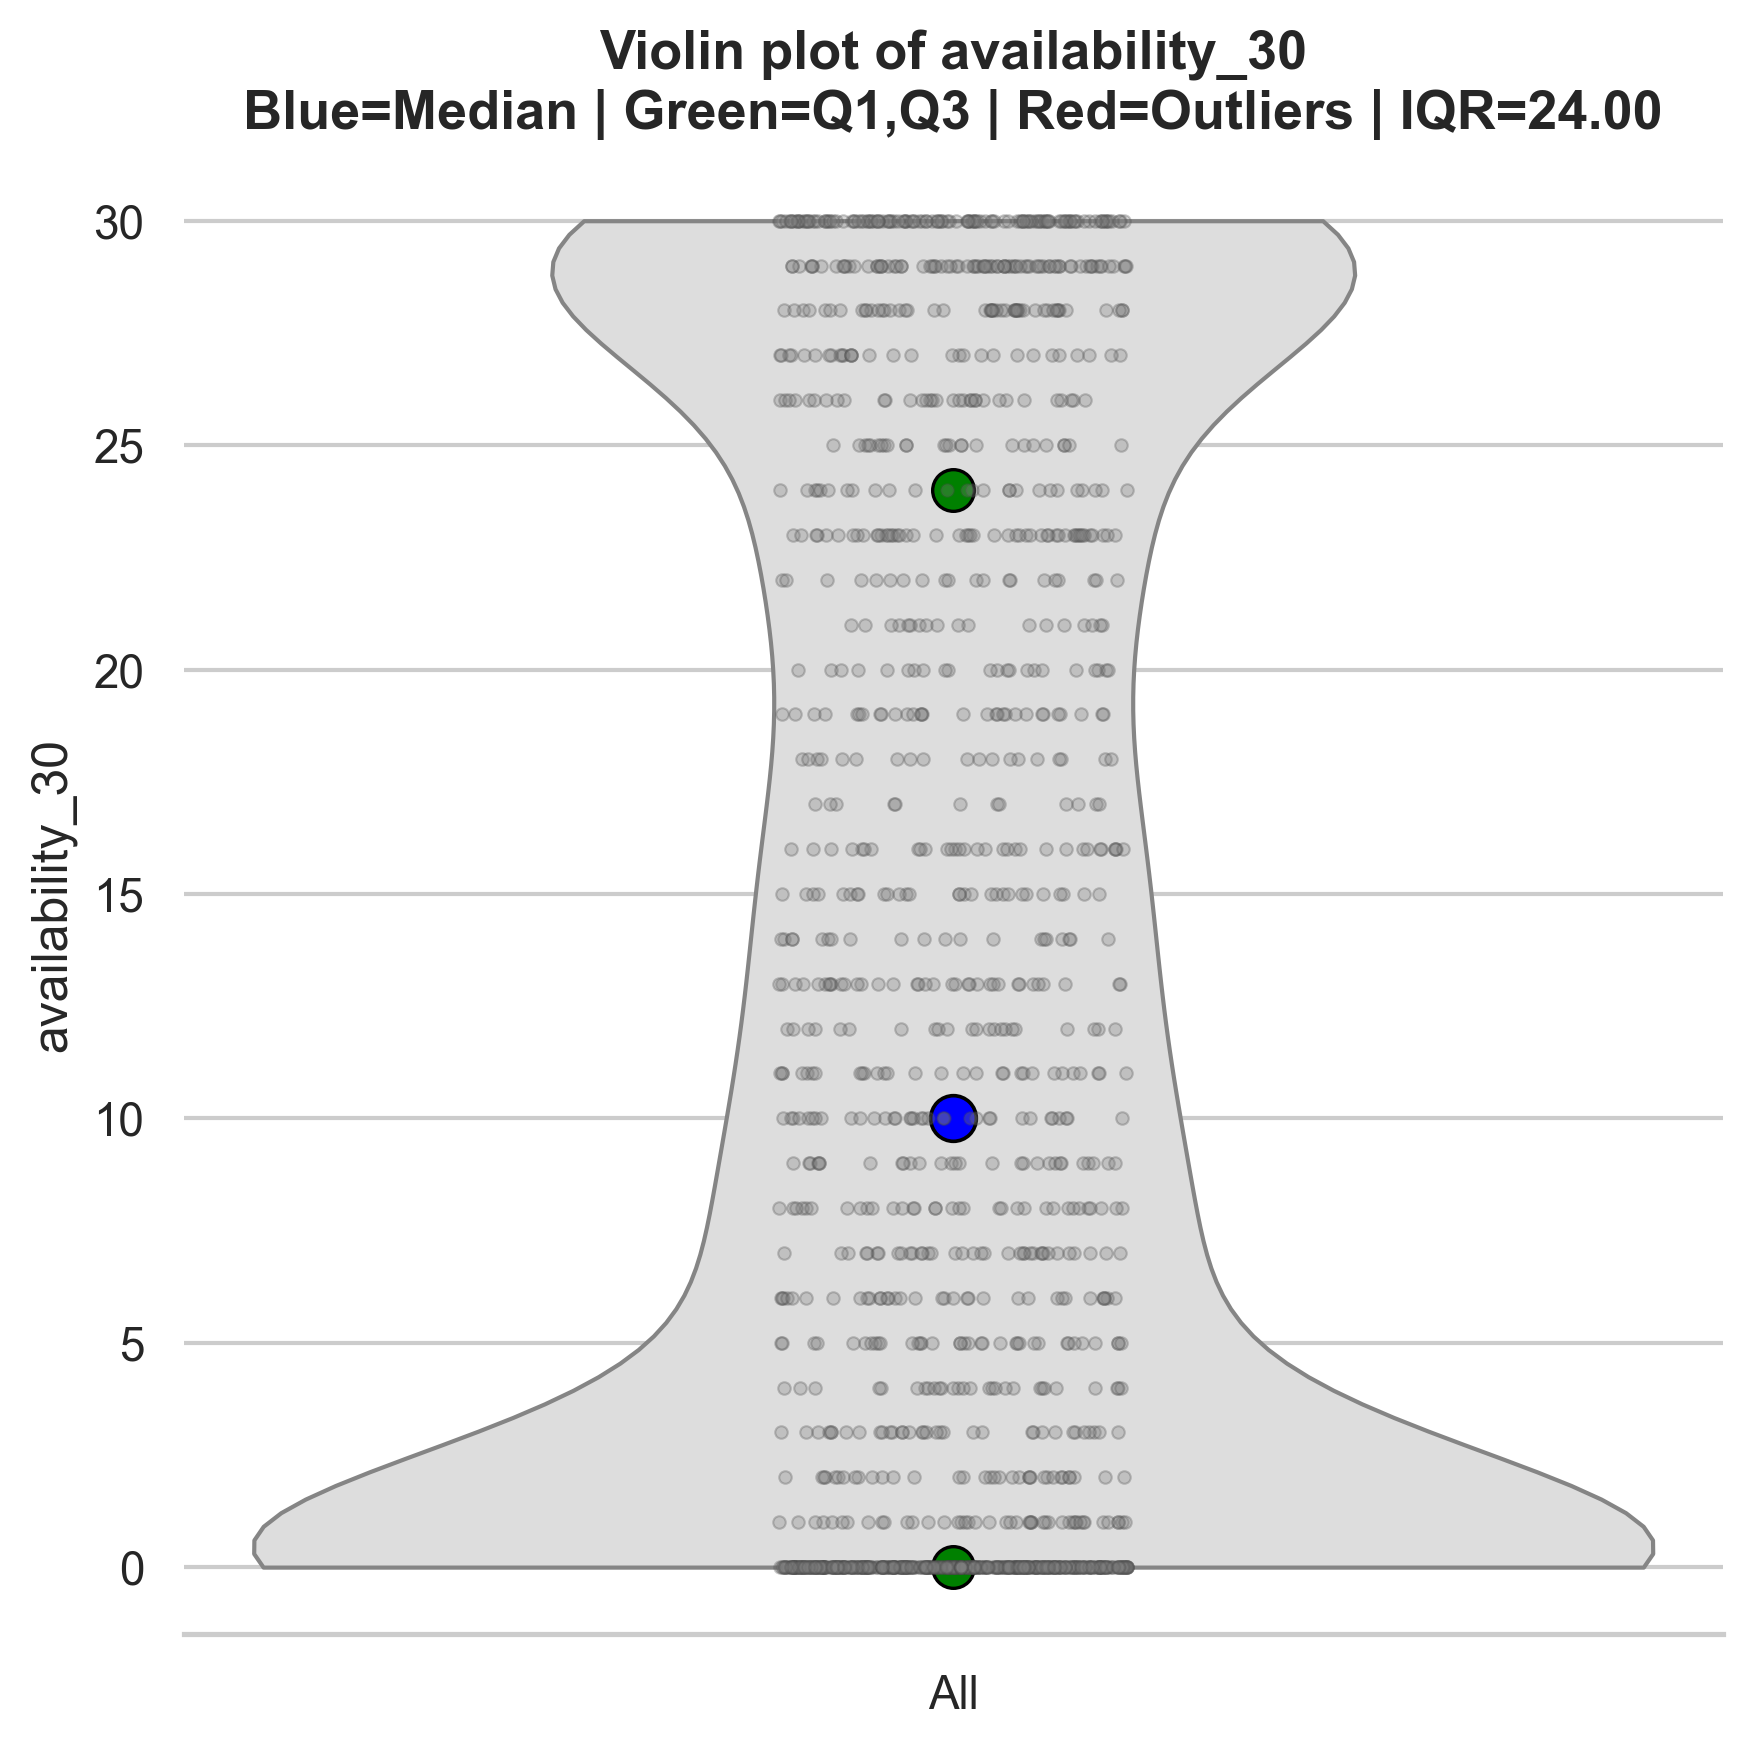

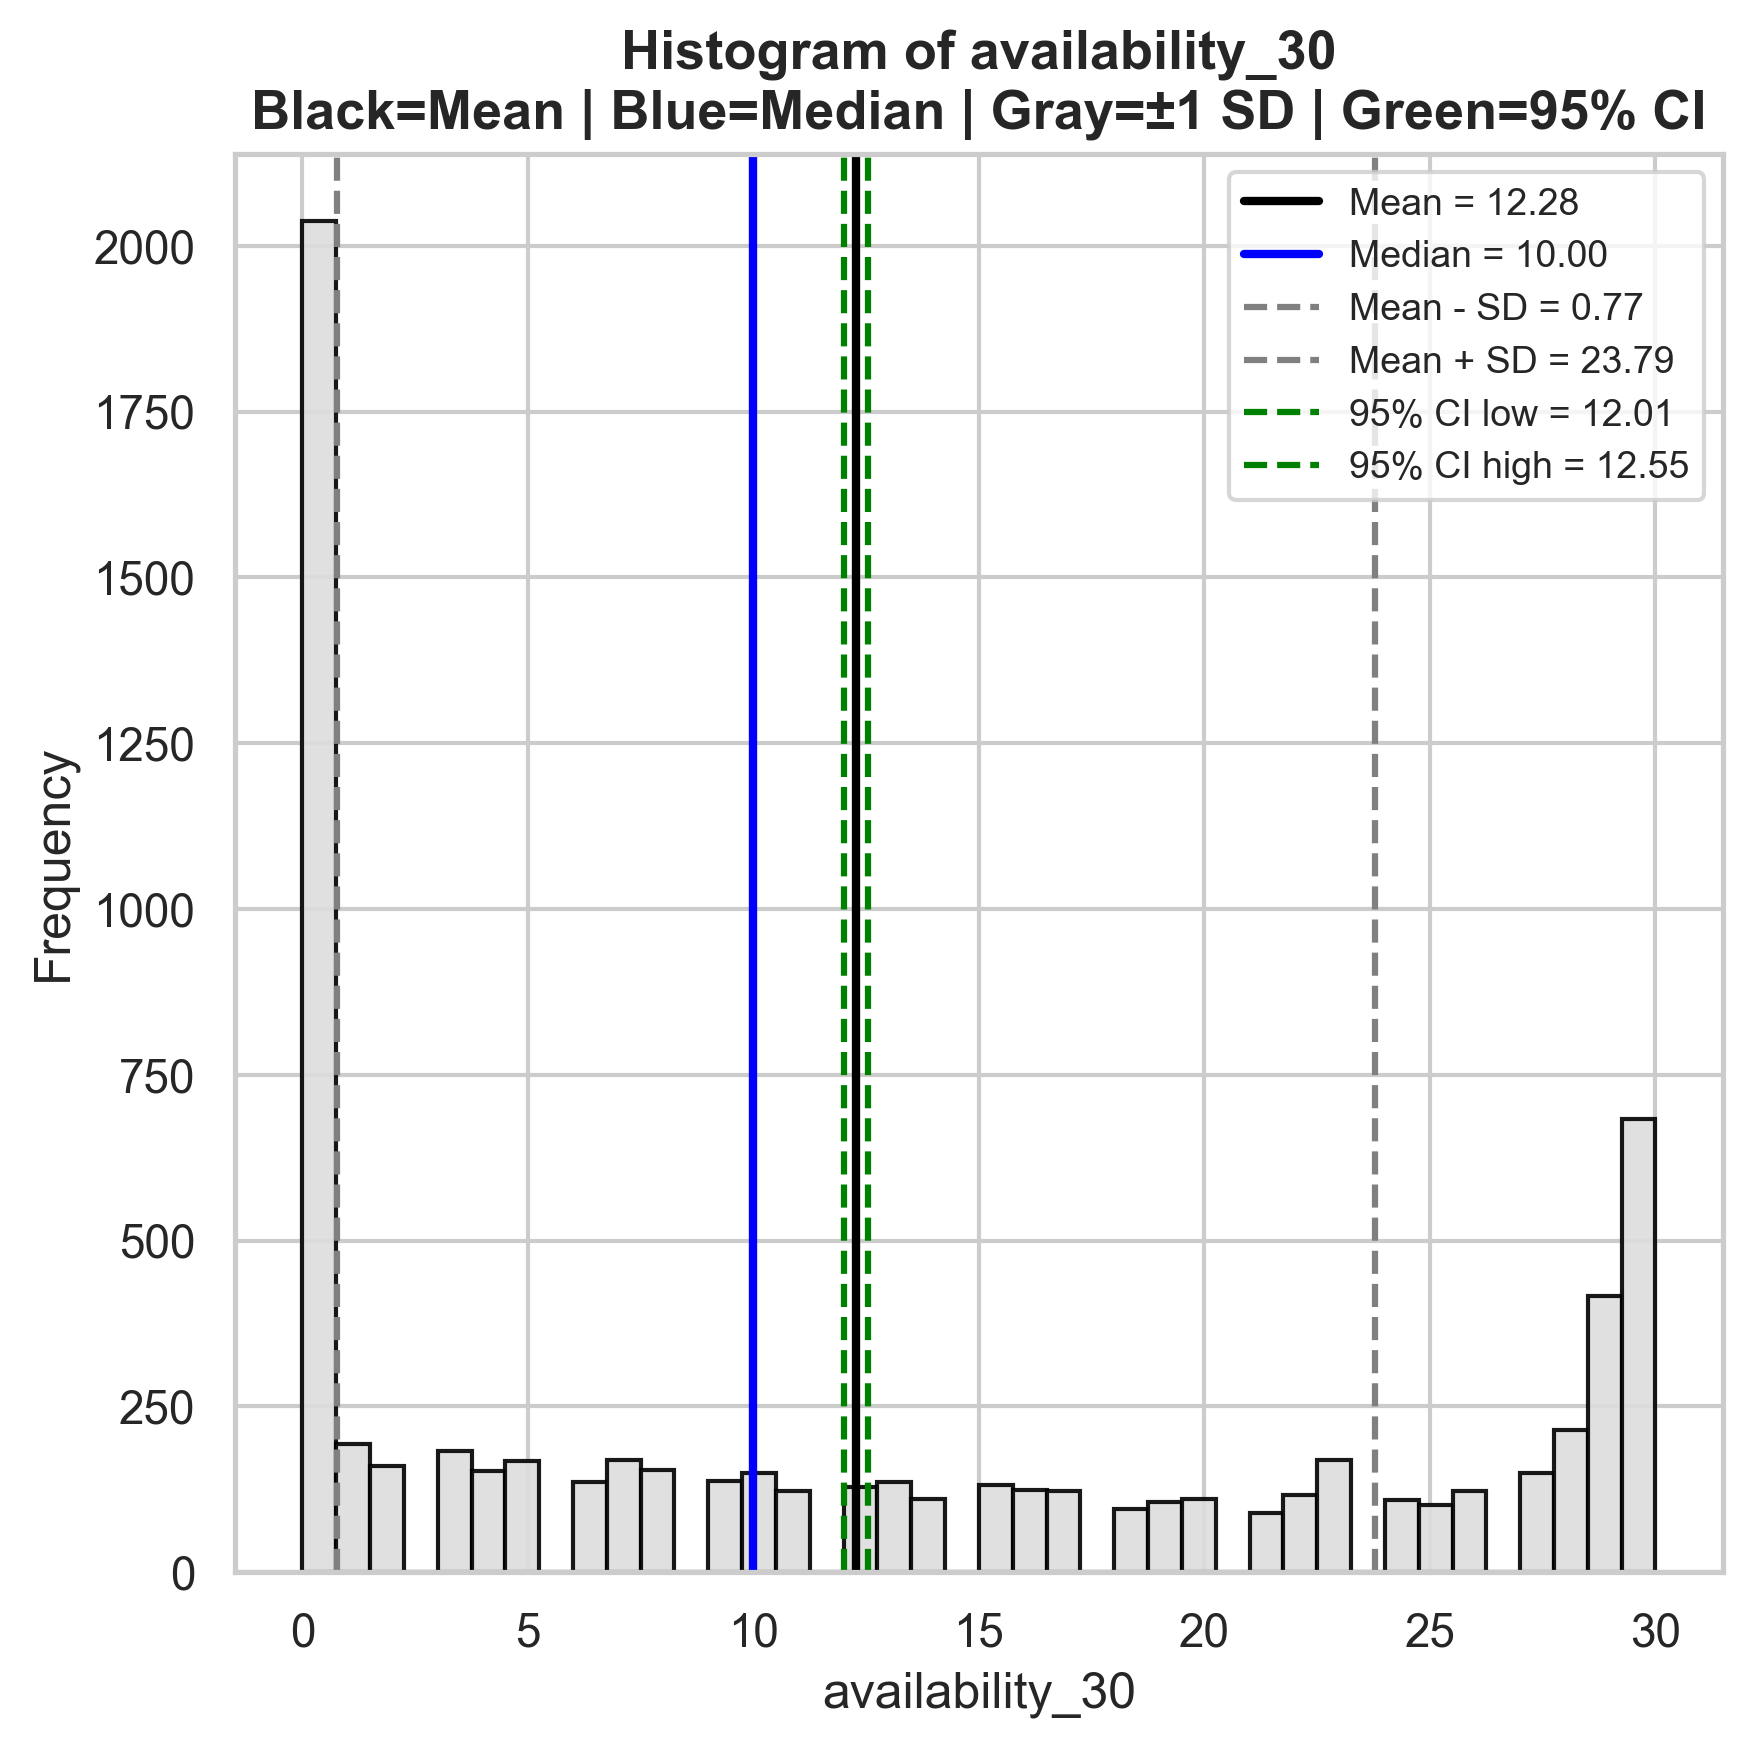

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,availability_30,7001,12.277389,10.0,11.510798,12.007709,12.547069,0.0,24.0,24.0,-36.0,60.0,0,0.343389,Approximately symmetric.



Unique values table
Number of non-nulls: 7001
Number of unique values: 31


,column,value,count,frequency_non_null
0,availability_30,0,2037,0.290958
1,availability_30,1,193,0.027567
2,availability_30,2,160,0.022854
3,availability_30,3,183,0.026139
4,availability_30,4,153,0.021854
5,availability_30,5,168,0.023997
6,availability_30,6,136,0.019426
7,availability_30,7,170,0.024282
8,availability_30,8,154,0.021997
9,availability_30,9,138,0.019711



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,availability_30,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,availability_30,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,availability_30,numeric,city,categorical,Chi-square,283.999496,5.656264e-48,Significant,Statistically significant at p < 0.05.,
3,availability_30,numeric,room_type,categorical,Chi-square,69.361413,2.031260e-11,Significant,Statistically significant at p < 0.05.,
4,availability_30,numeric,accommodates,numeric,Pearson,0.092403,9.429291e-15,Significant,Statistically significant at p < 0.05.,
5,availability_30,numeric,bathrooms,categorical,Chi-square,80.688180,2.829986e-05,Significant,Statistically significant at p < 0.05.,
6,availability_30,numeric,bedrooms,categorical,Chi-square,84.346097,3.492161e-05,Significant,Statistically significant at p < 0.05.,
7,availability_30,numeric,beds,numeric,Pearson,0.092444,9.296980e-15,Significant,Statistically significant at p < 0.05.,
8,availability_30,numeric,price,numeric,Pearson,0.106734,7.286838e-19,Significant,Statistically significant at p < 0.05.,
9,availability_30,numeric,minimum_nights,numeric,Pearson,-0.017044,1.538709e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,0.343389,Approximately symmetric.,Baseline.
1,Log Transformation,-0.372804,Approximately symmetric.,Little change in skewness.
2,Square Root Transformation,-0.161985,Approximately symmetric.,Improved strongly; distribution is closer to s...
3,Box-Cox Transformation,-0.189631,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [35]:
analysis = analyze_single_field(df, 
                                target_col="availability_30", 
                                results_dir=RESULTS_DIR, 
                                show_in_notebook=True)

<Axes: xlabel='room_type', ylabel='city'>

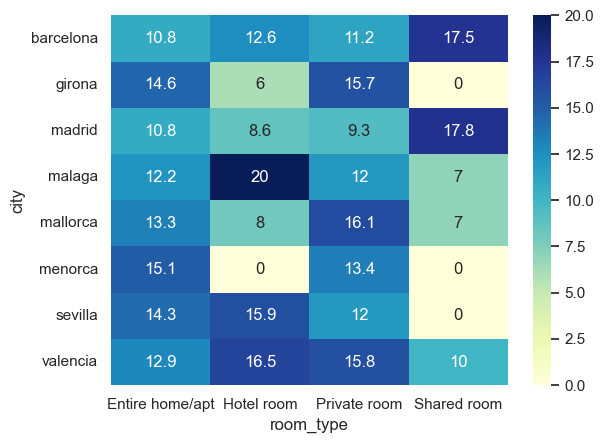

In [84]:
sns.heatmap(df.groupby(['city', 'room_type'])['availability_30'].mean().round(1).unstack(fill_value=0), annot=True, cmap='YlGnBu', fmt='g')

###### Availability 60 days

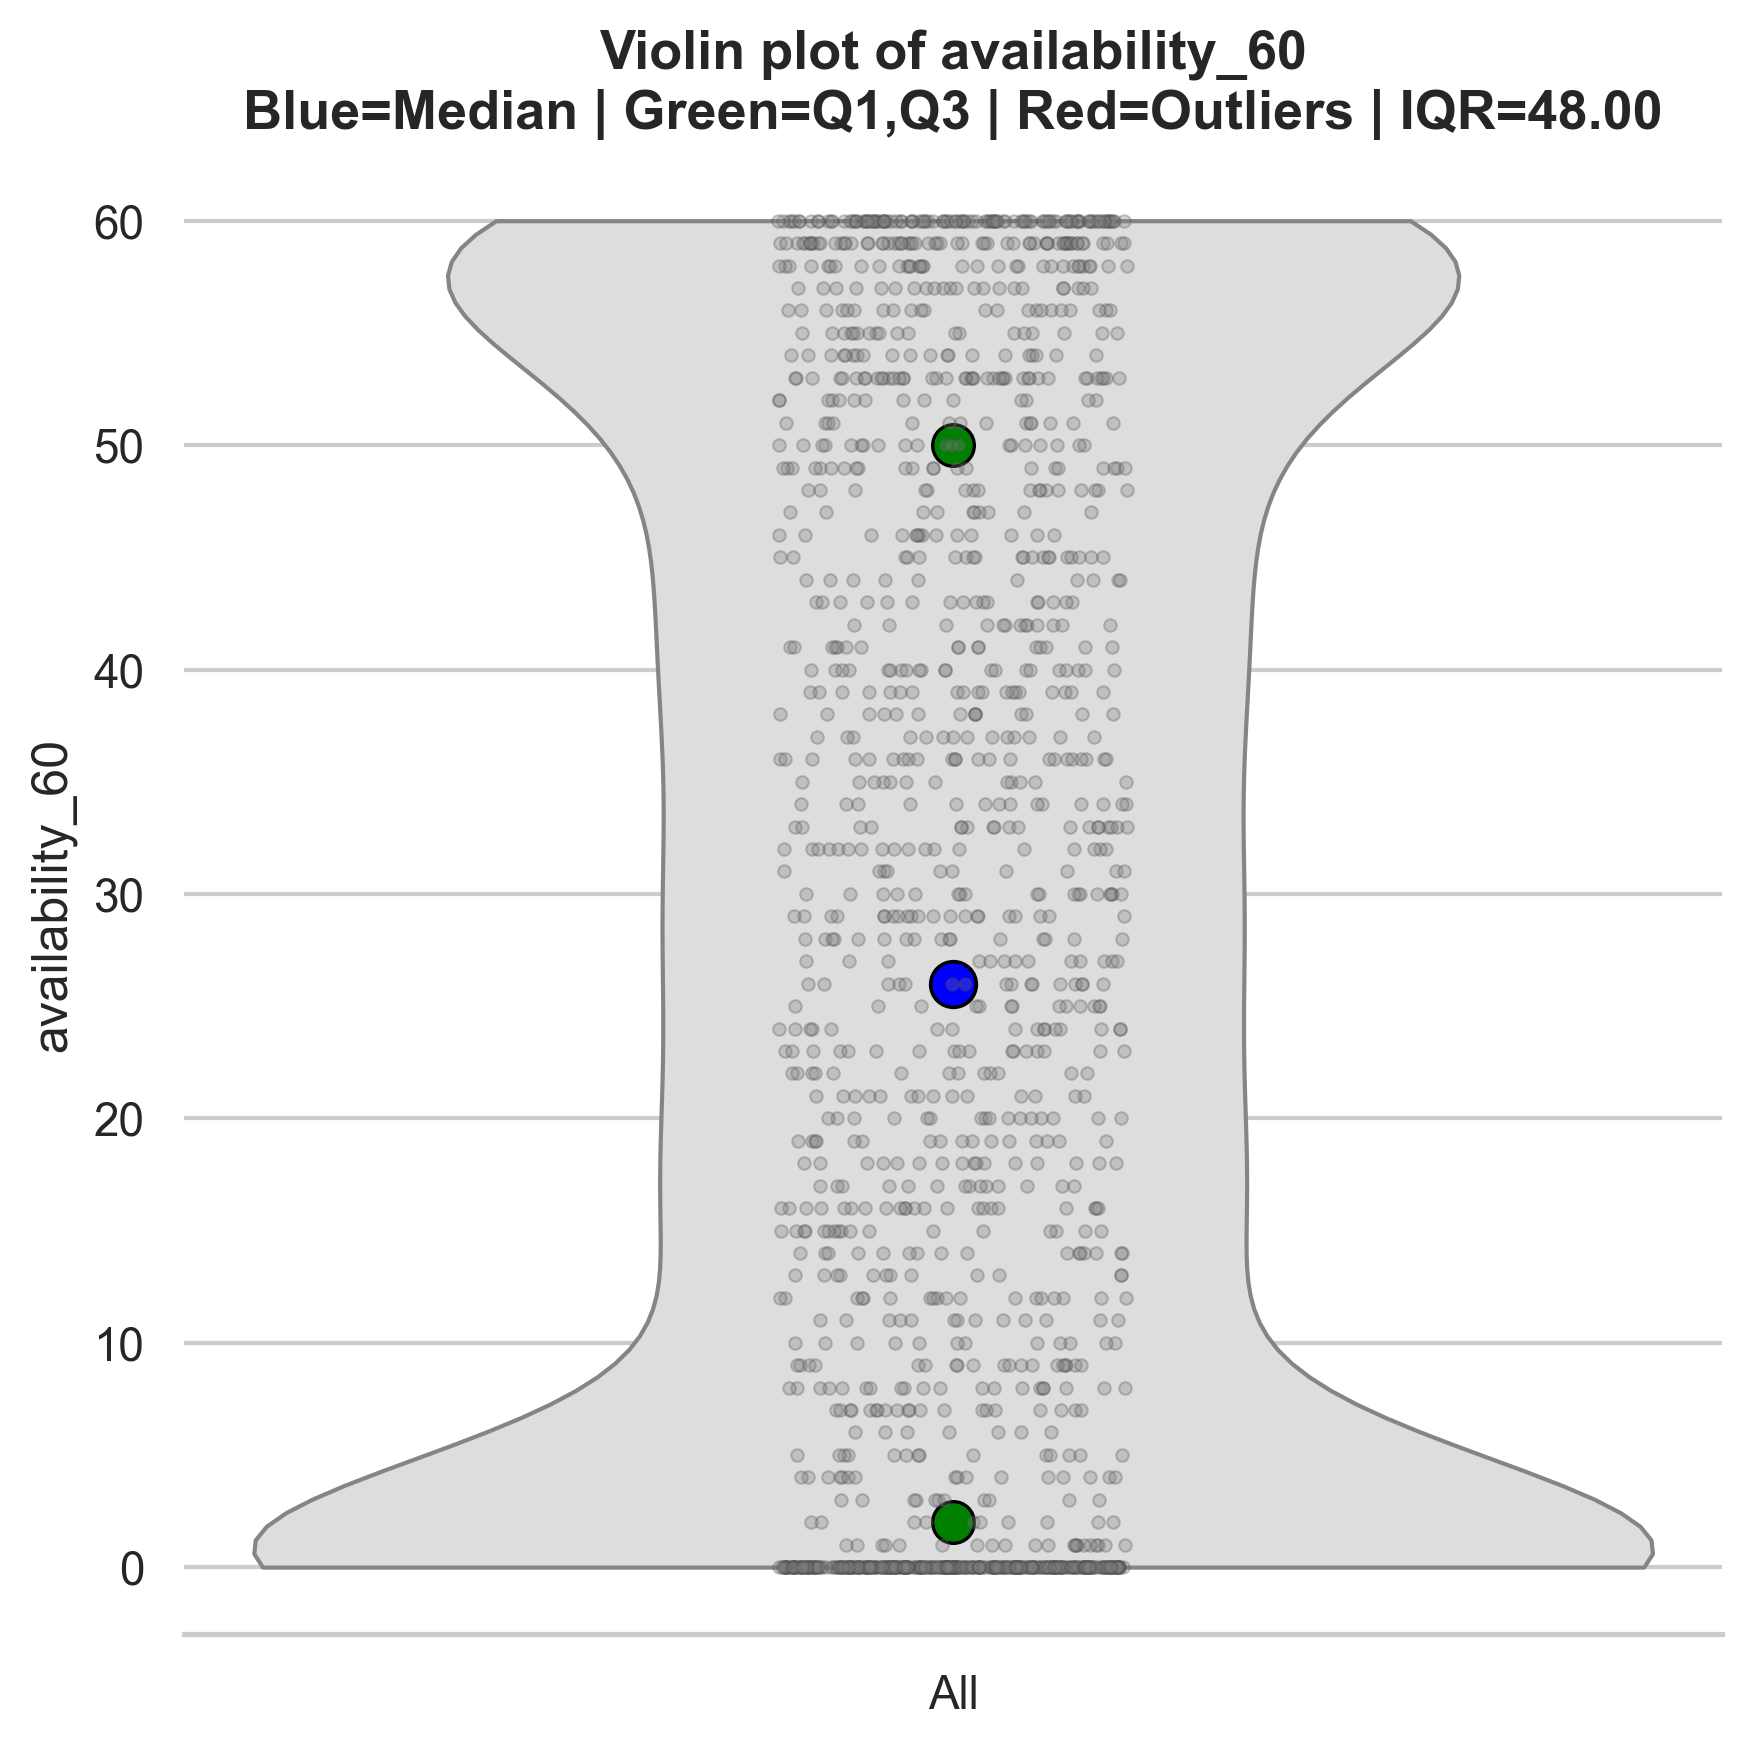

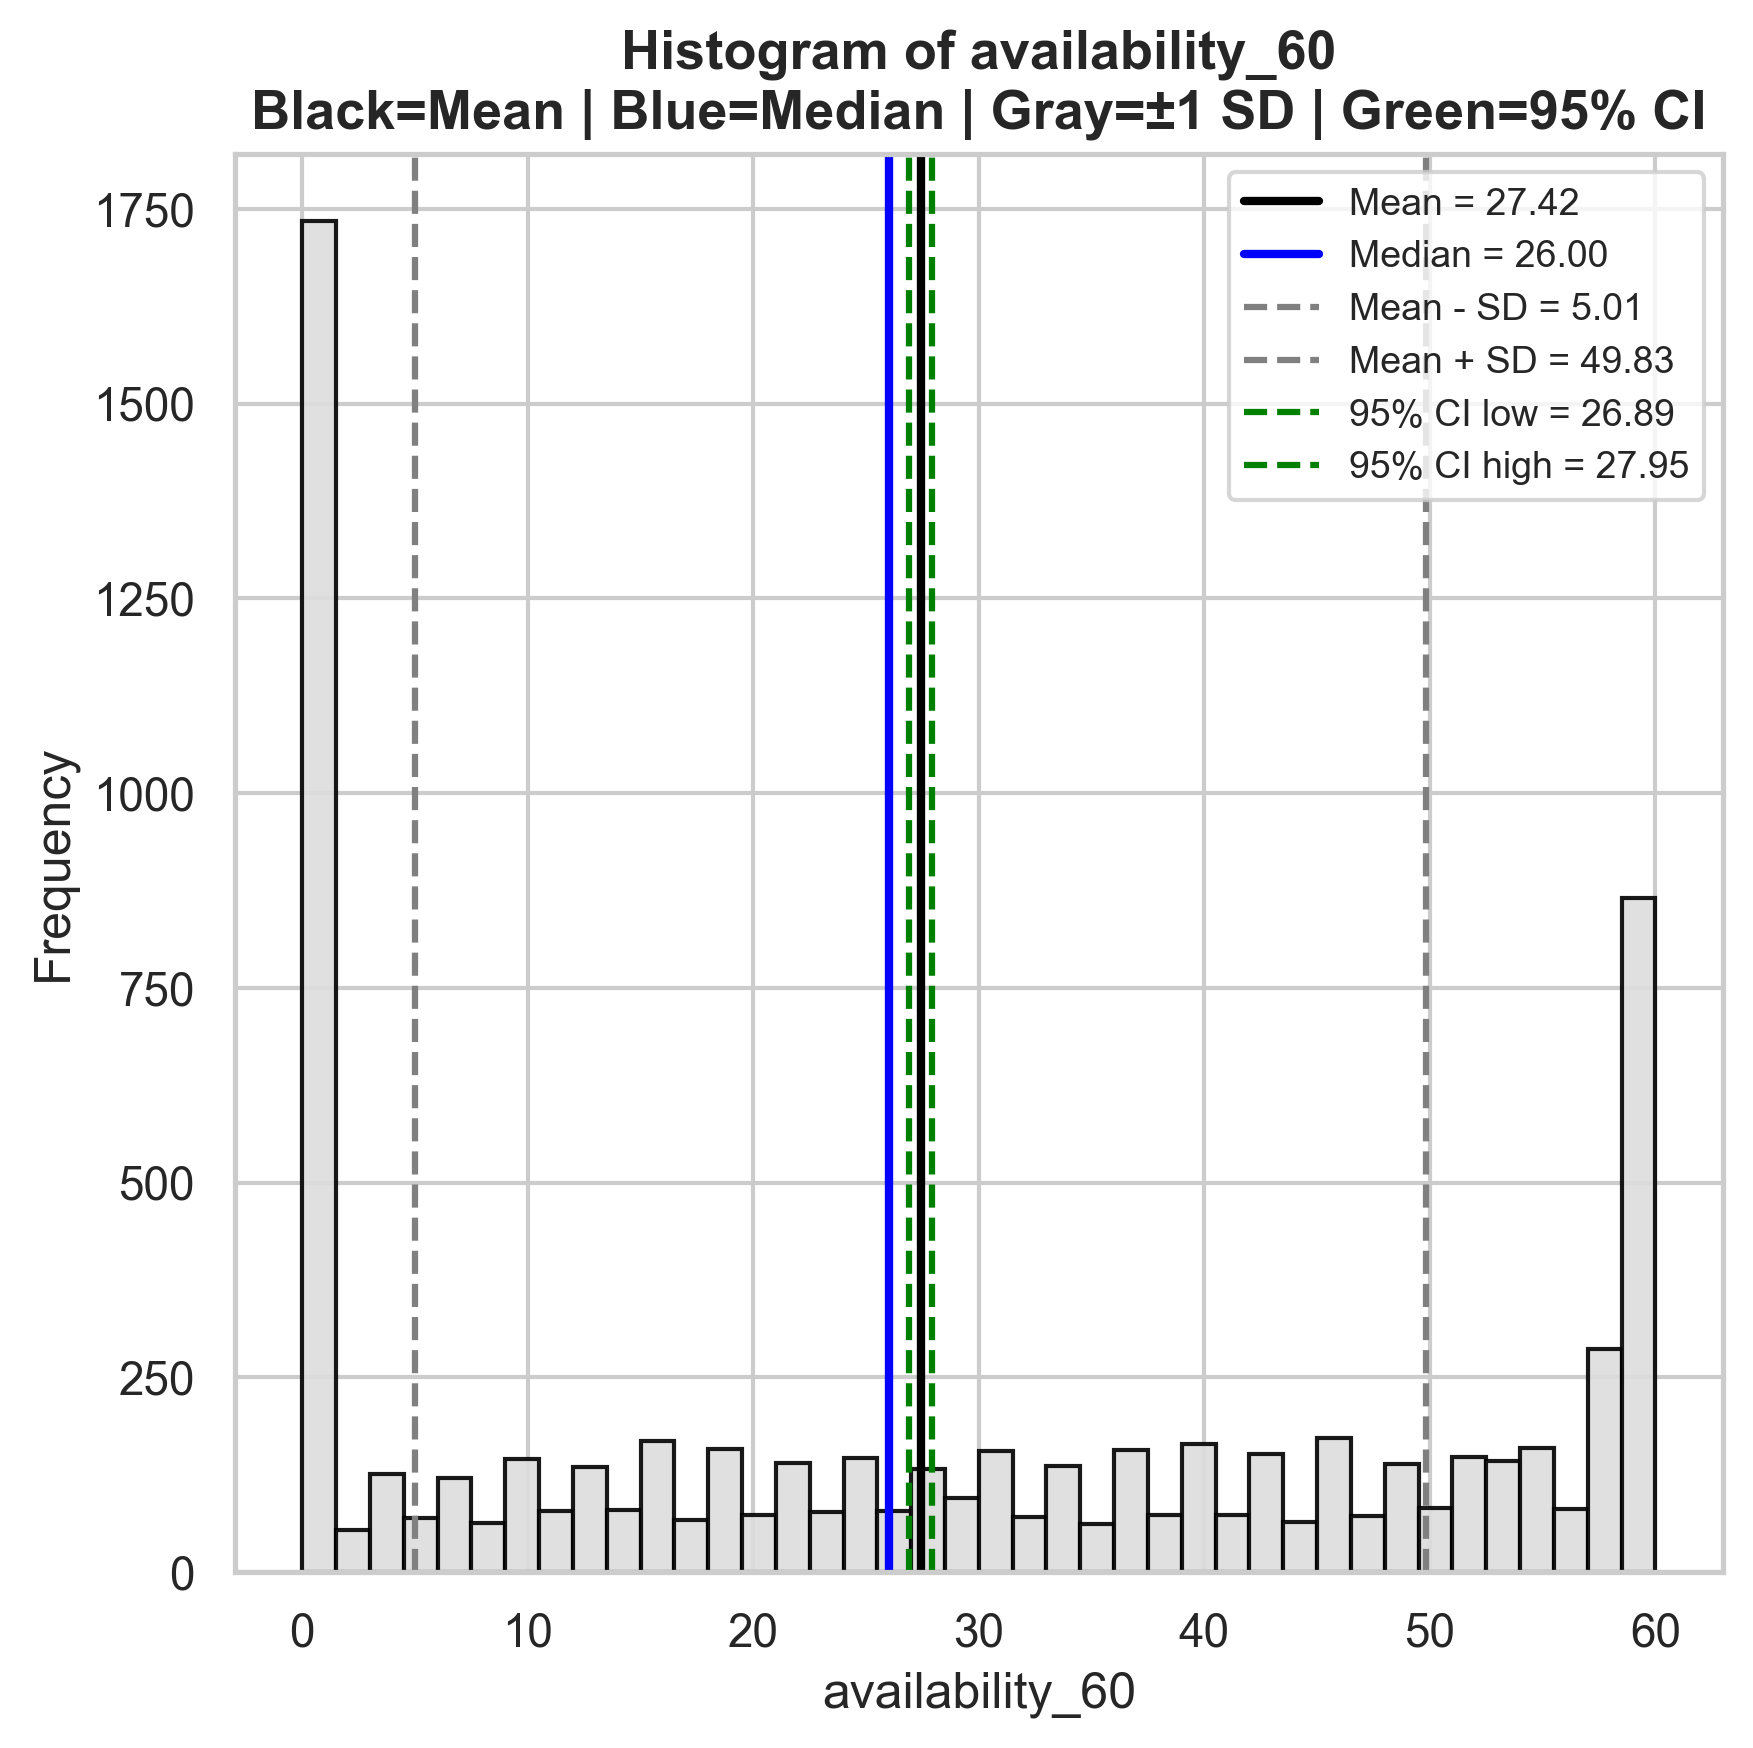

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,availability_60,7001,27.41994,26.0,22.413425,26.894829,27.945051,2.0,50.0,48.0,-70.0,122.0,0,0.112523,Approximately symmetric.



Unique values table
Number of non-nulls: 7001
Number of unique values: 61


,column,value,count,frequency_non_null
0,availability_60,0,1629,0.232681
1,availability_60,1,105,0.014998
2,availability_60,2,54,0.007713
3,availability_60,3,64,0.009142
4,availability_60,4,62,0.008856
...,...,...,...,...
56,availability_60,56,81,0.011570
57,availability_60,57,114,0.016283
58,availability_60,58,173,0.024711
59,availability_60,59,322,0.045993



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,availability_60,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,availability_60,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,availability_60,numeric,city,categorical,Chi-square,166.103321,1.454155e-24,Significant,Statistically significant at p < 0.05.,
3,availability_60,numeric,room_type,categorical,Chi-square,111.788491,6.355204e-20,Significant,Statistically significant at p < 0.05.,
4,availability_60,numeric,accommodates,numeric,Pearson,0.077178,1.005584e-10,Significant,Statistically significant at p < 0.05.,
5,availability_60,numeric,bathrooms,categorical,Chi-square,71.878399,3.519013e-04,Significant,Statistically significant at p < 0.05.,
6,availability_60,numeric,bedrooms,categorical,Chi-square,86.655124,1.781446e-05,Significant,Statistically significant at p < 0.05.,
7,availability_60,numeric,beds,numeric,Pearson,0.071706,1.911107e-09,Significant,Statistically significant at p < 0.05.,
8,availability_60,numeric,price,numeric,Pearson,0.090810,4.662474e-14,Significant,Statistically significant at p < 0.05.,
9,availability_60,numeric,minimum_nights,numeric,Pearson,-0.018685,1.179921e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,0.112523,Approximately symmetric.,Baseline.
1,Log Transformation,-0.768209,Moderately skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-0.434739,Approximately symmetric.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.376494,Approximately symmetric.,Did not improve normality; skewness increased....


In [85]:
analysis = analyze_single_field(df, 
                                target_col="availability_60", 
                                results_dir=RESULTS_DIR, 
                                show_in_notebook=True)

<Axes: xlabel='room_type', ylabel='city'>

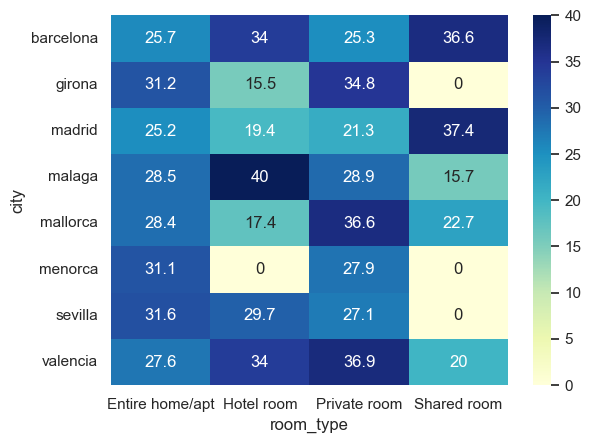

In [86]:
sns.heatmap(df.groupby(['city', 'room_type'])['availability_60'].mean().round(1).unstack(fill_value=0), annot=True, cmap='YlGnBu', fmt='g')

###### Availability 90 days

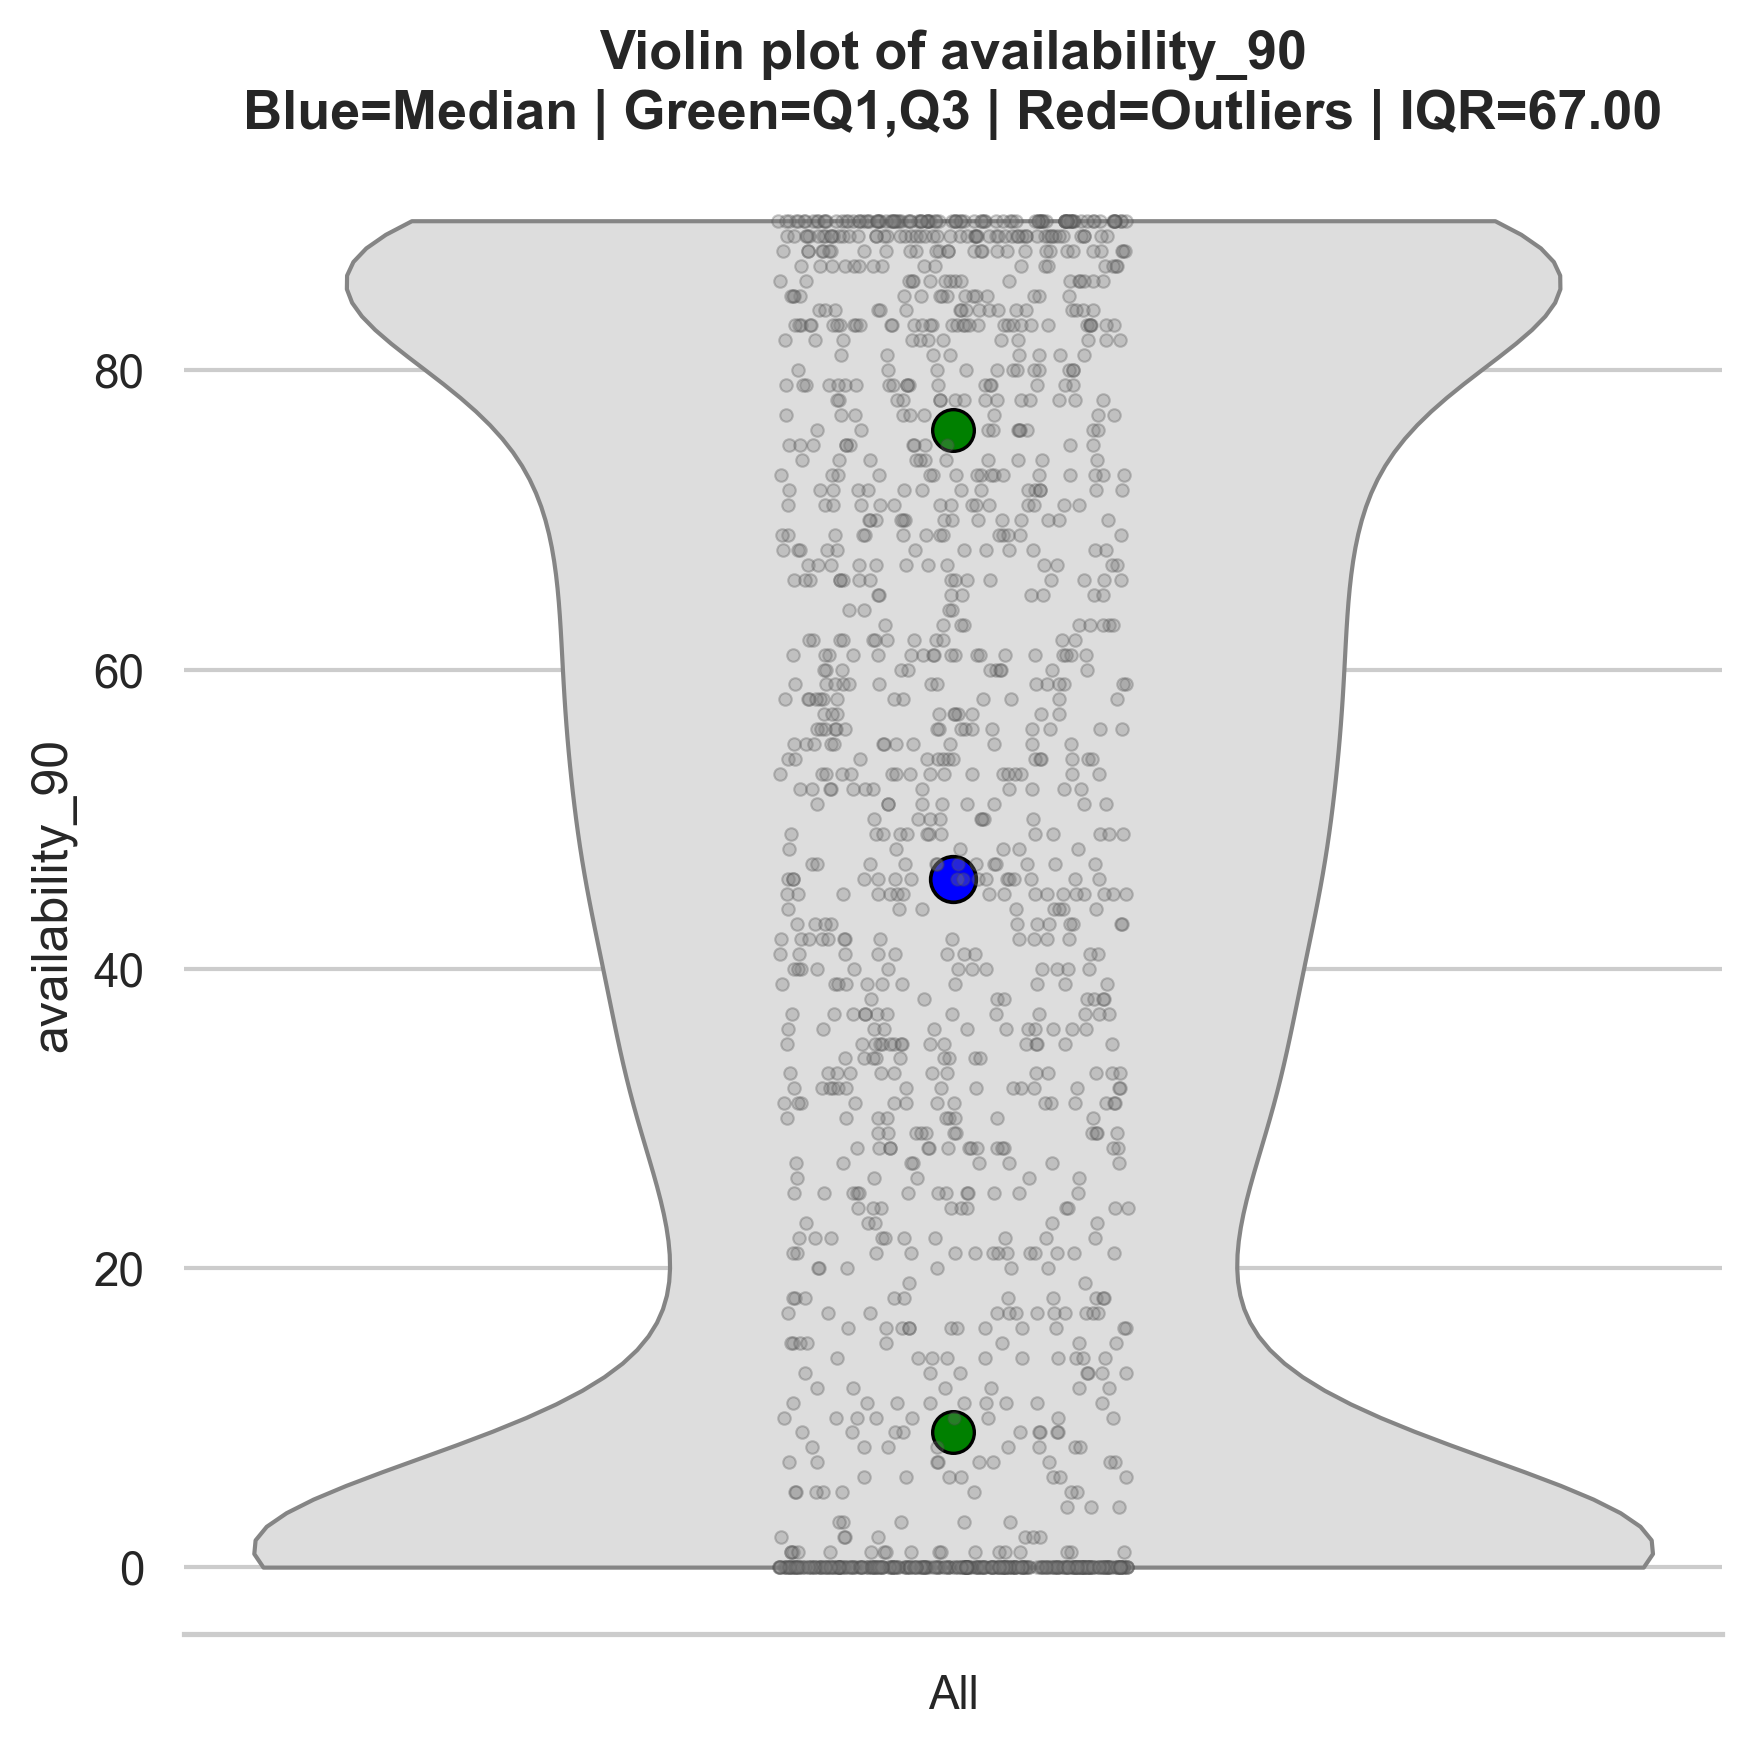

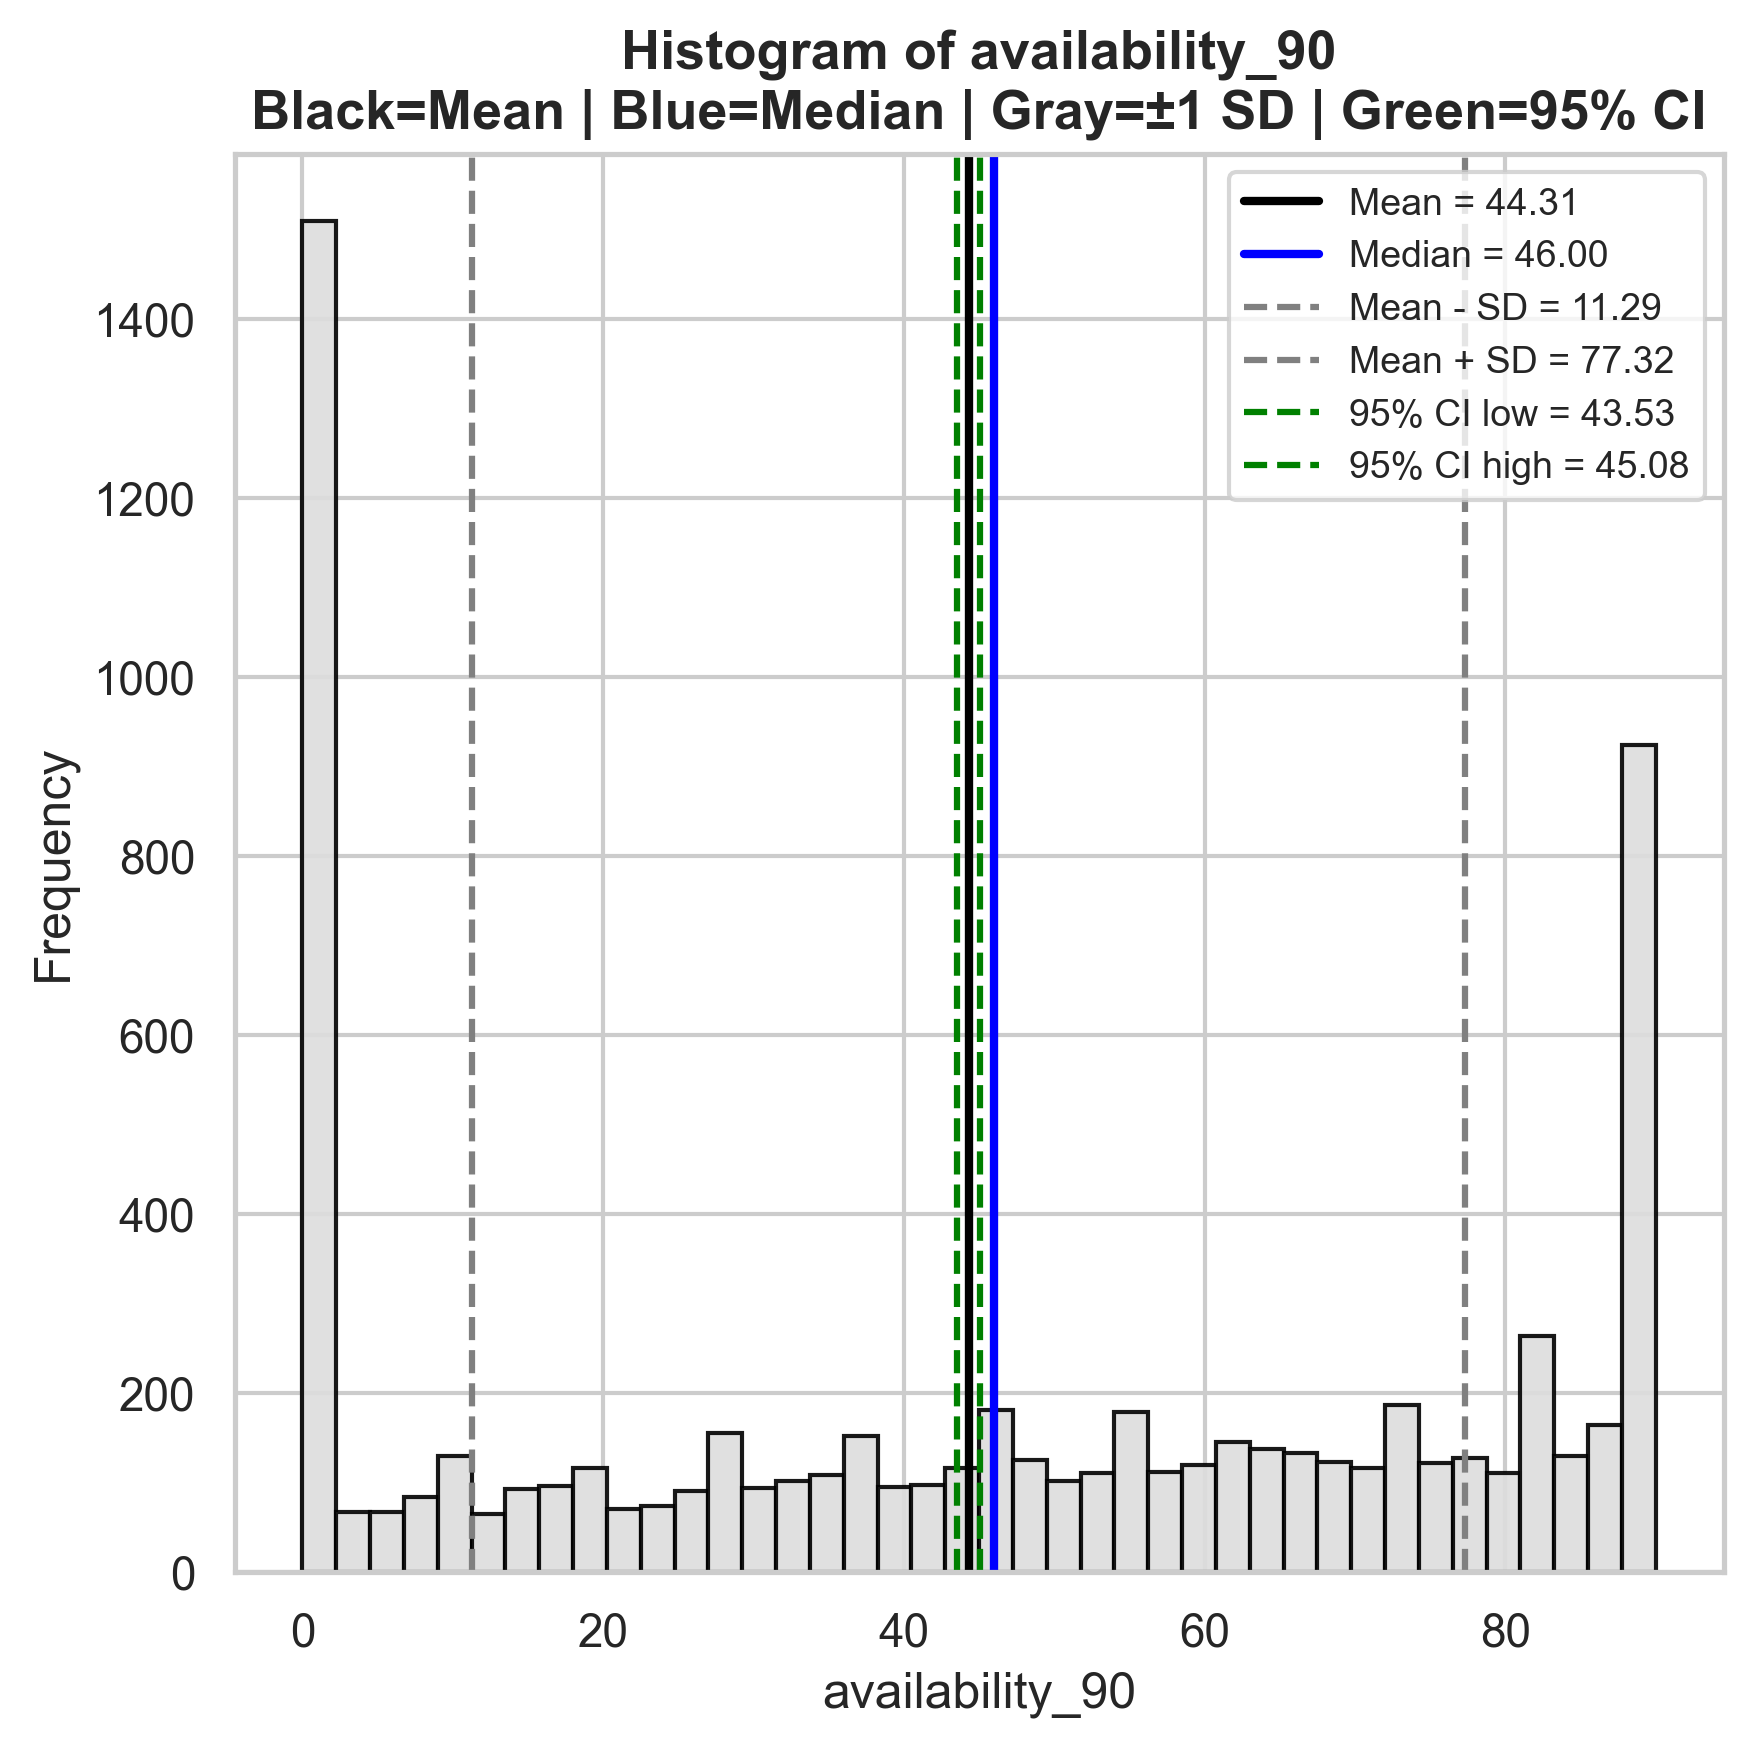

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,availability_90,7001,44.30667,46.0,33.017183,43.53313,45.080211,9.0,76.0,67.0,-91.5,176.5,0,-0.058095,Approximately symmetric.



Unique values table
Number of non-nulls: 7001
Number of unique values: 91


,column,value,count,frequency_non_null
0,availability_90,0,1385,0.197829
1,availability_90,1,83,0.011855
2,availability_90,2,41,0.005856
3,availability_90,3,40,0.005713
4,availability_90,4,27,0.003857
...,...,...,...,...
86,availability_90,86,74,0.010570
87,availability_90,87,91,0.012998
88,availability_90,88,145,0.020711
89,availability_90,89,288,0.041137



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,availability_90,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,availability_90,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,availability_90,numeric,city,categorical,Chi-square,199.707193,7.788055e-28,Significant,Statistically significant at p < 0.05.,
3,availability_90,numeric,room_type,categorical,Chi-square,194.750458,3.946216e-35,Significant,Statistically significant at p < 0.05.,
4,availability_90,numeric,accommodates,numeric,Pearson,0.061819,2.260546e-07,Significant,Statistically significant at p < 0.05.,
5,availability_90,numeric,bathrooms,categorical,Chi-square,89.525253,2.593357e-04,Significant,Statistically significant at p < 0.05.,
6,availability_90,numeric,bedrooms,categorical,Chi-square,152.953061,7.116674e-12,Significant,Statistically significant at p < 0.05.,
7,availability_90,numeric,beds,numeric,Pearson,0.051901,1.399796e-05,Significant,Statistically significant at p < 0.05.,
8,availability_90,numeric,price,numeric,Pearson,0.077888,1.016709e-10,Significant,Statistically significant at p < 0.05.,
9,availability_90,numeric,minimum_nights,numeric,Pearson,-0.015513,1.943392e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-0.058095,Approximately symmetric.,Baseline.
1,Log Transformation,-1.021430,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-0.621749,Moderately skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.493835,Approximately symmetric.,Did not improve normality; skewness increased....


In [87]:
analysis = analyze_single_field(df, 
                                target_col="availability_90", 
                                results_dir=RESULTS_DIR, 
                                show_in_notebook=True)

<Axes: xlabel='room_type', ylabel='city'>

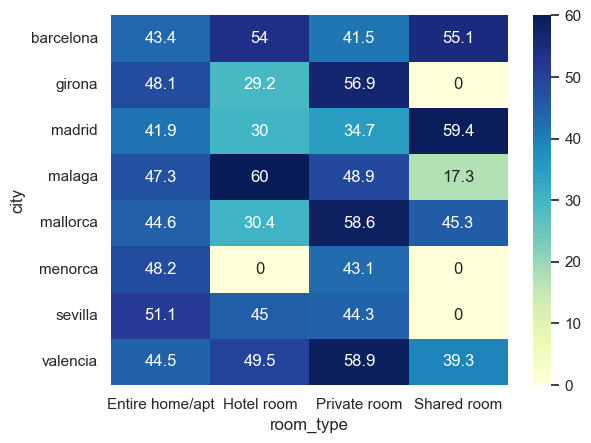

In [88]:
sns.heatmap(df.groupby(['city', 'room_type'])['availability_90'].mean().round(1).unstack(fill_value=0), annot=True, cmap='YlGnBu', fmt='g')

###### Availability 365 days

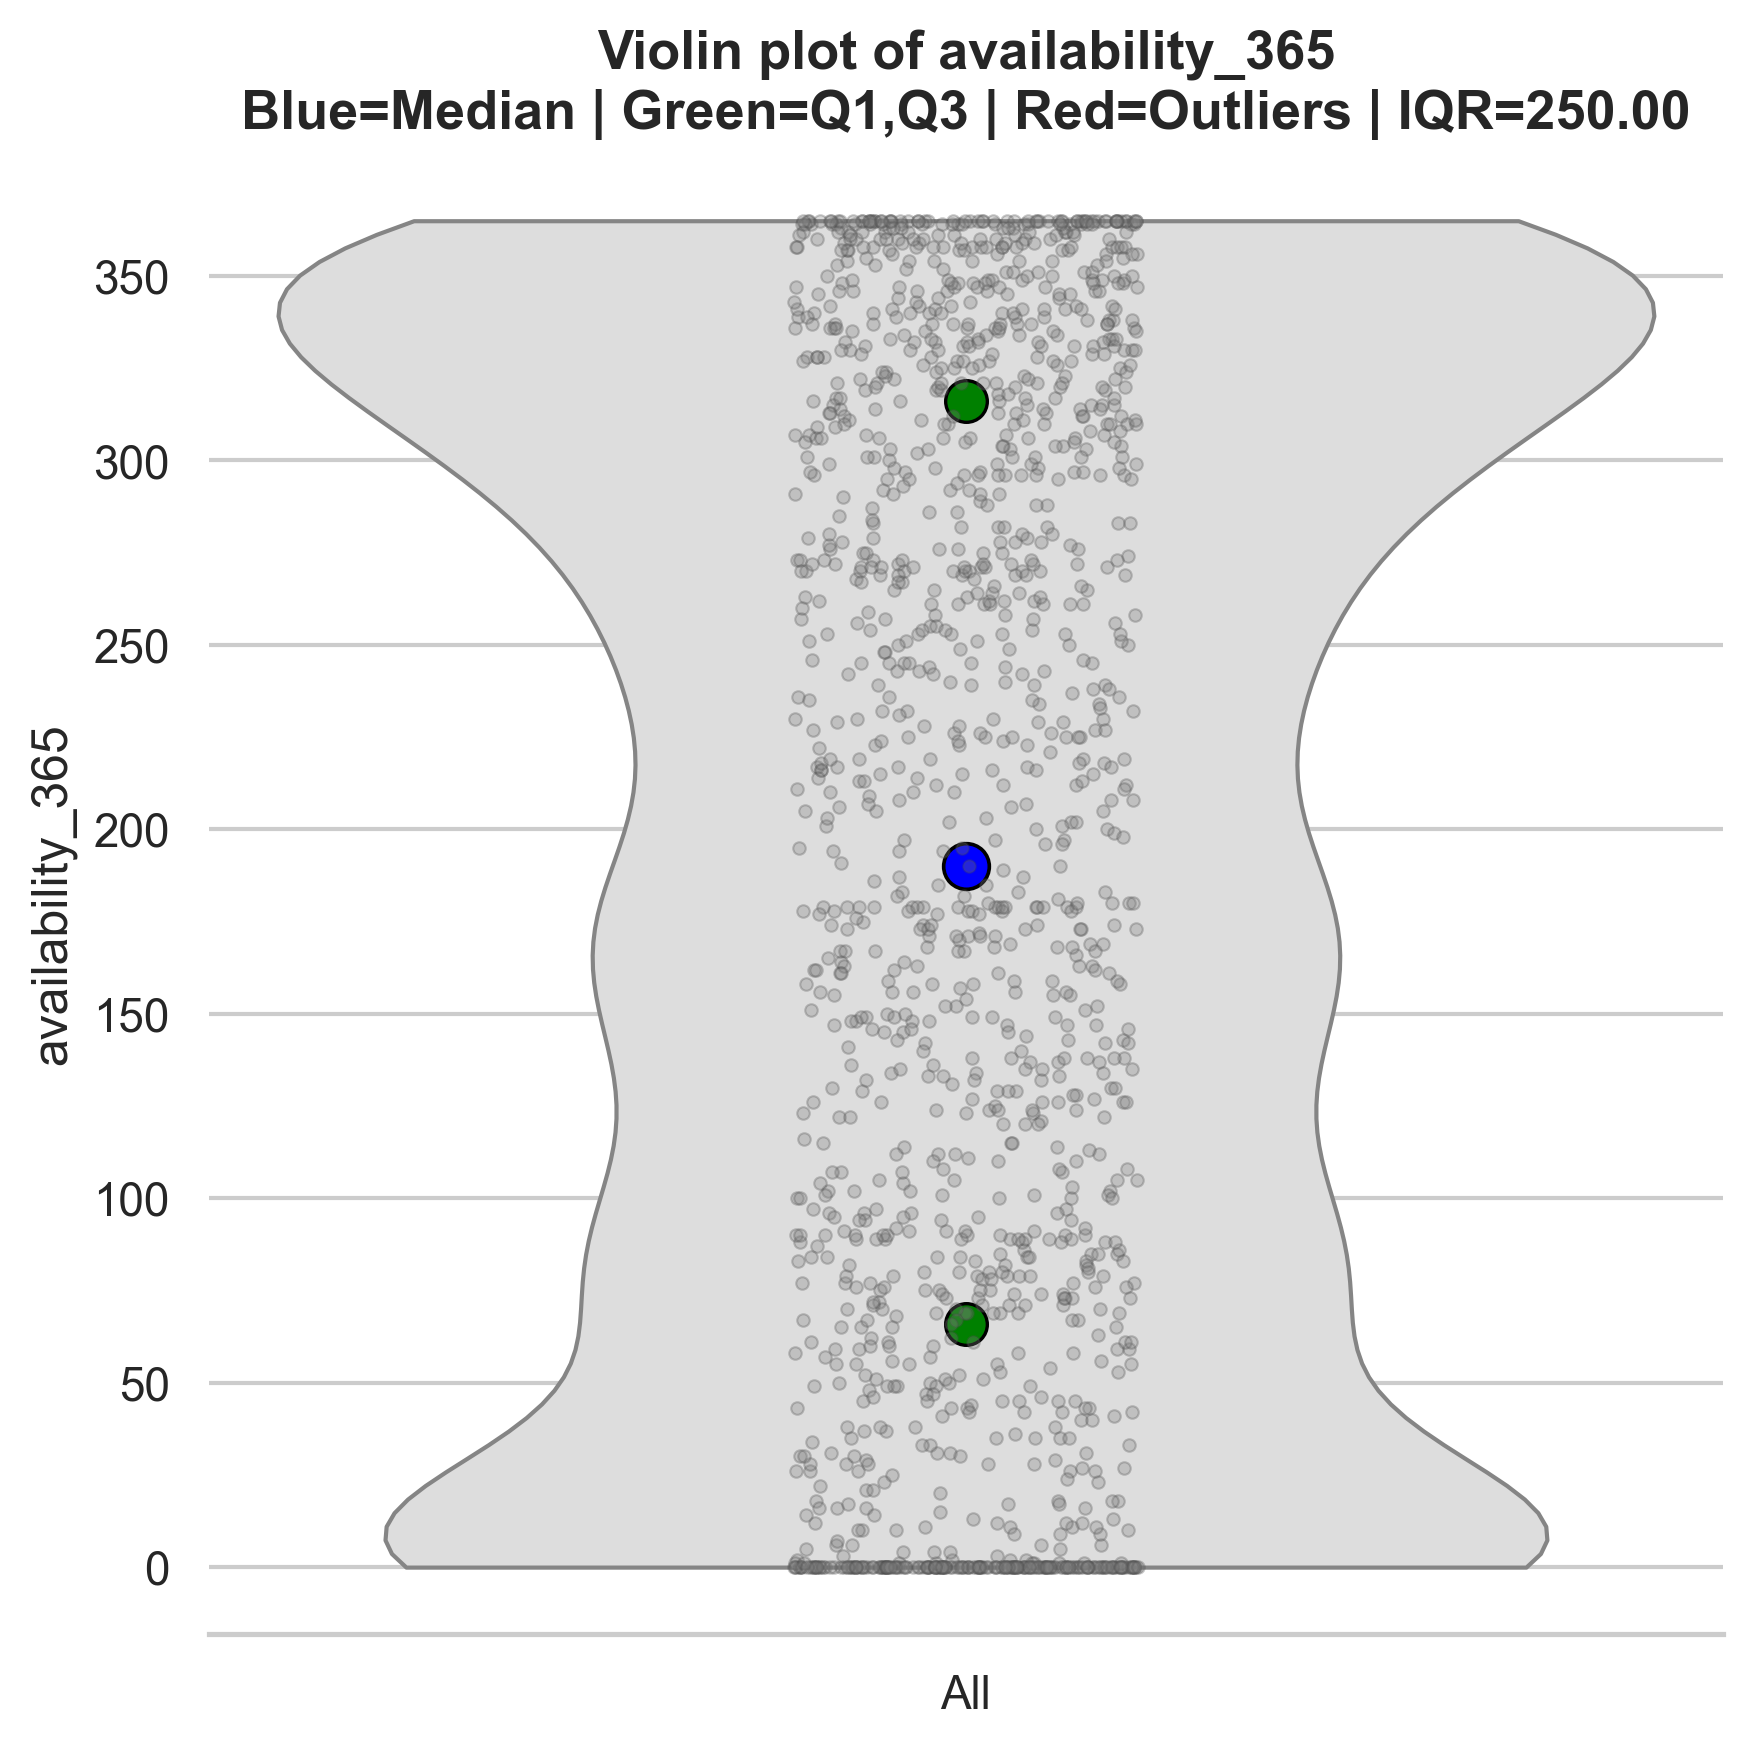

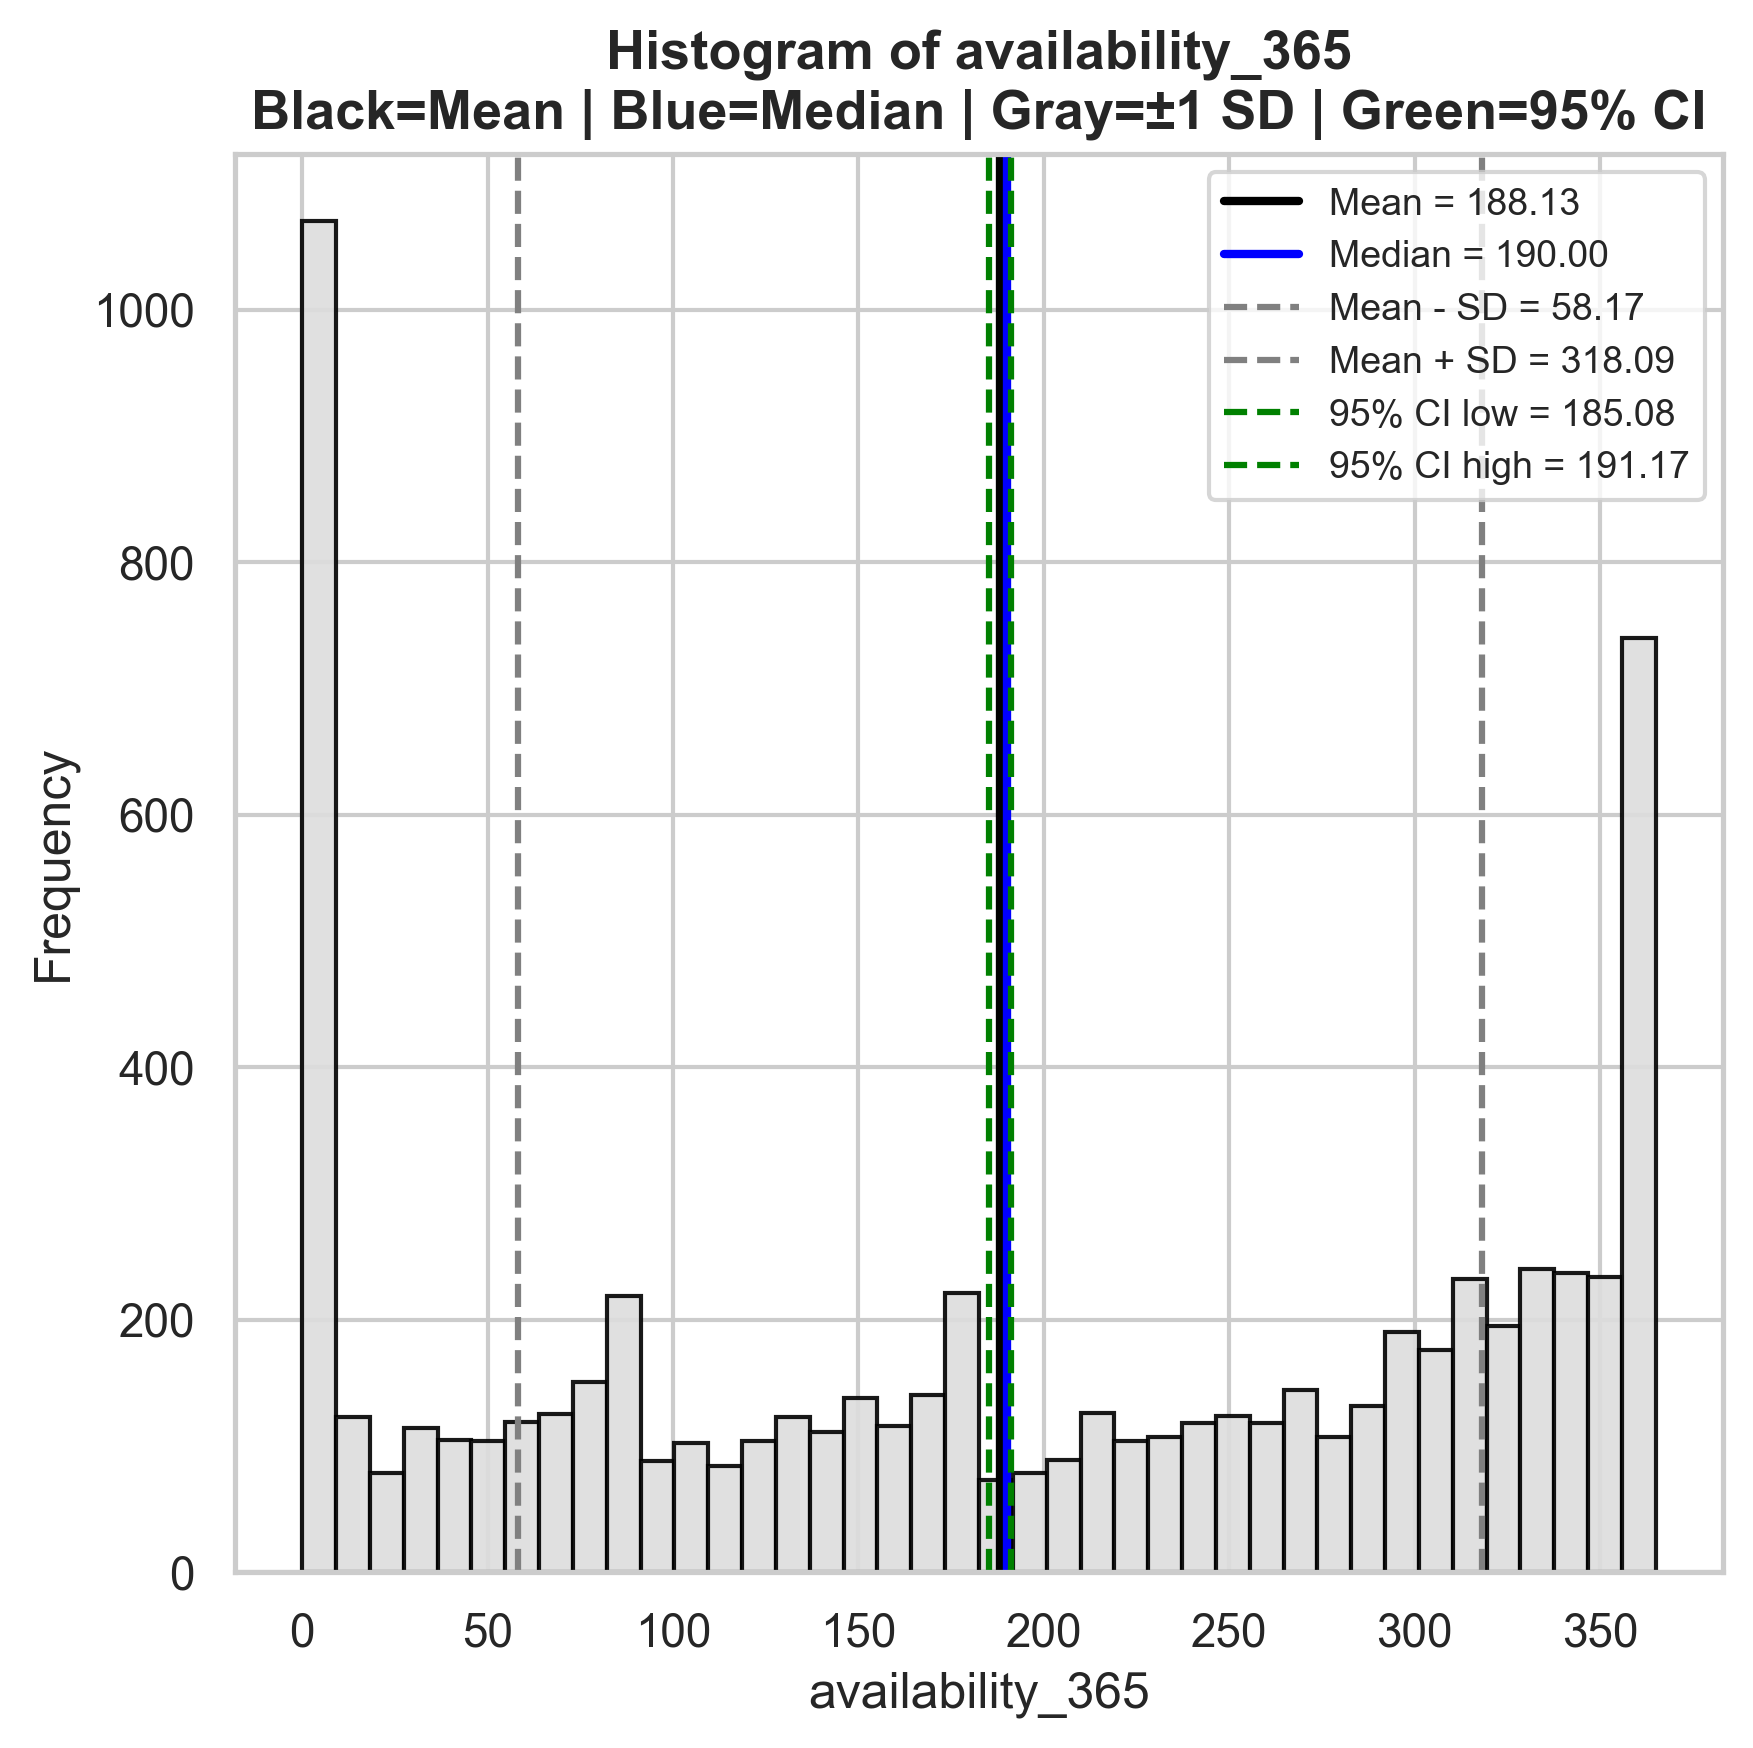

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,availability_365,7001,188.12941,190.0,129.95633,185.084738,191.174083,66.0,316.0,250.0,-309.0,691.0,0,-0.117509,Approximately symmetric.



Unique values table
Number of non-nulls: 7001
Number of unique values: 366


,column,value,count,frequency_non_null
0,availability_365,0,901,0.128696
1,availability_365,1,53,0.007570
2,availability_365,2,17,0.002428
3,availability_365,3,20,0.002857
4,availability_365,4,7,0.001000
...,...,...,...,...
361,availability_365,361,35,0.004999
362,availability_365,362,51,0.007285
363,availability_365,363,48,0.006856
364,availability_365,364,127,0.018140



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,availability_365,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,availability_365,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,availability_365,numeric,city,categorical,Chi-square,267.474886,6.450689e-41,Significant,Statistically significant at p < 0.05.,
3,availability_365,numeric,room_type,categorical,Chi-square,365.786319,6.520585e-71,Significant,Statistically significant at p < 0.05.,
4,availability_365,numeric,accommodates,numeric,Pearson,0.128953,2.399383e-27,Significant,Statistically significant at p < 0.05.,
5,availability_365,numeric,bathrooms,categorical,Chi-square,114.932668,2.046802e-07,Significant,Statistically significant at p < 0.05.,
6,availability_365,numeric,bedrooms,categorical,Chi-square,265.836258,1.832014e-30,Significant,Statistically significant at p < 0.05.,
7,availability_365,numeric,beds,numeric,Pearson,0.120791,3.671153e-24,Significant,Statistically significant at p < 0.05.,
8,availability_365,numeric,price,numeric,Pearson,0.133918,7.315995e-29,Significant,Statistically significant at p < 0.05.,
9,availability_365,numeric,minimum_nights,numeric,Pearson,0.029656,1.308501e-02,Significant,Statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-0.117509,Approximately symmetric.,Baseline.
1,Log Transformation,-1.521129,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-0.735619,Moderately skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.591616,Moderately skewed.,Did not improve normality; skewness increased....


In [89]:
analysis = analyze_single_field(df, 
                                target_col="availability_365", 
                                results_dir=RESULTS_DIR, 
                                show_in_notebook=True)

<Axes: xlabel='room_type', ylabel='city'>

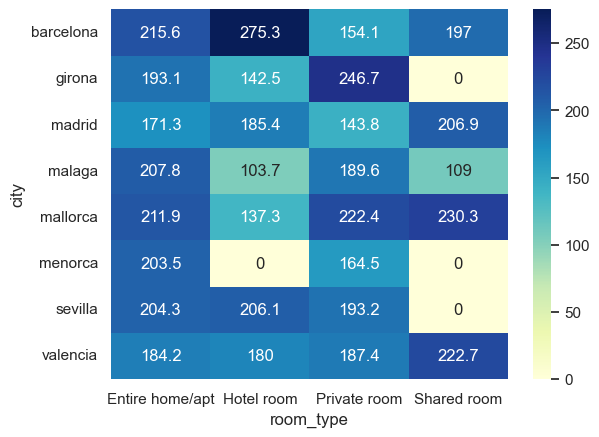

In [90]:
sns.heatmap(df.groupby(['city', 'room_type'])['availability_365'].mean().round(1).unstack(fill_value=0), annot=True, cmap='YlGnBu', fmt='g')

###### Number of reviews

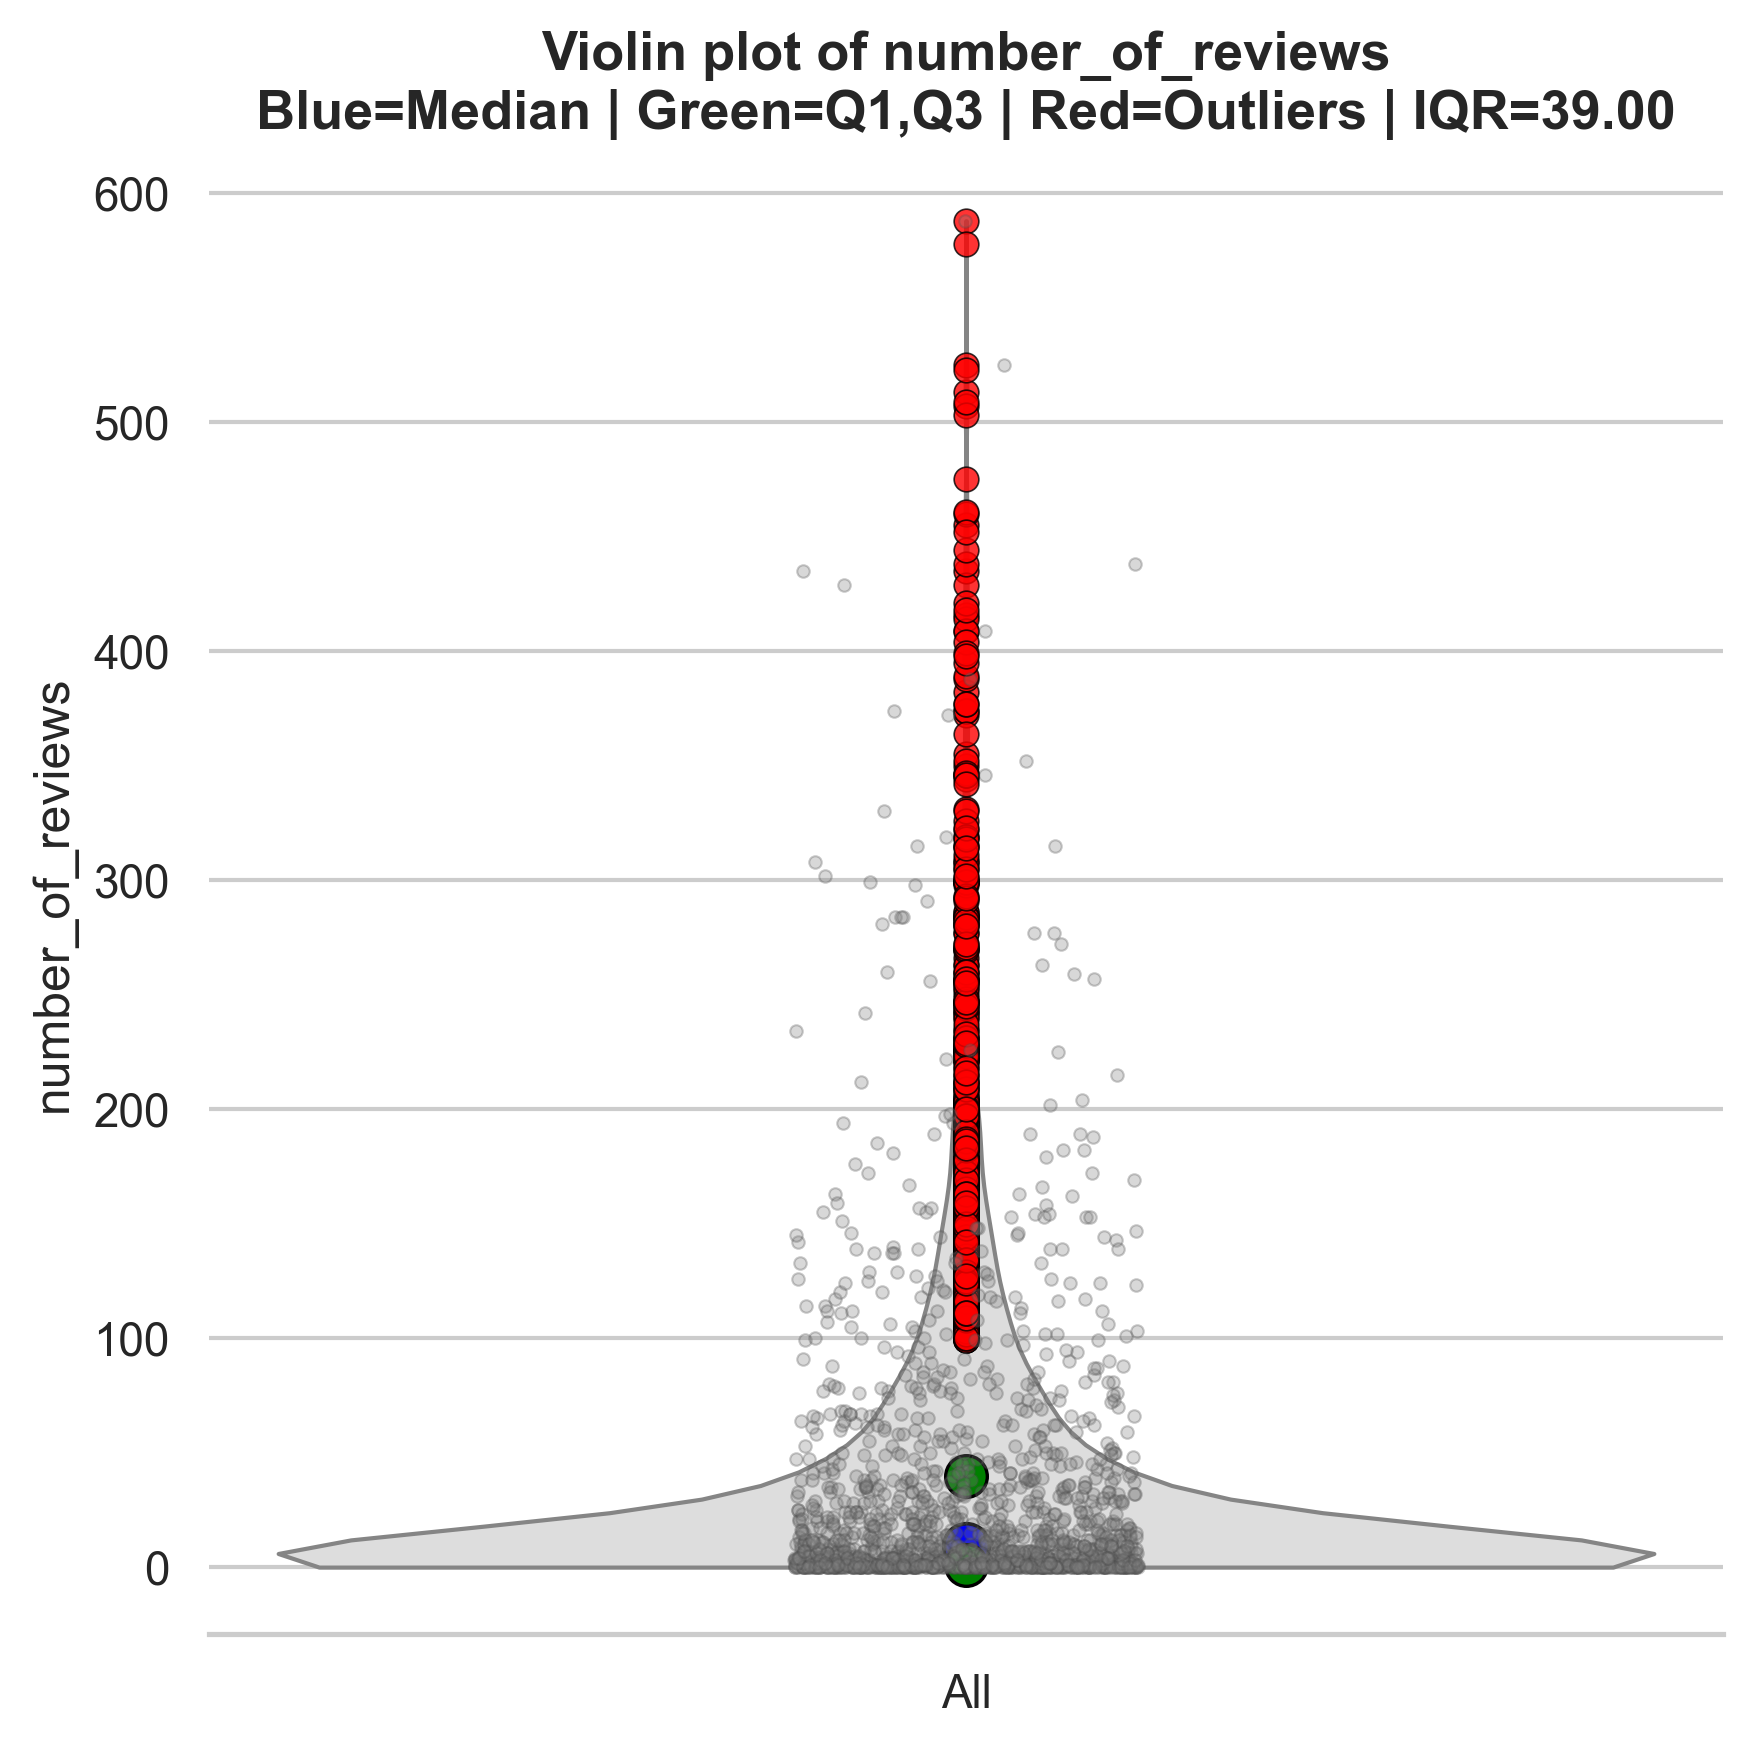

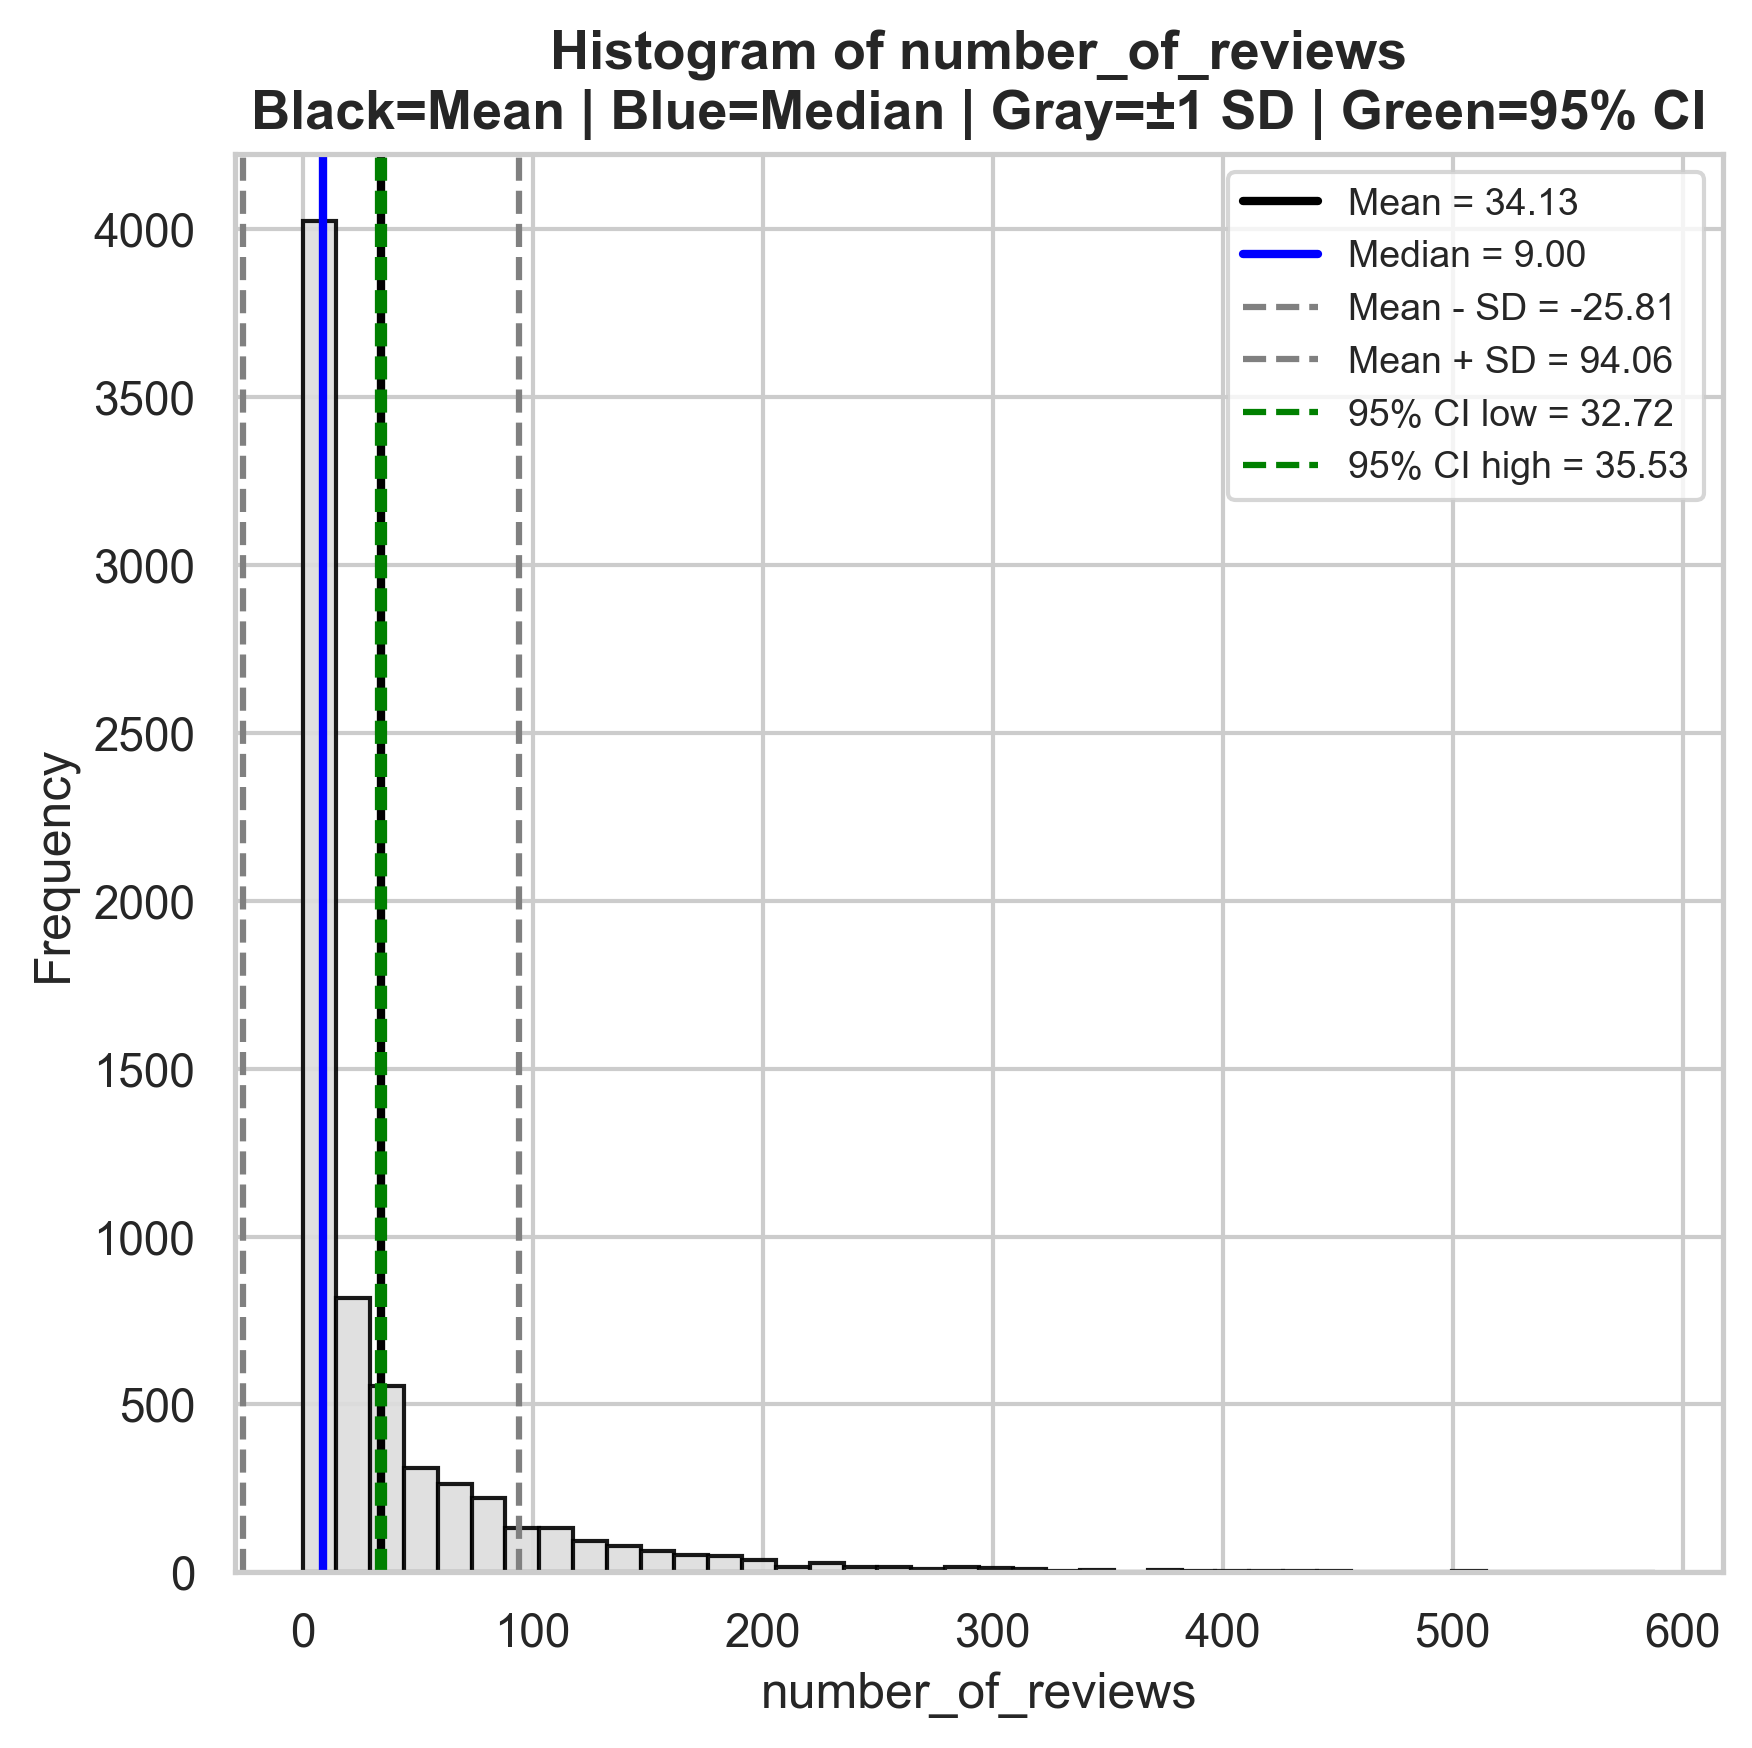

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,number_of_reviews,7001,34.125411,9.0,59.935608,32.721214,35.529608,1.0,40.0,39.0,-57.5,98.5,717,3.375898,Highly skewed.



Unique values table
Number of non-nulls: 7001
Number of unique values: 319


,column,value,count,frequency_non_null
0,number_of_reviews,0,1251,0.178689
1,number_of_reviews,1,590,0.084274
2,number_of_reviews,2,386,0.055135
3,number_of_reviews,3,306,0.043708
4,number_of_reviews,4,243,0.034709
...,...,...,...,...
314,number_of_reviews,513,1,0.000143
315,number_of_reviews,523,1,0.000143
316,number_of_reviews,525,1,0.000143
317,number_of_reviews,578,1,0.000143



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,number_of_reviews,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,number_of_reviews,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,number_of_reviews,numeric,city,categorical,Chi-square,835.315181,8.011172e-158,Significant,Statistically significant at p < 0.05.,
3,number_of_reviews,numeric,room_type,categorical,Chi-square,34.722689,5.183646e-04,Significant,Statistically significant at p < 0.05.,
4,number_of_reviews,numeric,accommodates,numeric,Pearson,-0.123218,4.295653e-25,Significant,Statistically significant at p < 0.05.,
5,number_of_reviews,numeric,bathrooms,categorical,Chi-square,291.827137,1.164383e-36,Significant,Statistically significant at p < 0.05.,
6,number_of_reviews,numeric,bedrooms,categorical,Chi-square,318.130189,6.939042e-40,Significant,Statistically significant at p < 0.05.,
7,number_of_reviews,numeric,beds,numeric,Pearson,-0.147364,2.847740e-35,Significant,Statistically significant at p < 0.05.,
8,number_of_reviews,numeric,price,numeric,Pearson,-0.160011,1.245178e-40,Significant,Statistically significant at p < 0.05.,
9,number_of_reviews,numeric,minimum_nights,numeric,Pearson,-0.079822,2.257675e-11,Significant,Statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,3.375898,Highly skewed.,Baseline.
1,Log Transformation,0.125715,Approximately symmetric.,Improved strongly; distribution is closer to s...
2,Square Root Transformation,1.289804,Highly skewed.,Improved; skewness decreased.
3,Box-Cox Transformation,0.029436,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [47]:
analysis = analyze_single_field(df, 
                                target_col="number_of_reviews", 
                                results_dir=RESULTS_DIR, 
                                show_in_notebook=True)

###### Reviews score rating

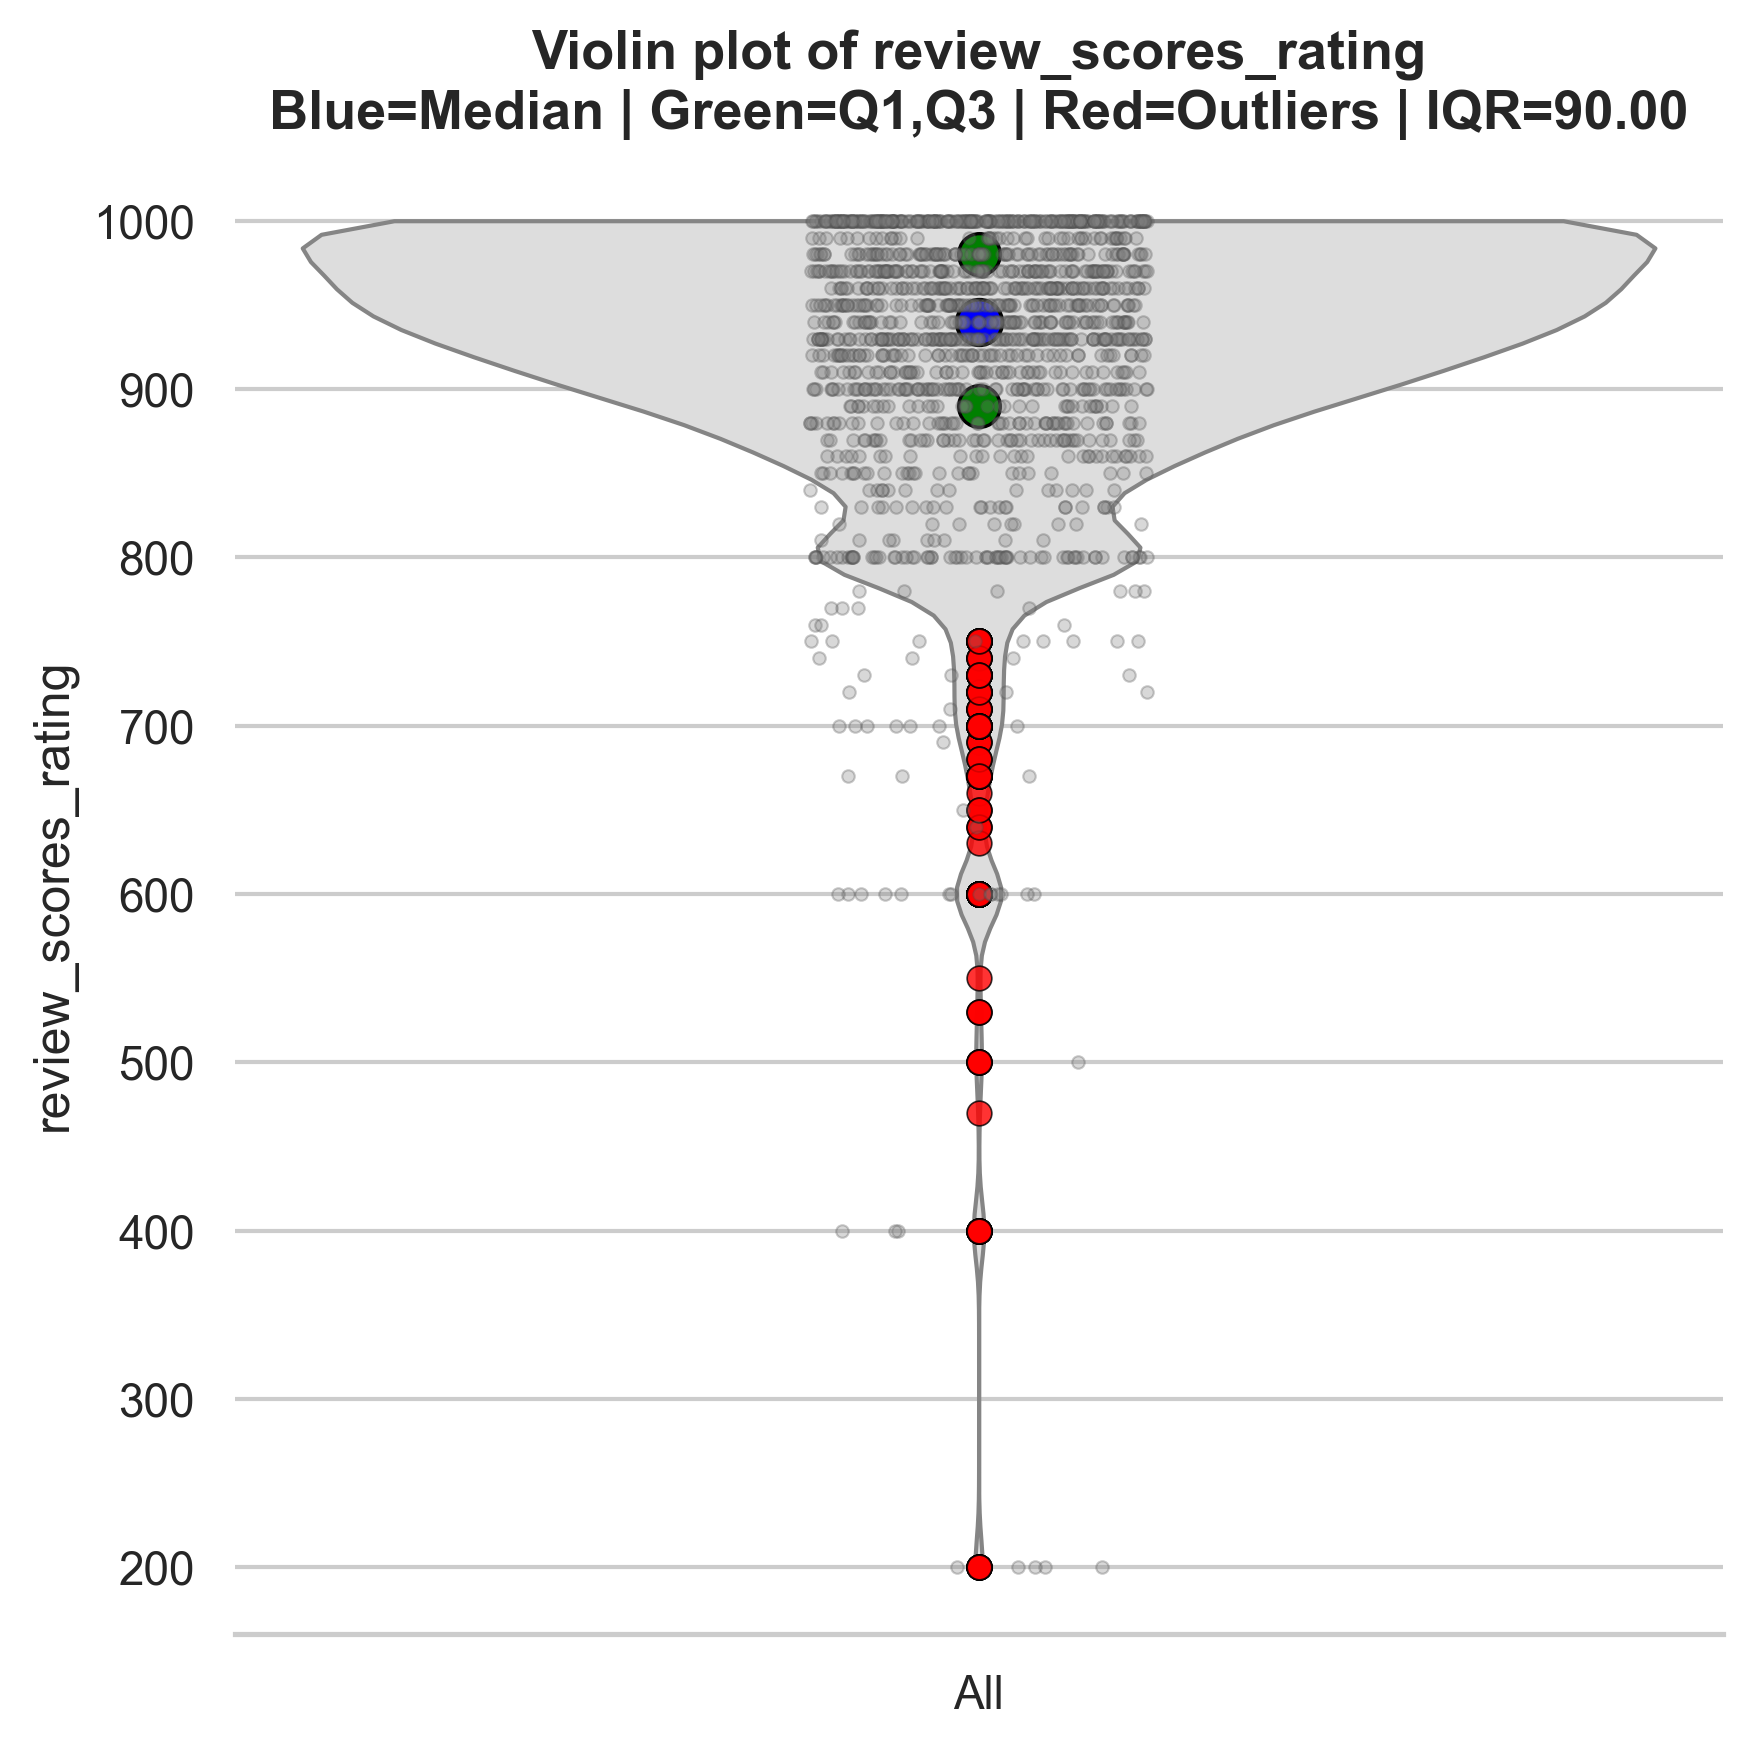

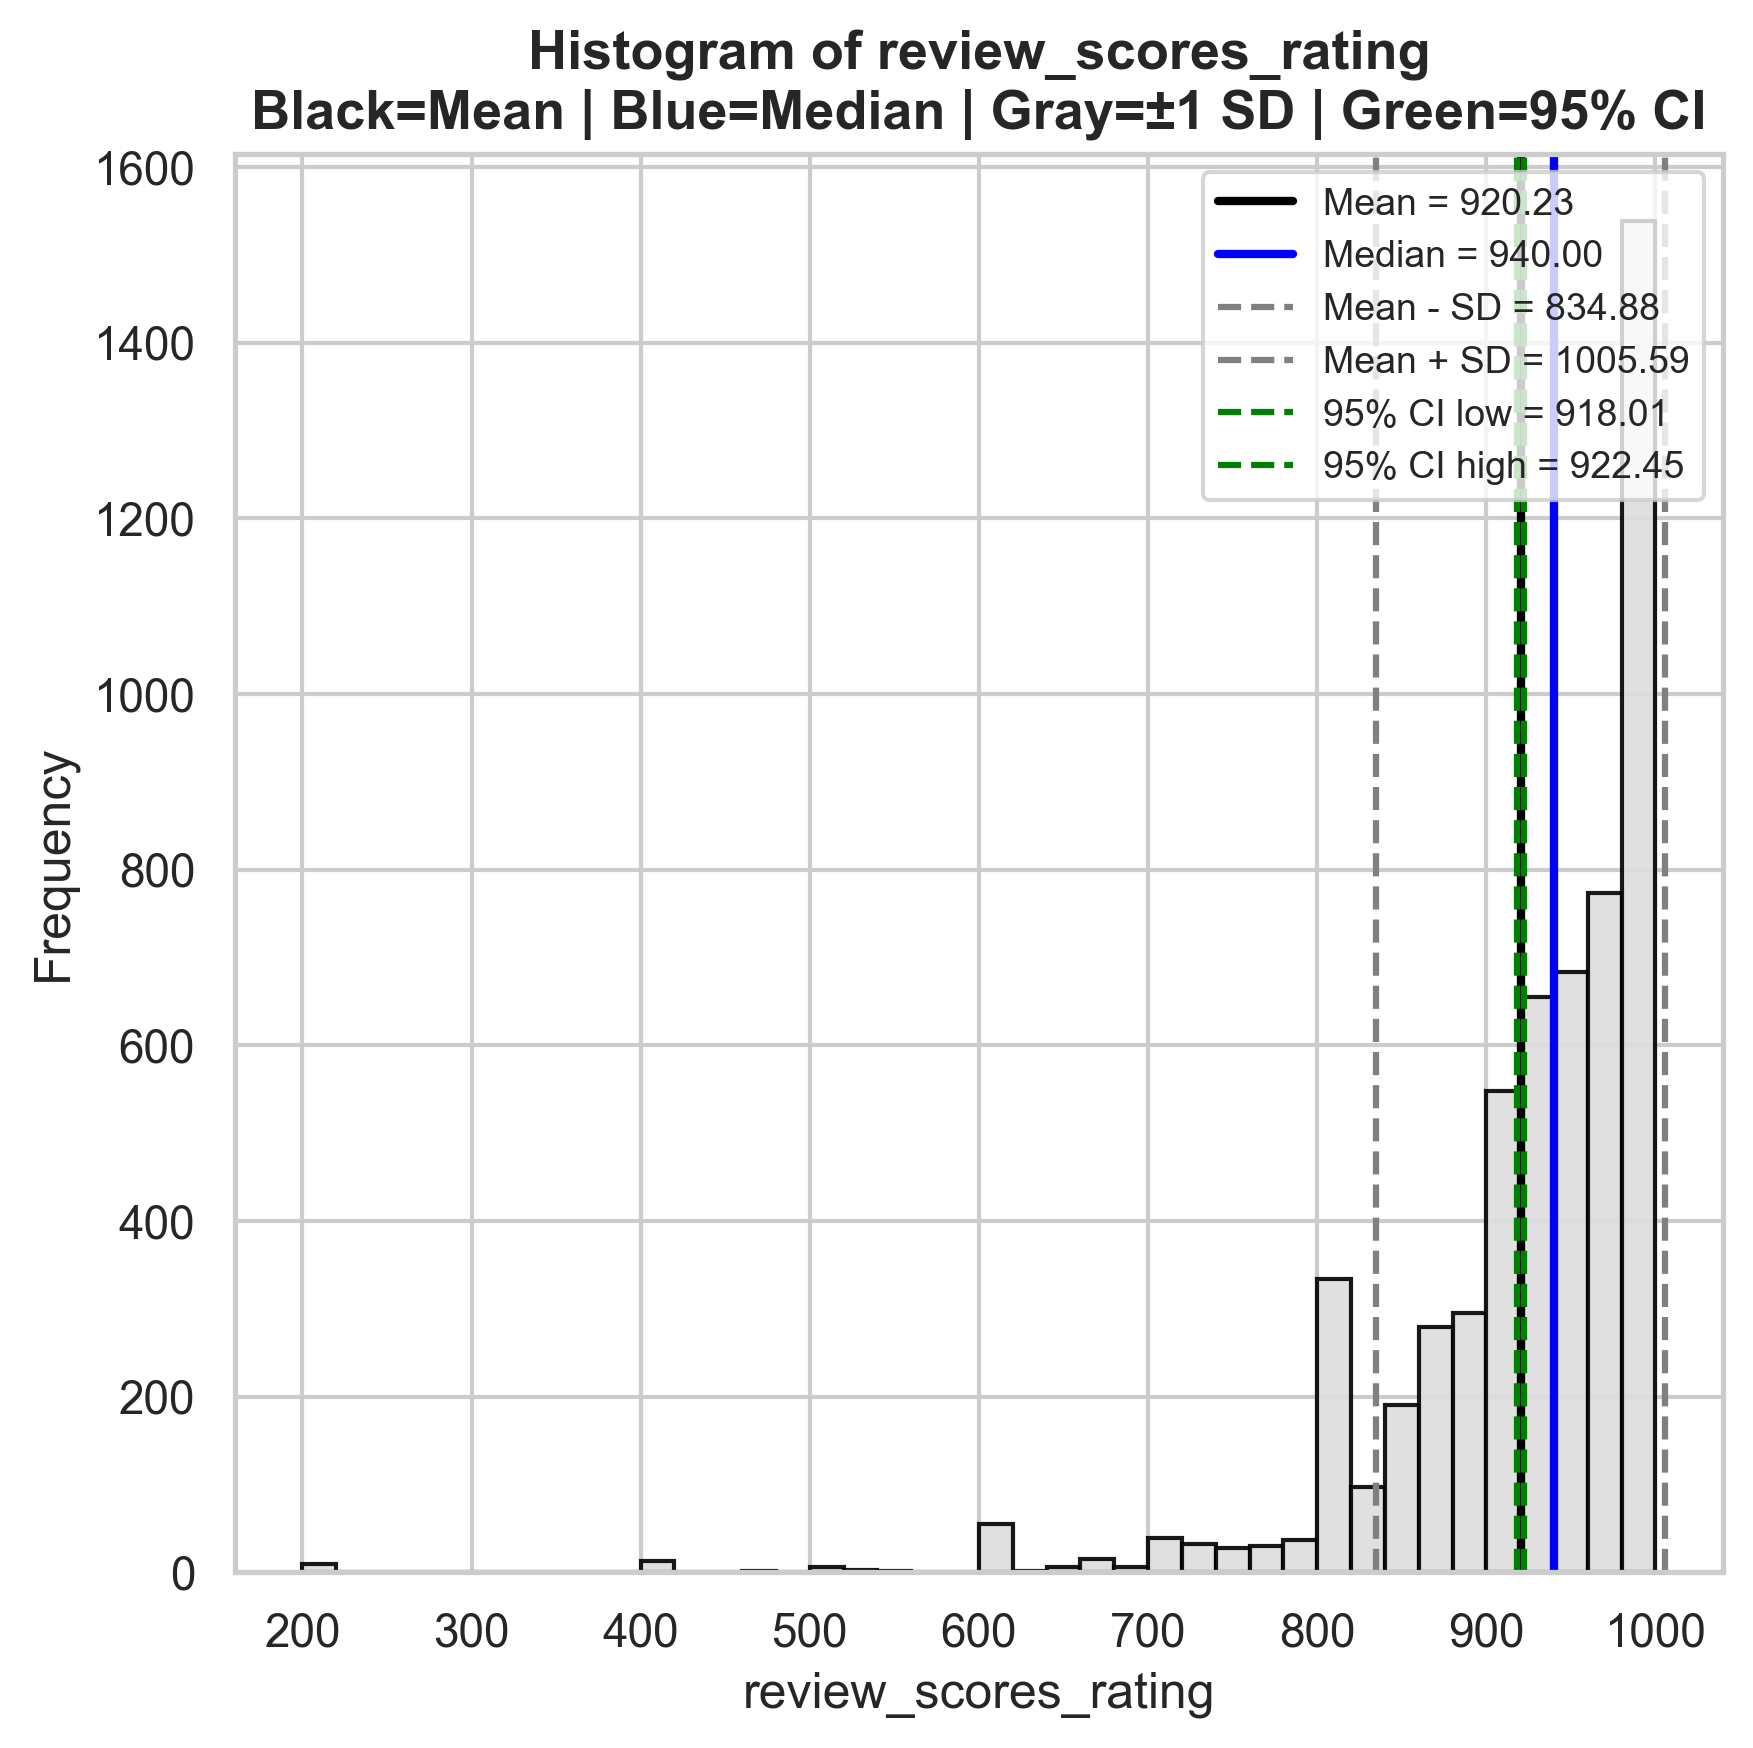

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,review_scores_rating,5674,920.23264,940.0,85.353954,918.011276,922.454004,890.0,980.0,90.0,755.0,1115.0,215,-2.633073,Highly skewed.



Unique values table
Number of non-nulls: 5674
Number of unique values: 45


,column,value,count,frequency_non_null
0,review_scores_rating,200.0,9,0.001586
1,review_scores_rating,400.0,13,0.002291
2,review_scores_rating,470.0,1,0.000176
3,review_scores_rating,500.0,6,0.001057
4,review_scores_rating,530.0,3,0.000529
5,review_scores_rating,550.0,1,0.000176
6,review_scores_rating,600.0,55,0.009693
7,review_scores_rating,630.0,1,0.000176
8,review_scores_rating,640.0,3,0.000529
9,review_scores_rating,650.0,3,0.000529



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,review_scores_rating,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,review_scores_rating,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,review_scores_rating,numeric,city,categorical,Chi-square,319.505312,3.217004e-51,Significant,Statistically significant at p < 0.05.,
3,review_scores_rating,numeric,room_type,categorical,Chi-square,14.636011,2.619479e-01,Not significant,Not statistically significant at p < 0.05.,
4,review_scores_rating,numeric,accommodates,numeric,Pearson,-0.009824,4.593644e-01,Not significant,Not statistically significant at p < 0.05.,
5,review_scores_rating,numeric,bathrooms,categorical,Chi-square,164.794537,4.410037e-17,Significant,Statistically significant at p < 0.05.,
6,review_scores_rating,numeric,bedrooms,categorical,Chi-square,166.465658,3.929217e-16,Significant,Statistically significant at p < 0.05.,
7,review_scores_rating,numeric,beds,numeric,Pearson,-0.005566,6.750970e-01,Not significant,Not statistically significant at p < 0.05.,
8,review_scores_rating,numeric,price,numeric,Pearson,0.040167,2.662481e-03,Significant,Statistically significant at p < 0.05.,
9,review_scores_rating,numeric,minimum_nights,numeric,Pearson,-0.004674,7.248569e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-2.633073,Highly skewed.,Baseline.
1,Log Transformation,-5.385346,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-3.632793,Highly skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.305264,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [48]:
analysis = analyze_single_field(df, 
                                target_col="review_scores_rating", 
                                results_dir=RESULTS_DIR, 
                                show_in_notebook=True)

###### ACCURACY

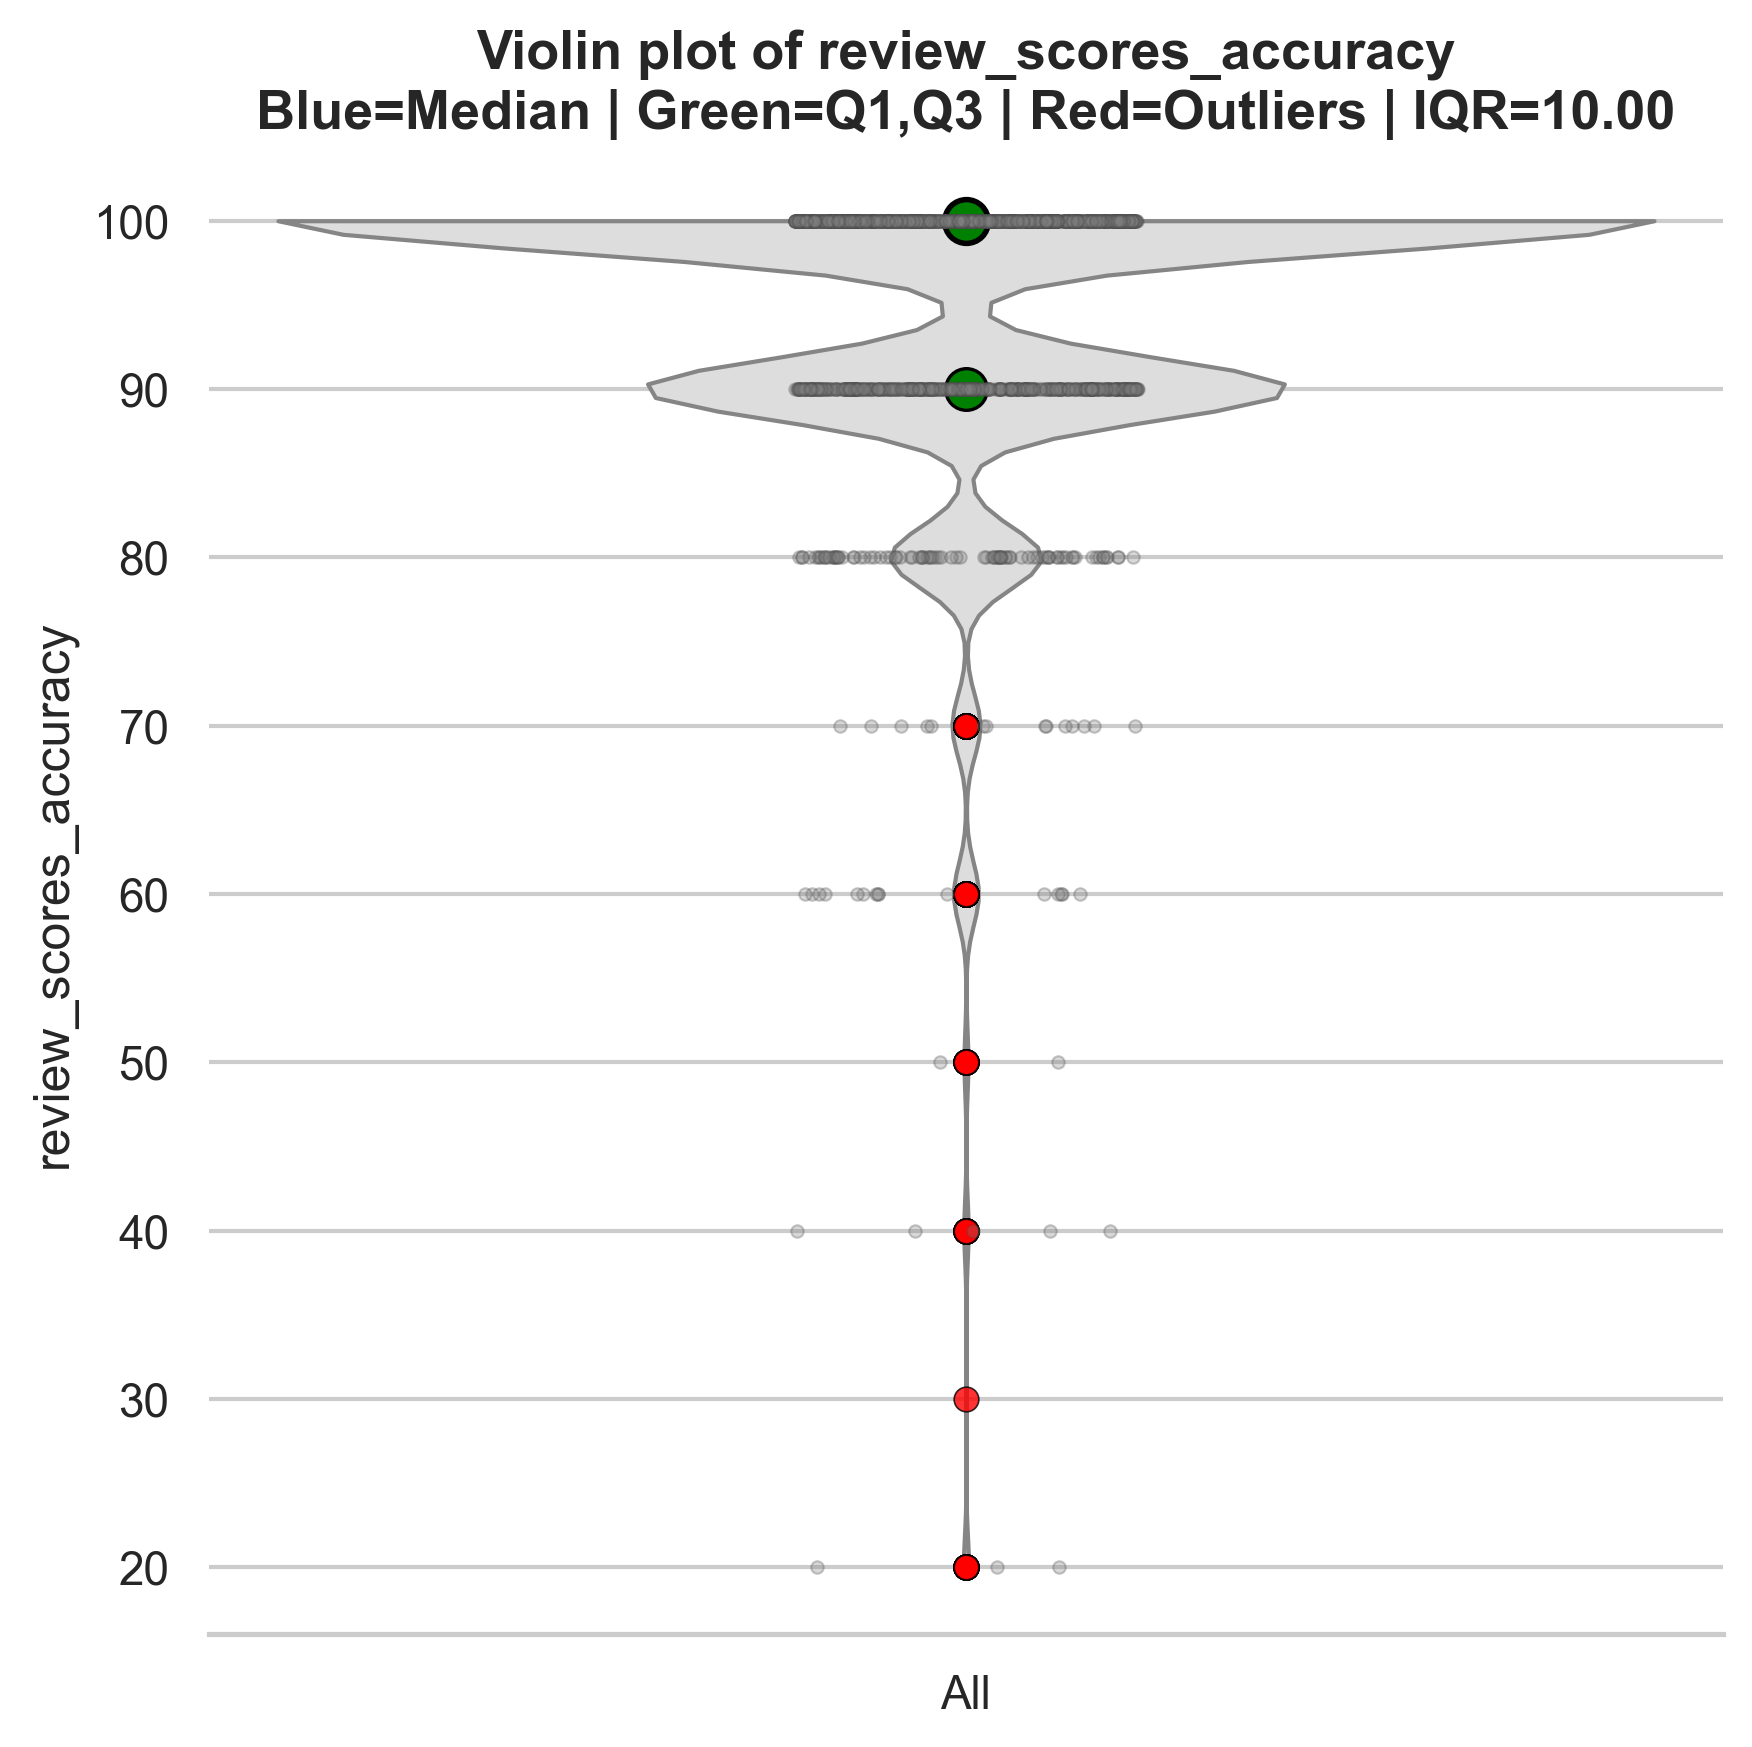

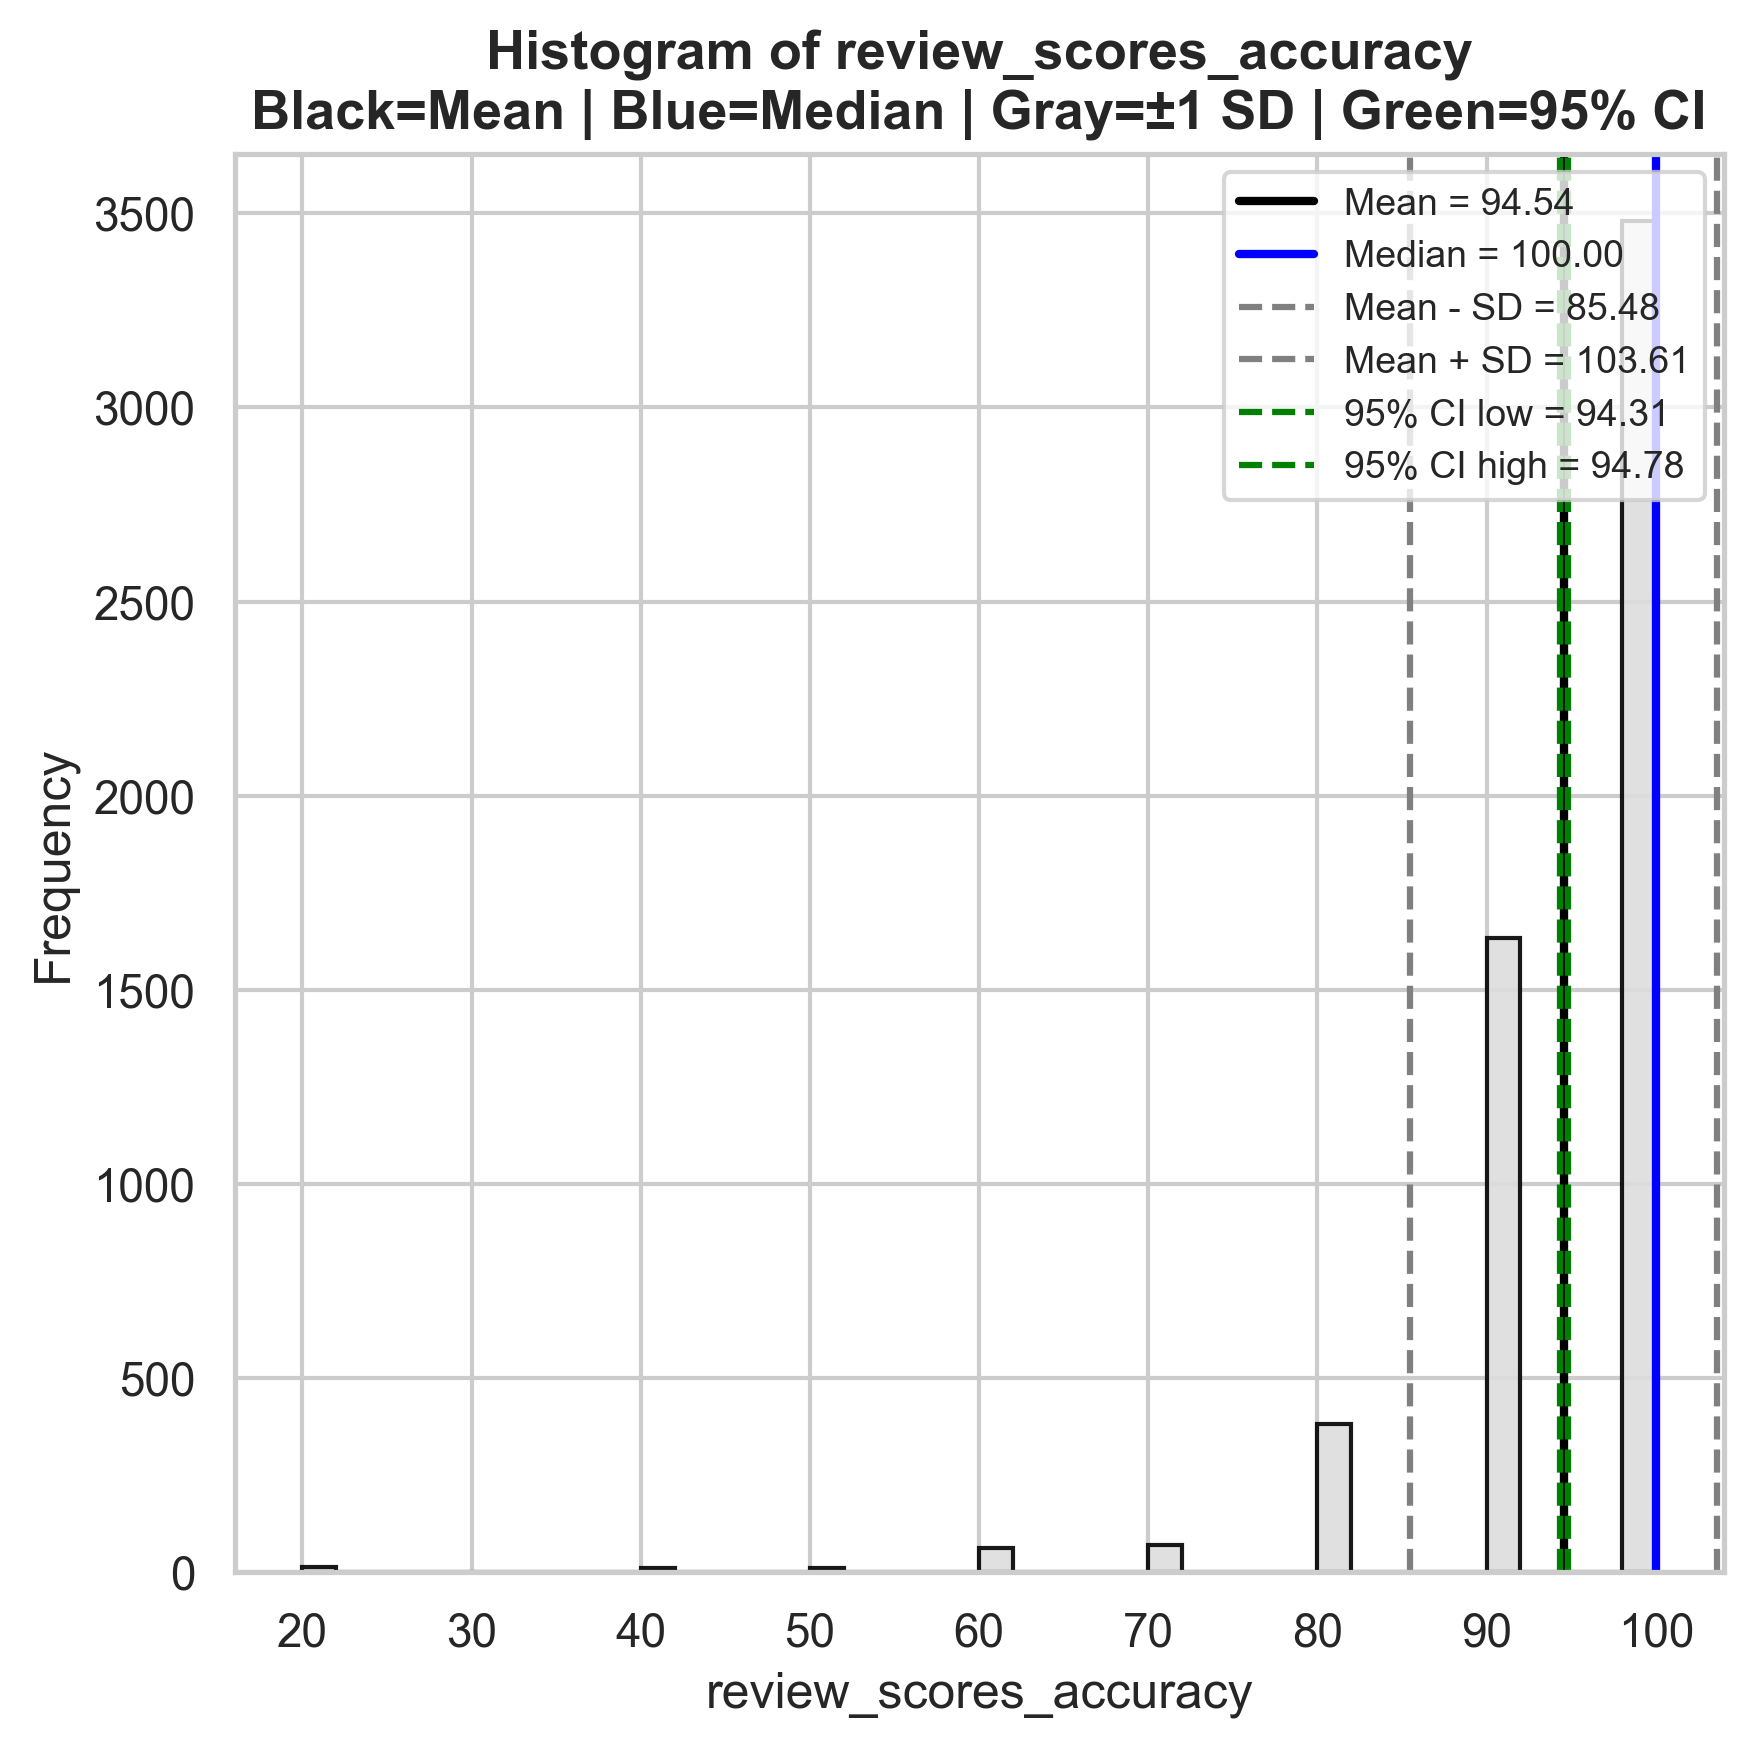

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,review_scores_accuracy,5665,94.543689,100.0,9.063156,94.30763,94.779748,90.0,100.0,10.0,75.0,115.0,169,-3.021325,Highly skewed.



Unique values table
Number of non-nulls: 5665
Number of unique values: 9


,column,value,count,frequency_non_null
0,review_scores_accuracy,20.0,13,0.002295
1,review_scores_accuracy,30.0,1,0.000177
2,review_scores_accuracy,40.0,11,0.001942
3,review_scores_accuracy,50.0,10,0.001765
4,review_scores_accuracy,60.0,63,0.011121
5,review_scores_accuracy,70.0,71,0.012533
6,review_scores_accuracy,80.0,383,0.067608
7,review_scores_accuracy,90.0,1633,0.288261
8,review_scores_accuracy,100.0,3480,0.614298



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,review_scores_accuracy,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,review_scores_accuracy,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,review_scores_accuracy,numeric,city,categorical,Chi-square,110.840558,6.145365e-21,Significant,Statistically significant at p < 0.05.,
3,review_scores_accuracy,numeric,room_type,categorical,Chi-square,8.841159,3.147903e-02,Significant,Statistically significant at p < 0.05.,
4,review_scores_accuracy,numeric,accommodates,numeric,Pearson,-0.054670,3.839410e-05,Significant,Statistically significant at p < 0.05.,
5,review_scores_accuracy,numeric,bathrooms,categorical,Chi-square,26.725577,2.877643e-03,Significant,Statistically significant at p < 0.05.,
6,review_scores_accuracy,numeric,bedrooms,categorical,Chi-square,13.853314,2.412168e-01,Not significant,Not statistically significant at p < 0.05.,
7,review_scores_accuracy,numeric,beds,numeric,Pearson,-0.052625,7.408927e-05,Significant,Statistically significant at p < 0.05.,
8,review_scores_accuracy,numeric,price,numeric,Pearson,-0.018785,1.604930e-01,Not significant,Not statistically significant at p < 0.05.,
9,review_scores_accuracy,numeric,minimum_nights,numeric,Pearson,-0.015435,2.454095e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-3.021325,Highly skewed.,Baseline.
1,Log Transformation,-5.965903,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-4.118839,Highly skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.636572,Moderately skewed.,Improved; skewness decreased. Improved using l...


In [49]:
analysis = analyze_single_field(df, 
                                target_col="review_scores_accuracy", 
                                results_dir=RESULTS_DIR, 
                                show_in_notebook=True)

###### CLEANLINESS

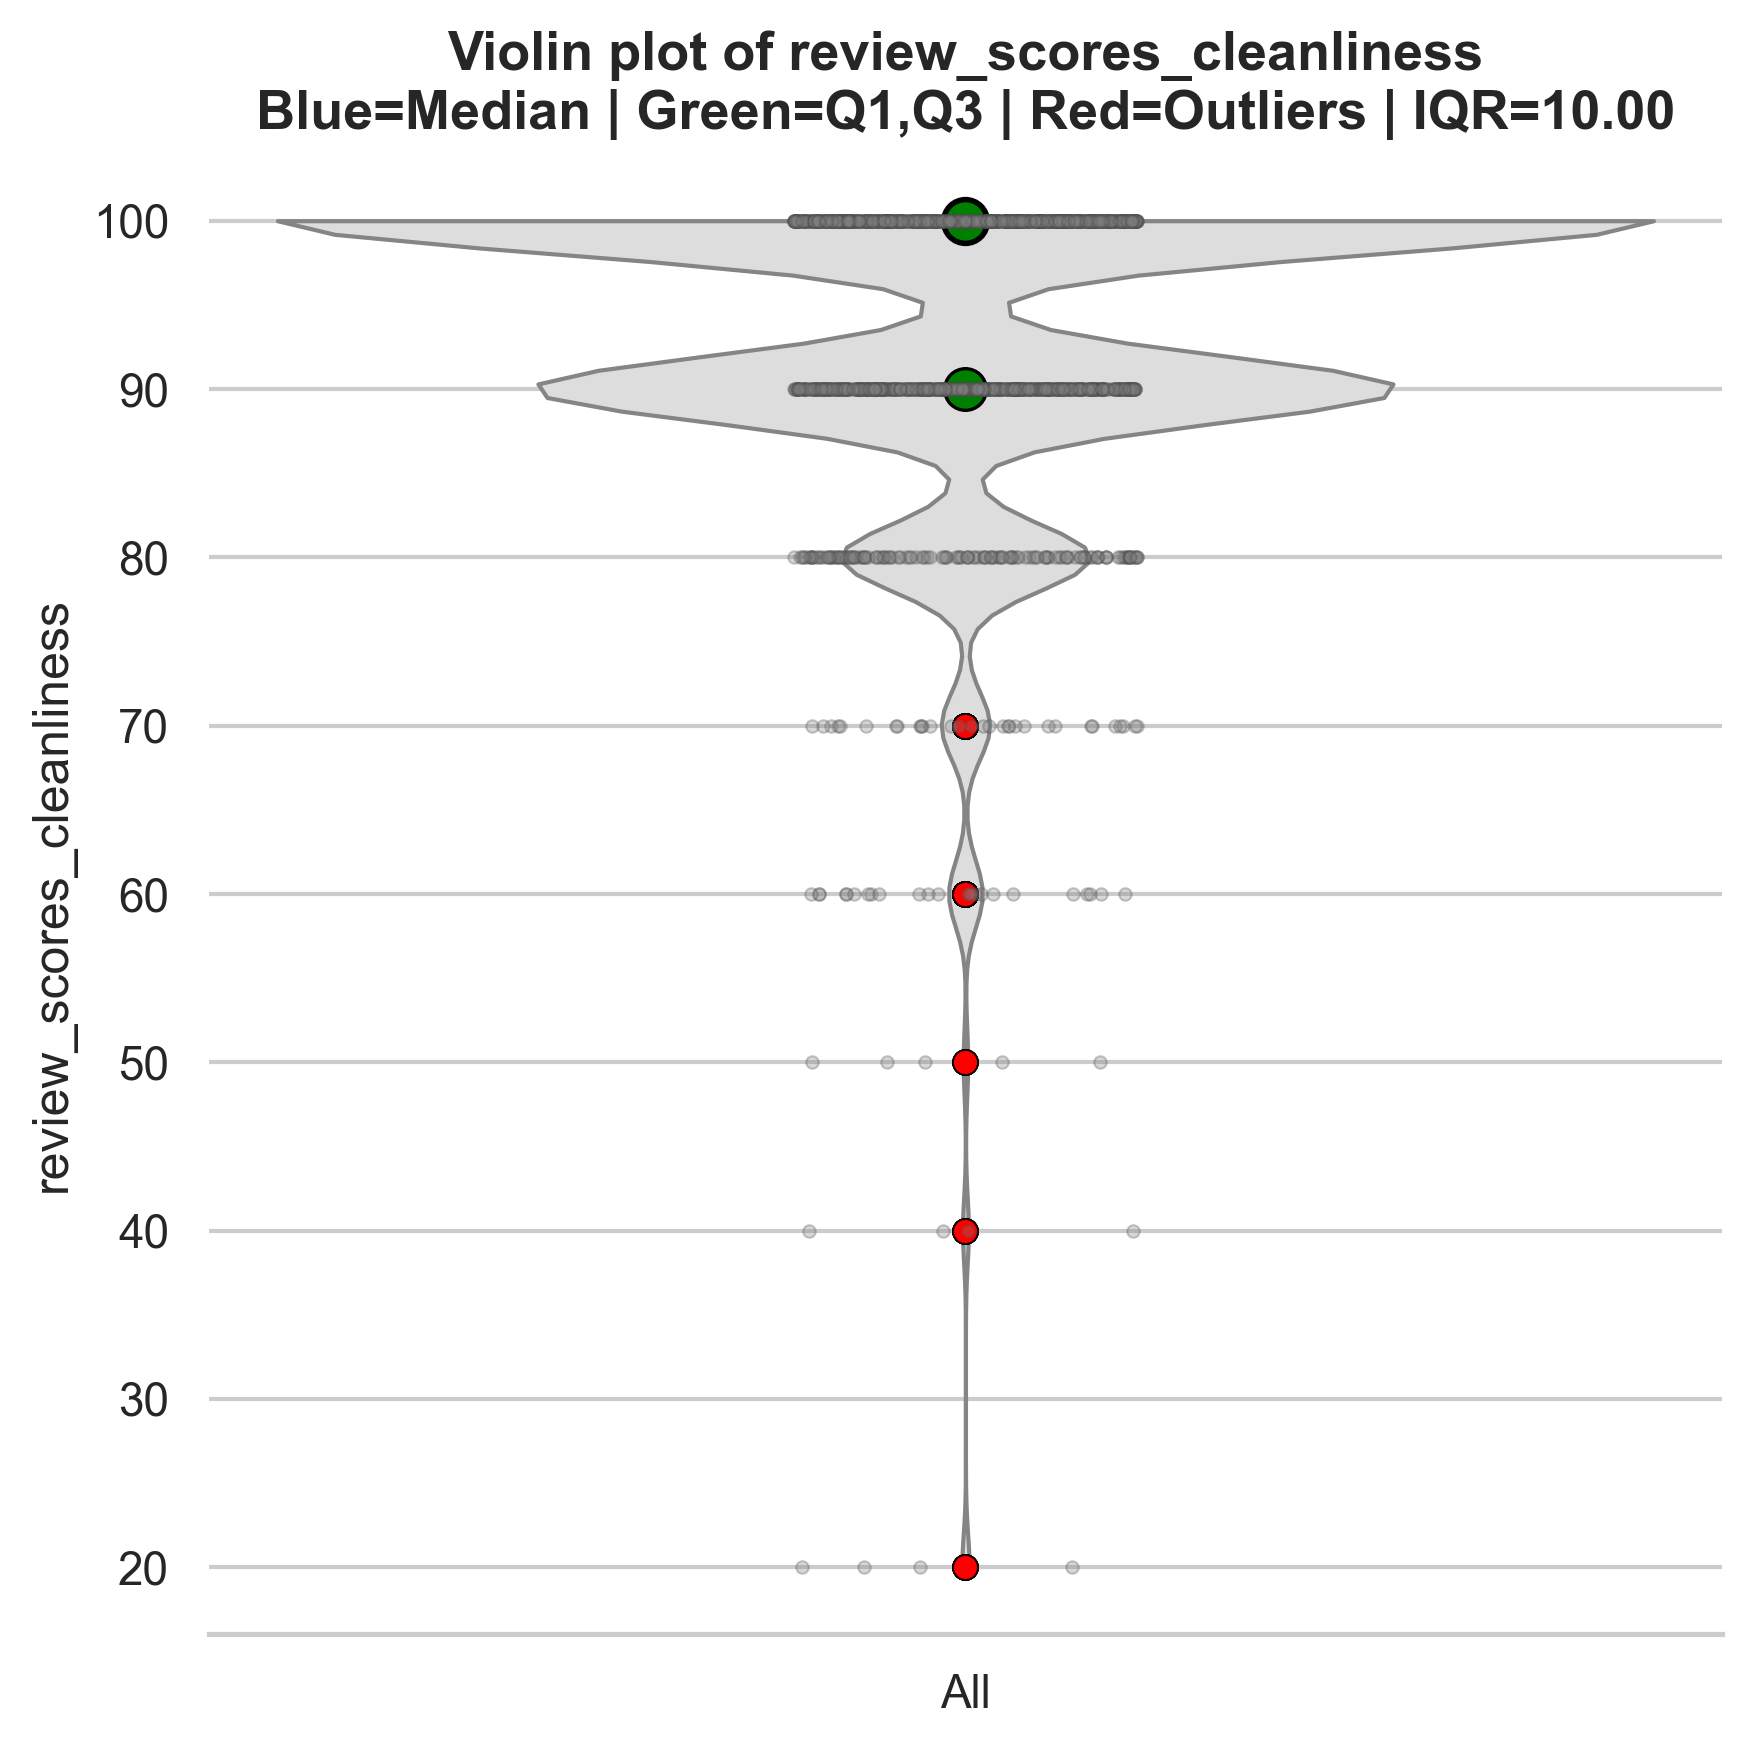

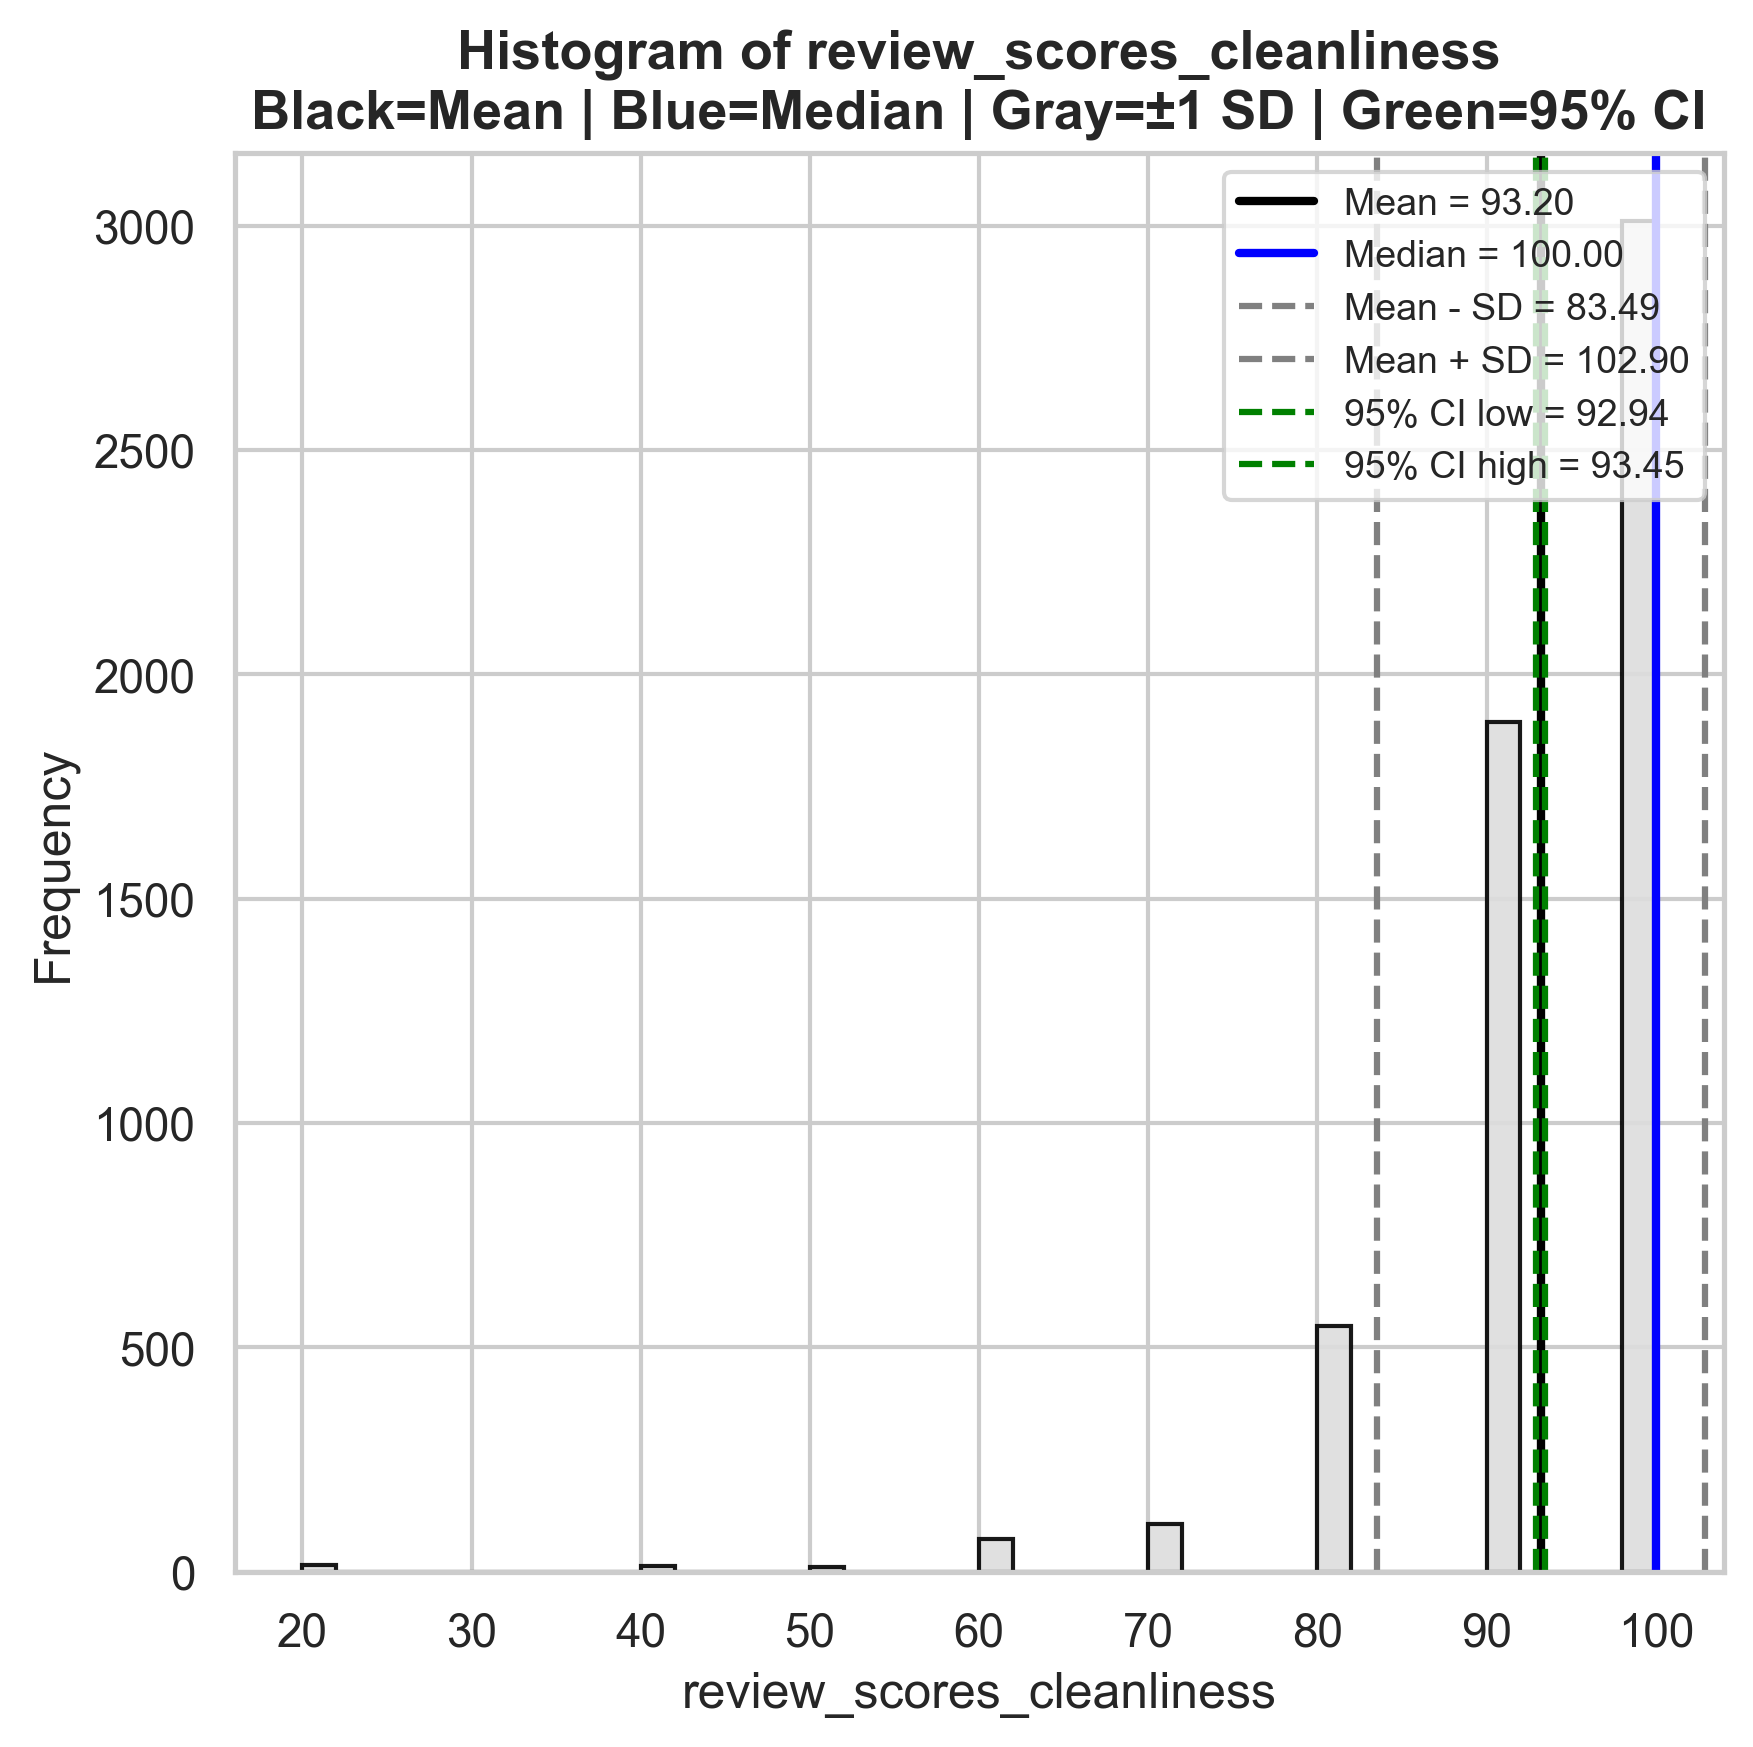

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,review_scores_cleanliness,5671,93.196967,100.0,9.702261,92.944396,93.449538,90.0,100.0,10.0,75.0,115.0,219,-2.596146,Highly skewed.



Unique values table
Number of non-nulls: 5671
Number of unique values: 8


,column,value,count,frequency_non_null
0,review_scores_cleanliness,20.0,16,0.002821
1,review_scores_cleanliness,40.0,13,0.002292
2,review_scores_cleanliness,50.0,10,0.001763
3,review_scores_cleanliness,60.0,74,0.013049
4,review_scores_cleanliness,70.0,106,0.018692
5,review_scores_cleanliness,80.0,547,0.096456
6,review_scores_cleanliness,90.0,1894,0.333980
7,review_scores_cleanliness,100.0,3011,0.530947



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,review_scores_cleanliness,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,review_scores_cleanliness,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,review_scores_cleanliness,numeric,city,categorical,Chi-square,90.818407,8.401334e-17,Significant,Statistically significant at p < 0.05.,
3,review_scores_cleanliness,numeric,room_type,categorical,Chi-square,4.619421,2.018823e-01,Not significant,Not statistically significant at p < 0.05.,
4,review_scores_cleanliness,numeric,accommodates,numeric,Pearson,-0.017235,1.943837e-01,Not significant,Not statistically significant at p < 0.05.,
5,review_scores_cleanliness,numeric,bathrooms,categorical,Chi-square,23.797769,8.155651e-03,Significant,Statistically significant at p < 0.05.,
6,review_scores_cleanliness,numeric,bedrooms,categorical,Chi-square,15.515777,1.600805e-01,Not significant,Not statistically significant at p < 0.05.,
7,review_scores_cleanliness,numeric,beds,numeric,Pearson,-0.022874,8.499721e-02,Not significant,Not statistically significant at p < 0.05.,
8,review_scores_cleanliness,numeric,price,numeric,Pearson,0.035849,7.355065e-03,Significant,Statistically significant at p < 0.05.,
9,review_scores_cleanliness,numeric,minimum_nights,numeric,Pearson,-0.005974,6.528440e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-2.596146,Highly skewed.,Baseline.
1,Log Transformation,-5.417499,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-3.643885,Highly skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.457851,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [50]:
analysis = analyze_single_field(df, 
                                target_col="review_scores_cleanliness", 
                                results_dir=RESULTS_DIR, 
                                show_in_notebook=True)

###### CHECKIN

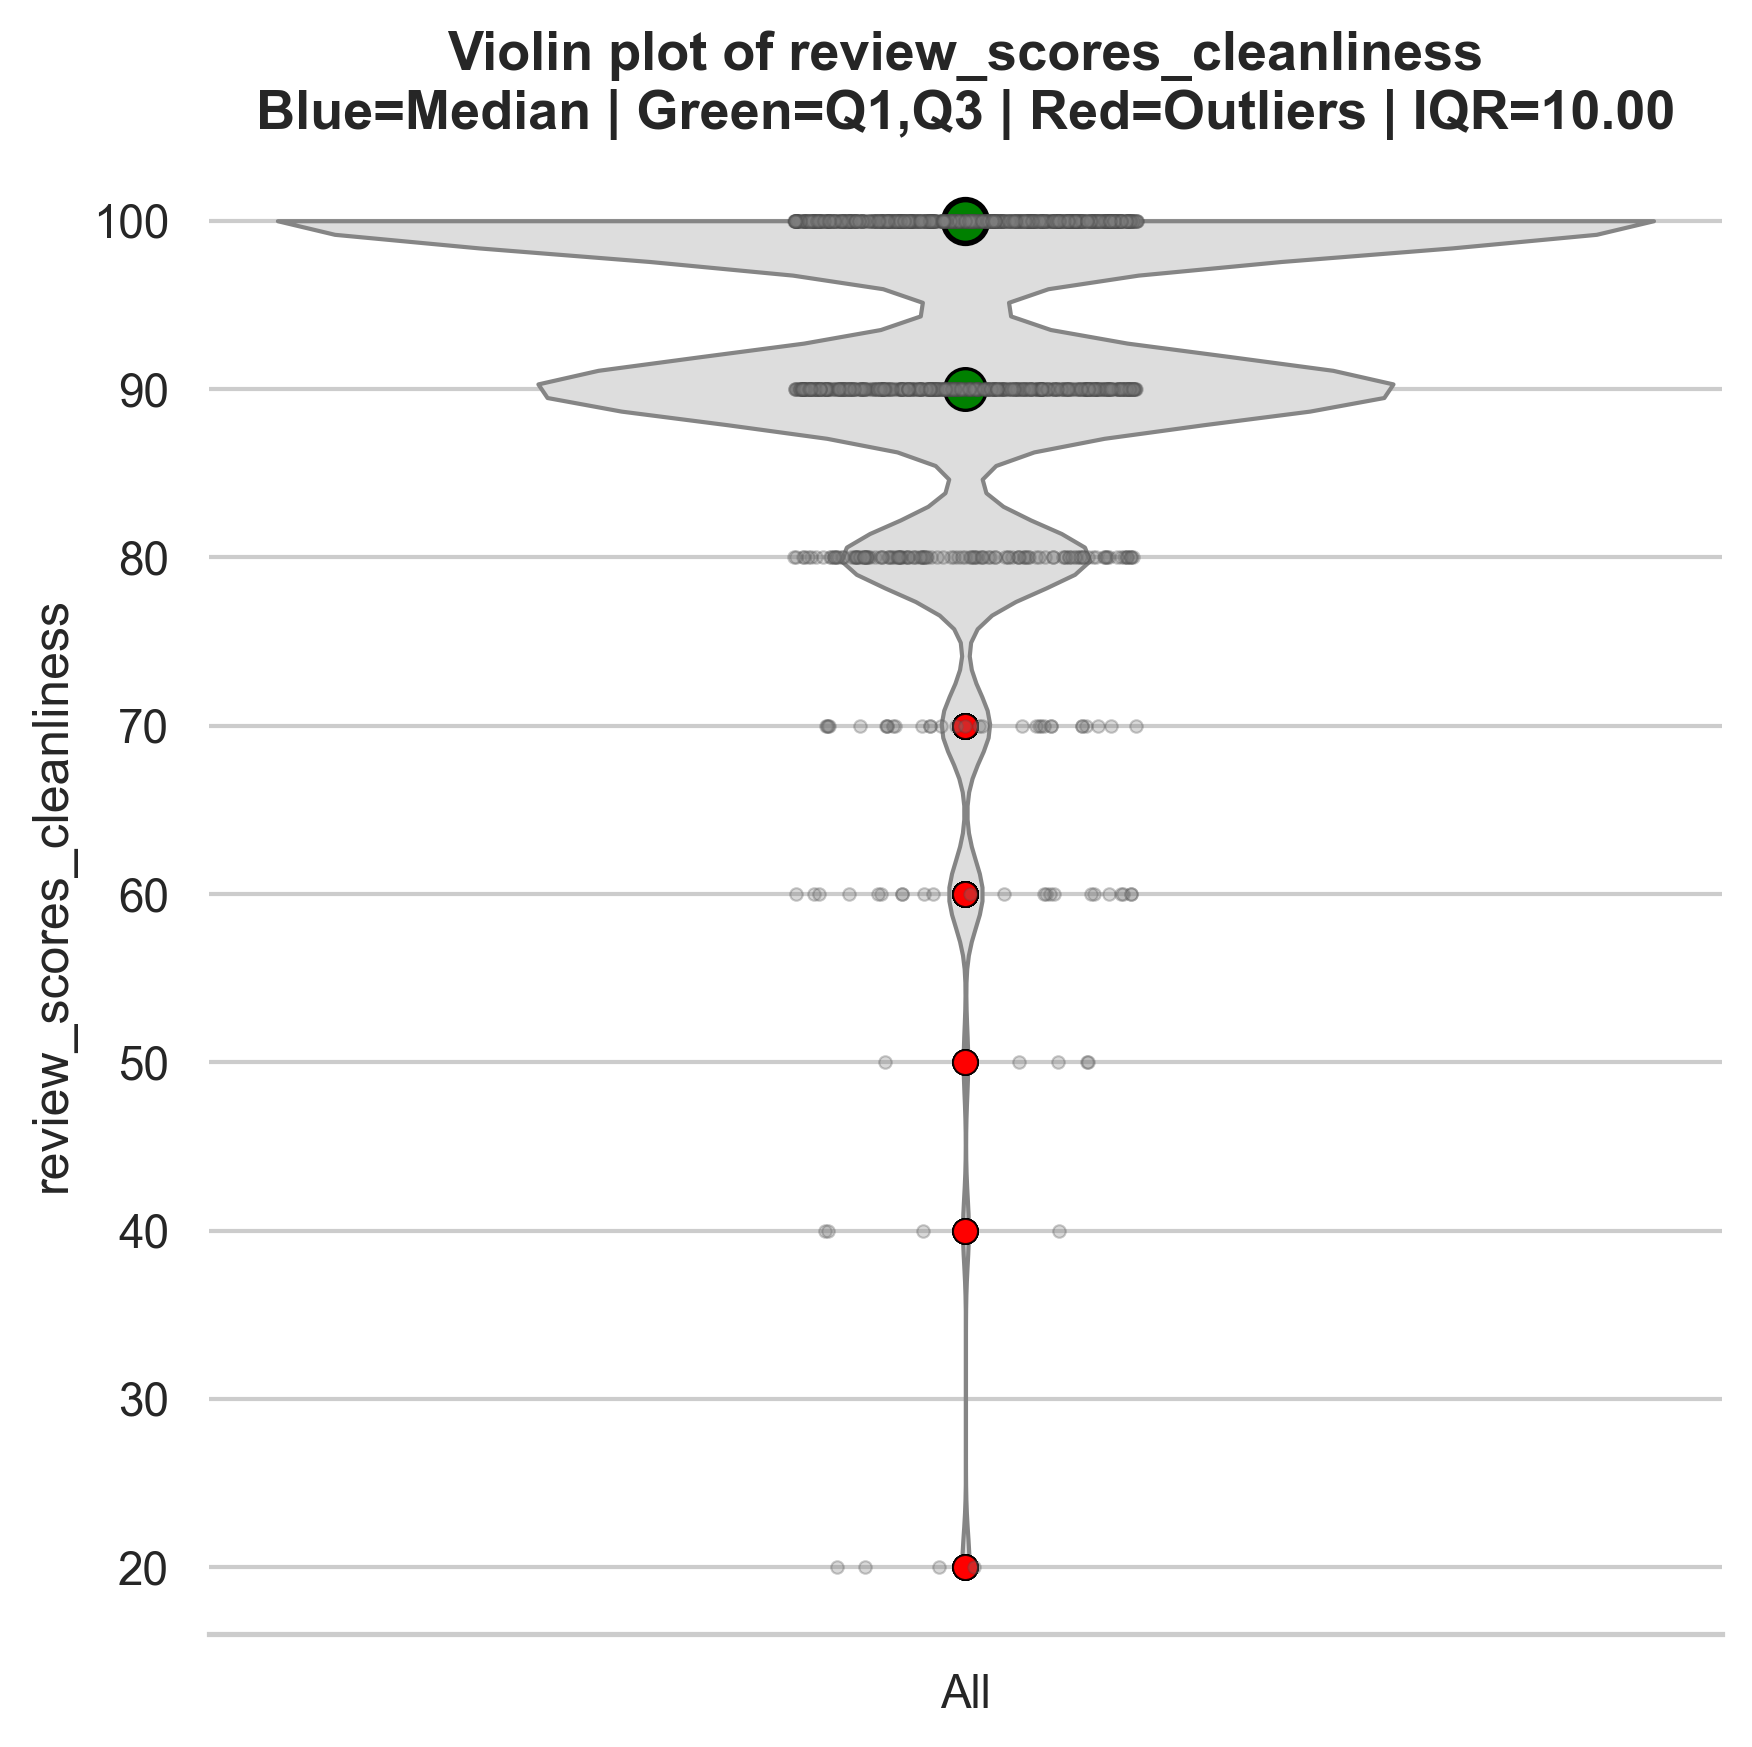

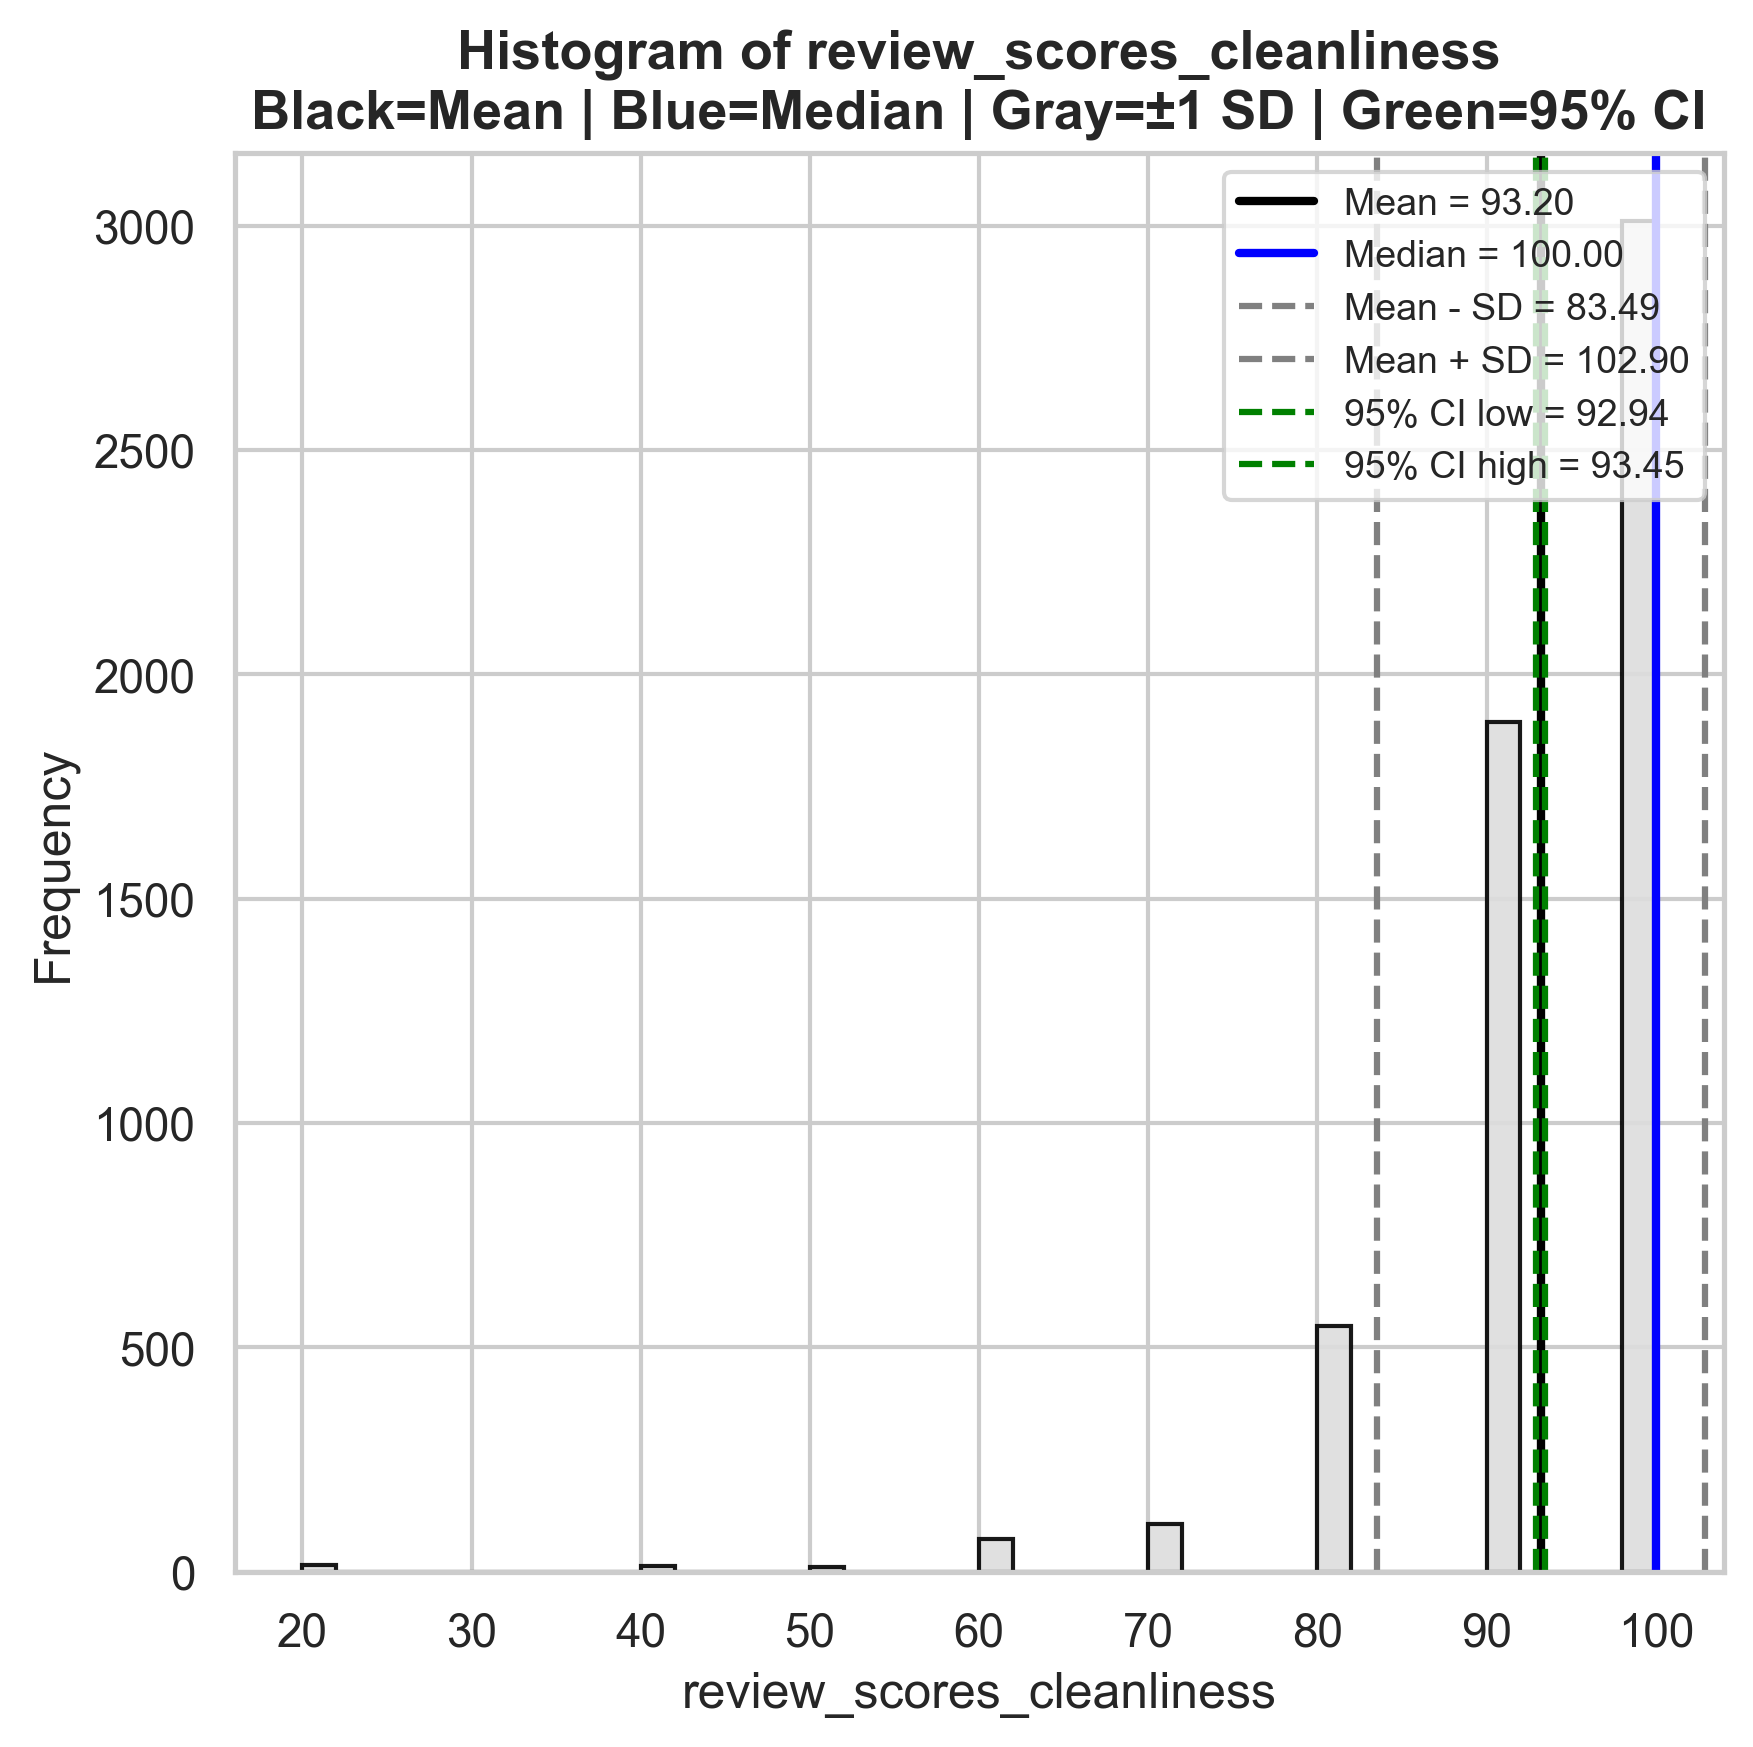

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,review_scores_cleanliness,5671,93.196967,100.0,9.702261,92.944396,93.449538,90.0,100.0,10.0,75.0,115.0,219,-2.596146,Highly skewed.



Unique values table
Number of non-nulls: 5671
Number of unique values: 8


,column,value,count,frequency_non_null
0,review_scores_cleanliness,20.0,16,0.002821
1,review_scores_cleanliness,40.0,13,0.002292
2,review_scores_cleanliness,50.0,10,0.001763
3,review_scores_cleanliness,60.0,74,0.013049
4,review_scores_cleanliness,70.0,106,0.018692
5,review_scores_cleanliness,80.0,547,0.096456
6,review_scores_cleanliness,90.0,1894,0.333980
7,review_scores_cleanliness,100.0,3011,0.530947



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,review_scores_cleanliness,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,review_scores_cleanliness,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,review_scores_cleanliness,numeric,city,categorical,Chi-square,90.818407,8.401334e-17,Significant,Statistically significant at p < 0.05.,
3,review_scores_cleanliness,numeric,room_type,categorical,Chi-square,4.619421,2.018823e-01,Not significant,Not statistically significant at p < 0.05.,
4,review_scores_cleanliness,numeric,accommodates,numeric,Pearson,-0.017235,1.943837e-01,Not significant,Not statistically significant at p < 0.05.,
5,review_scores_cleanliness,numeric,bathrooms,categorical,Chi-square,23.797769,8.155651e-03,Significant,Statistically significant at p < 0.05.,
6,review_scores_cleanliness,numeric,bedrooms,categorical,Chi-square,15.515777,1.600805e-01,Not significant,Not statistically significant at p < 0.05.,
7,review_scores_cleanliness,numeric,beds,numeric,Pearson,-0.022874,8.499721e-02,Not significant,Not statistically significant at p < 0.05.,
8,review_scores_cleanliness,numeric,price,numeric,Pearson,0.035849,7.355065e-03,Significant,Statistically significant at p < 0.05.,
9,review_scores_cleanliness,numeric,minimum_nights,numeric,Pearson,-0.005974,6.528440e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-2.596146,Highly skewed.,Baseline.
1,Log Transformation,-5.417499,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-3.643885,Highly skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.457851,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [51]:
analysis = analyze_single_field(df, 
                                target_col="review_scores_cleanliness", 
                                results_dir=RESULTS_DIR, 
                                show_in_notebook=True)

###### COMMUNICATION

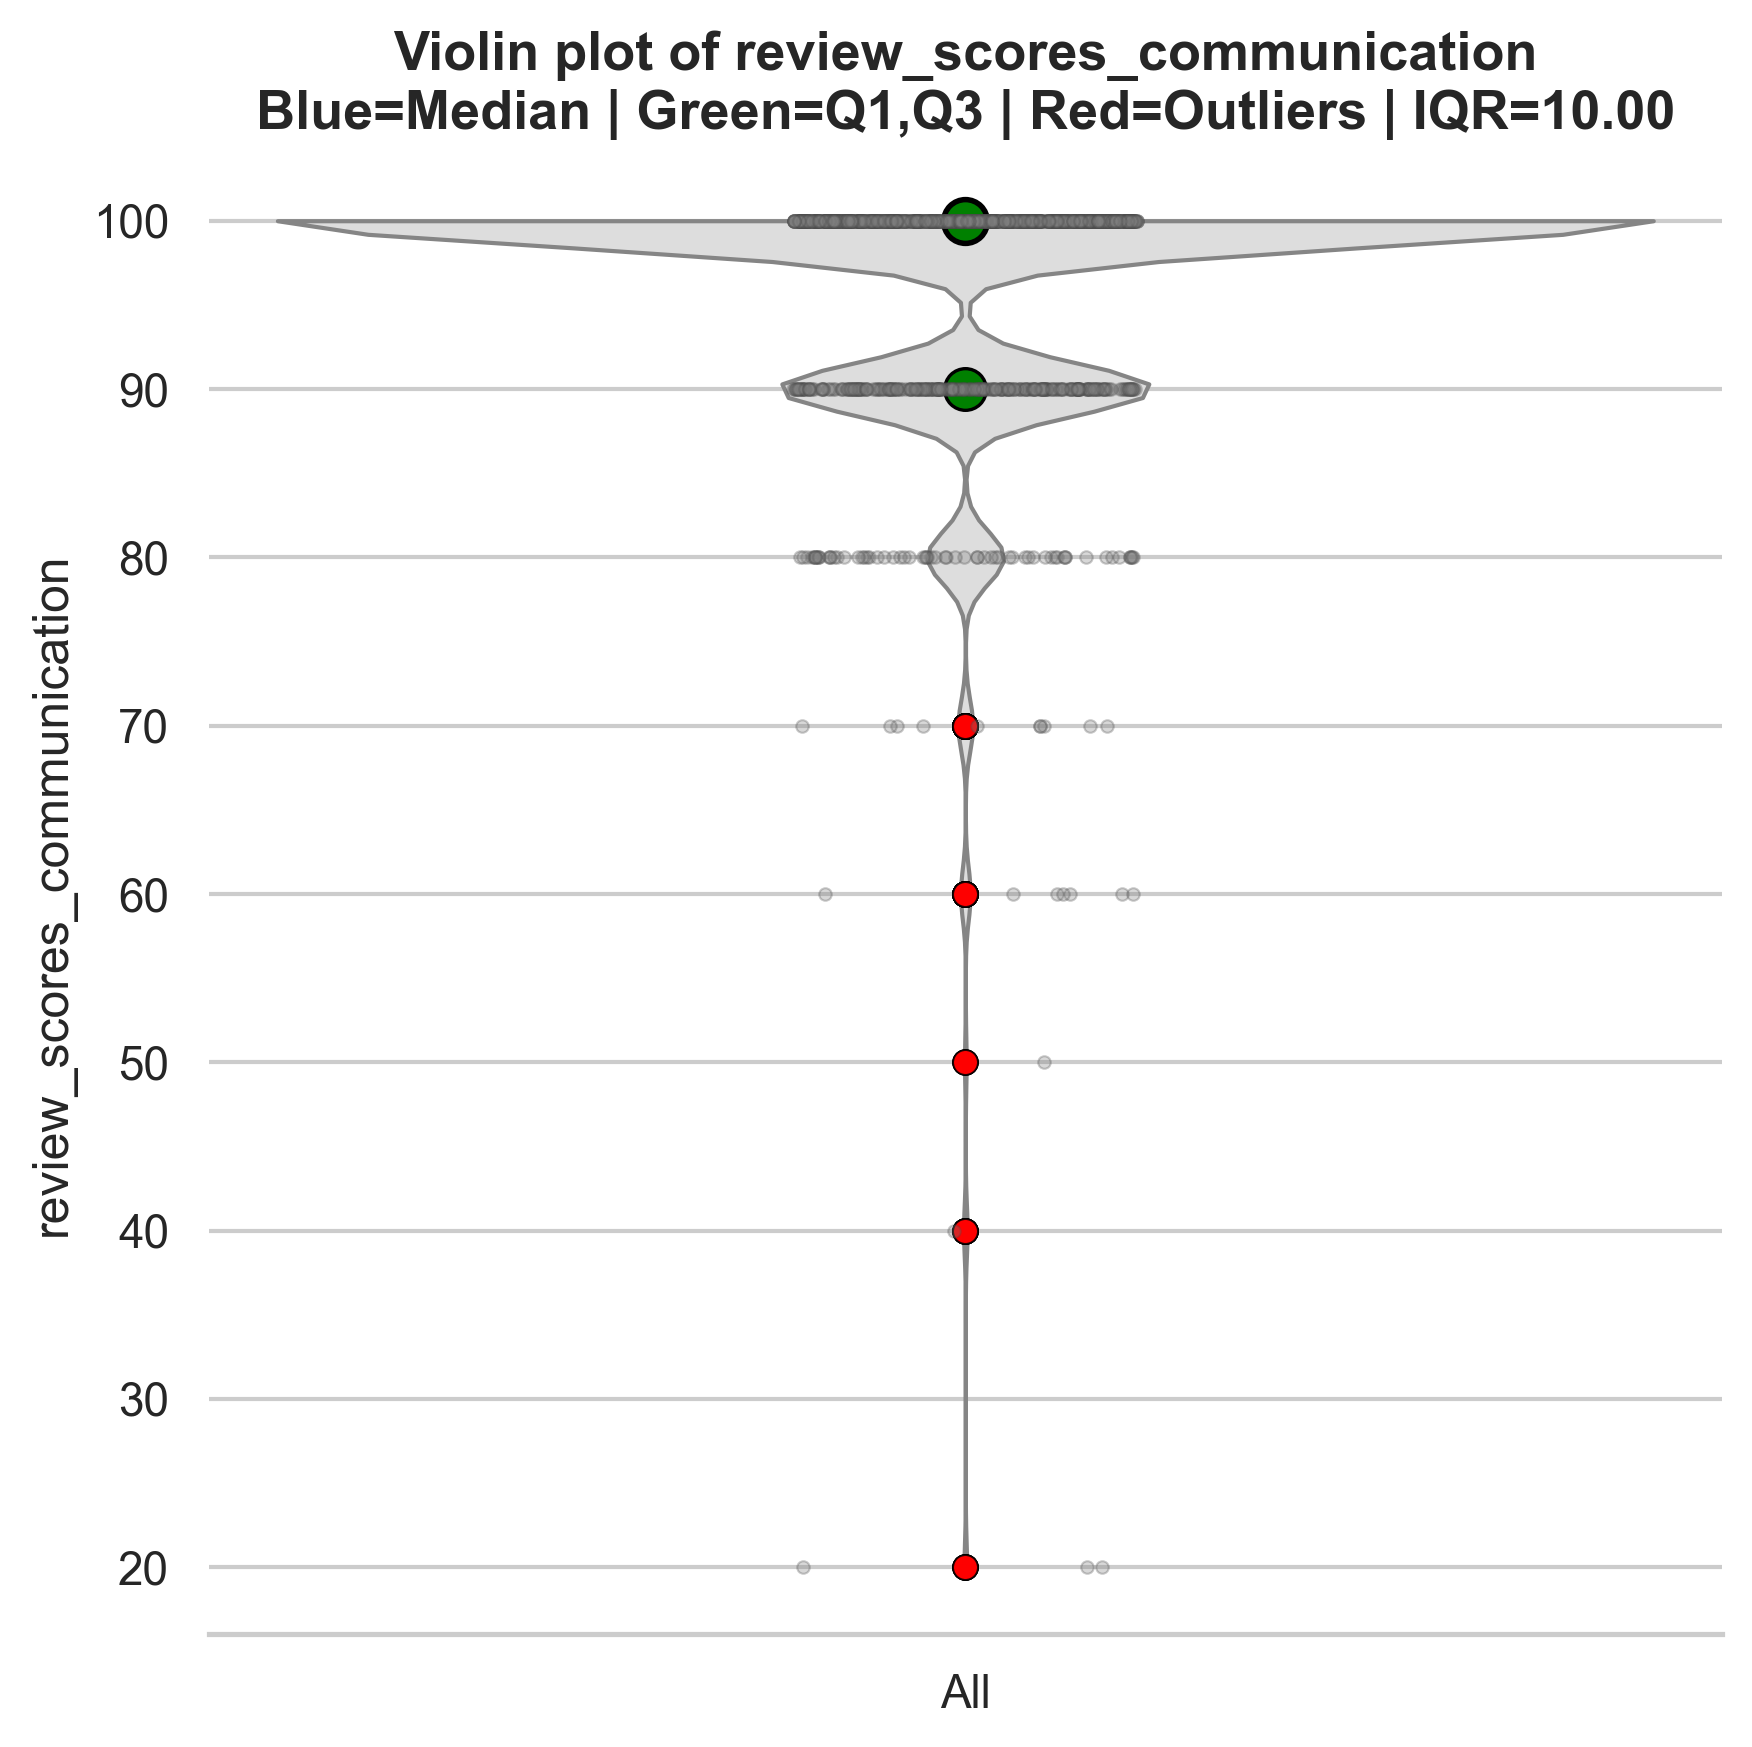

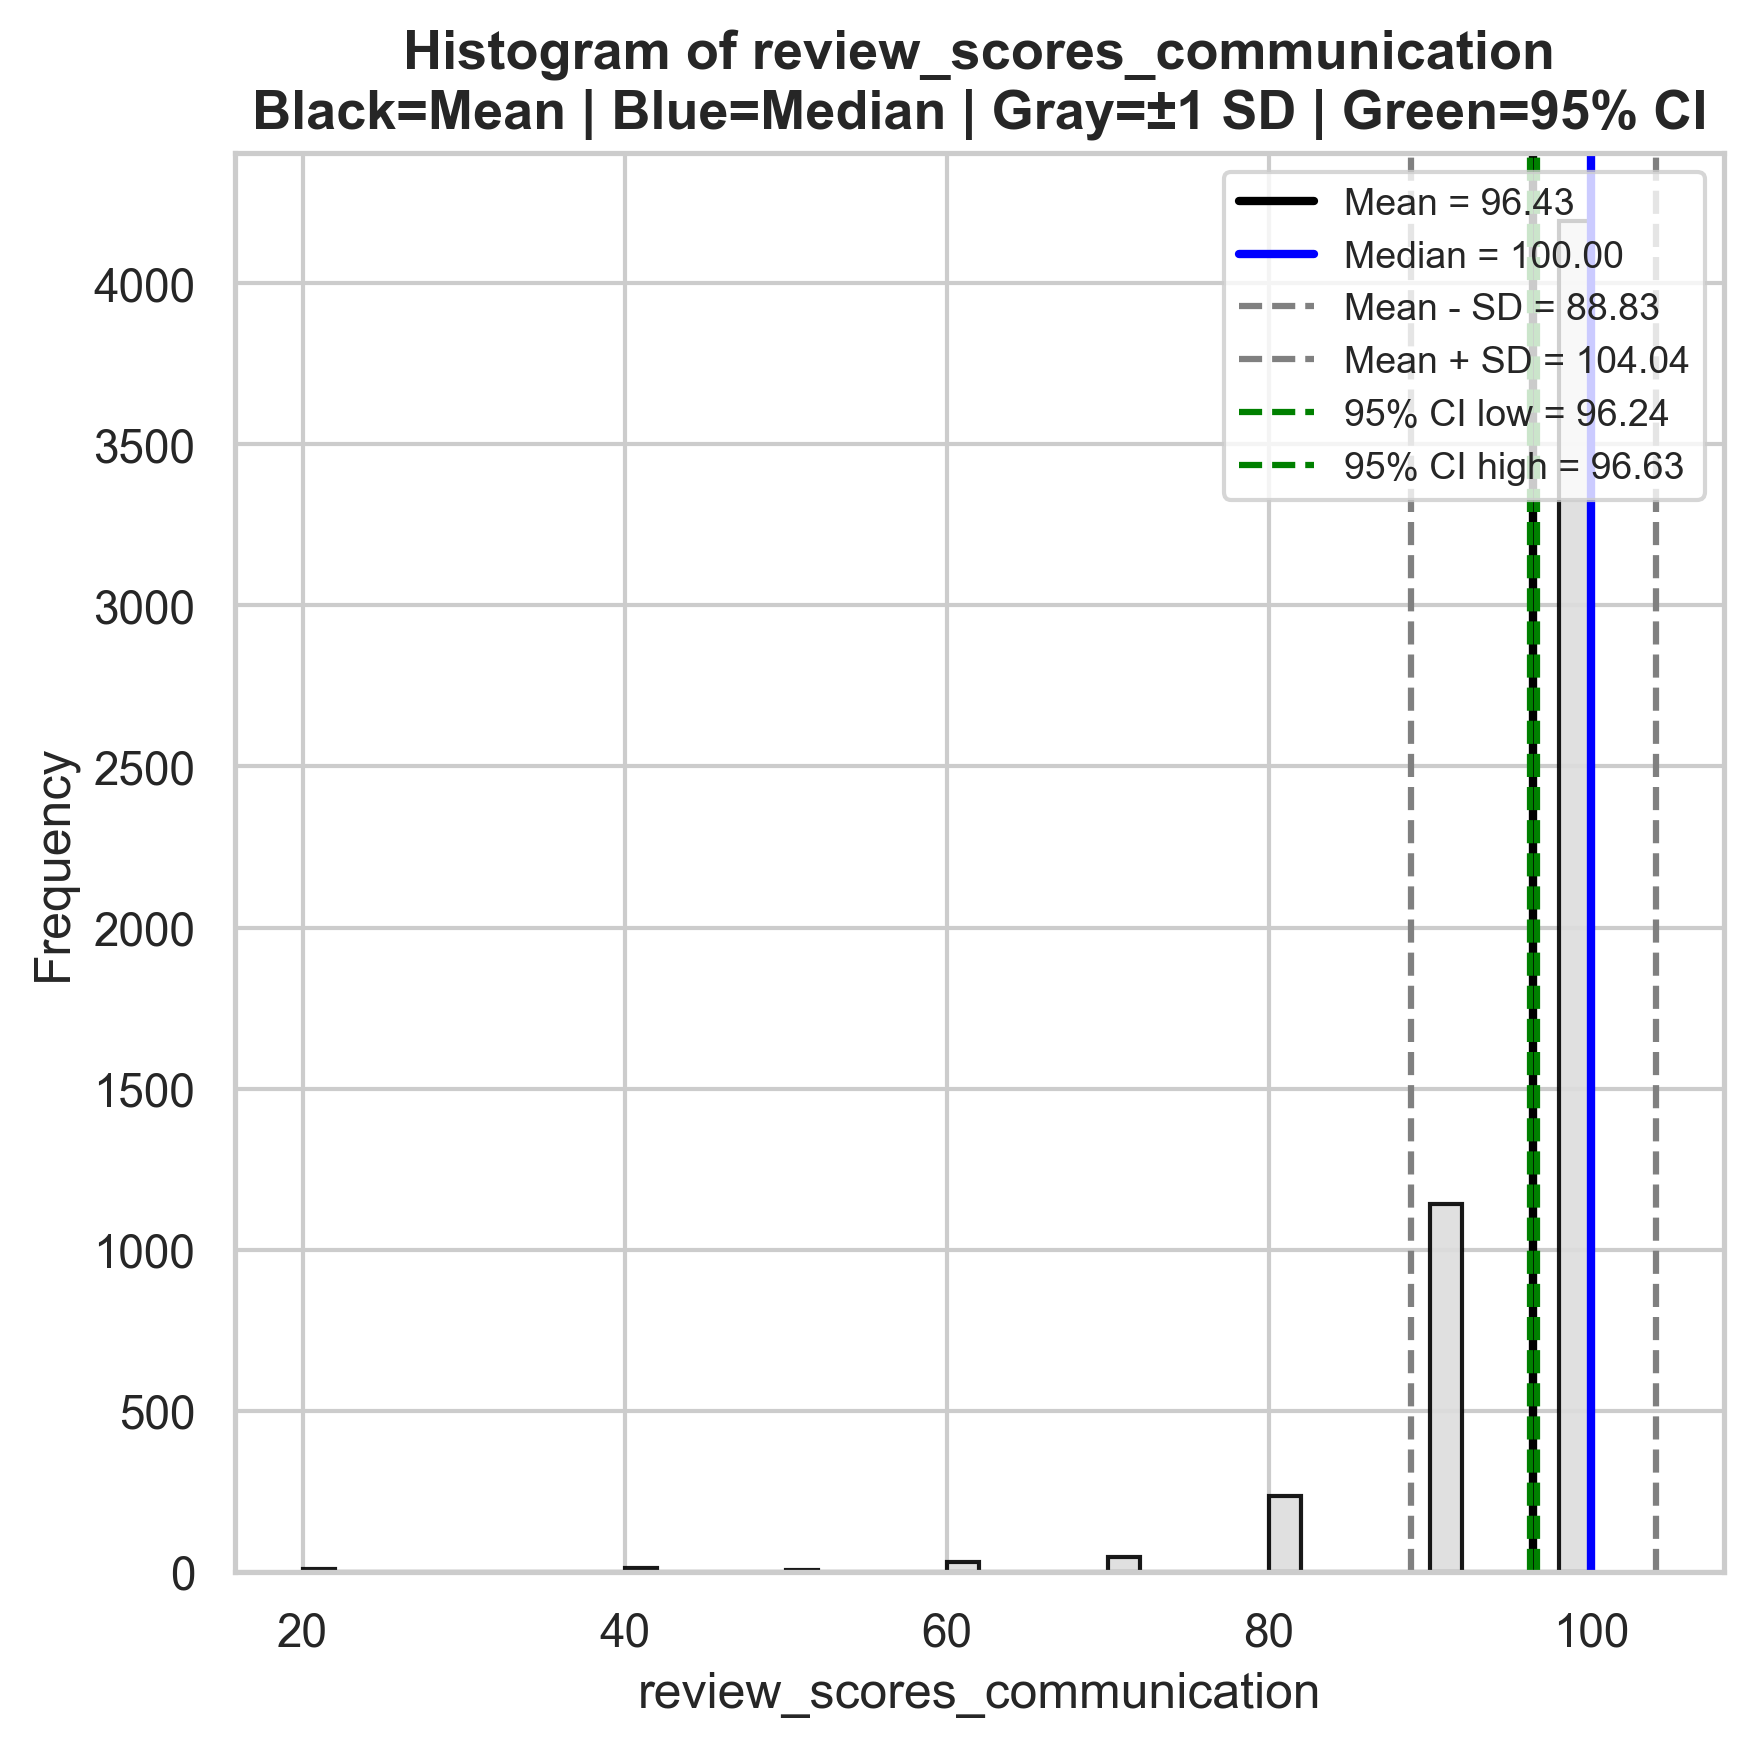

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,review_scores_communication,5669,96.434997,100.0,7.605426,96.236976,96.633018,90.0,100.0,10.0,75.0,115.0,99,-3.807226,Highly skewed.



Unique values table
Number of non-nulls: 5669
Number of unique values: 8


,column,value,count,frequency_non_null
0,review_scores_communication,20.0,8,0.001411
1,review_scores_communication,40.0,11,0.001940
2,review_scores_communication,50.0,5,0.000882
3,review_scores_communication,60.0,30,0.005292
4,review_scores_communication,70.0,45,0.007938
5,review_scores_communication,80.0,235,0.041454
6,review_scores_communication,90.0,1141,0.201270
7,review_scores_communication,100.0,4194,0.739813



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,review_scores_communication,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,review_scores_communication,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,review_scores_communication,numeric,city,categorical,Chi-square,76.686595,6.514009e-14,Significant,Statistically significant at p < 0.05.,
3,review_scores_communication,numeric,room_type,categorical,Chi-square,2.302613,5.120204e-01,Not significant,Not statistically significant at p < 0.05.,
4,review_scores_communication,numeric,accommodates,numeric,Pearson,-0.035602,7.343370e-03,Significant,Statistically significant at p < 0.05.,
5,review_scores_communication,numeric,bathrooms,categorical,Chi-square,17.928582,5.618037e-02,Not significant,Not statistically significant at p < 0.05.,
6,review_scores_communication,numeric,bedrooms,categorical,Chi-square,11.410434,4.095461e-01,Not significant,Not statistically significant at p < 0.05.,
7,review_scores_communication,numeric,beds,numeric,Pearson,-0.026333,4.741577e-02,Significant,Statistically significant at p < 0.05.,
8,review_scores_communication,numeric,price,numeric,Pearson,-0.020463,1.261841e-01,Not significant,Not statistically significant at p < 0.05.,
9,review_scores_communication,numeric,minimum_nights,numeric,Pearson,-0.004778,7.190808e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-3.807226,Highly skewed.,Baseline.
1,Log Transformation,-7.232781,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-5.071895,Highly skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-1.111307,Highly skewed.,Improved; skewness decreased. Improved using l...


In [52]:
analysis = analyze_single_field(df, 
                                target_col="review_scores_communication", 
                                results_dir=RESULTS_DIR, 
                                show_in_notebook=True)

###### LOCATION

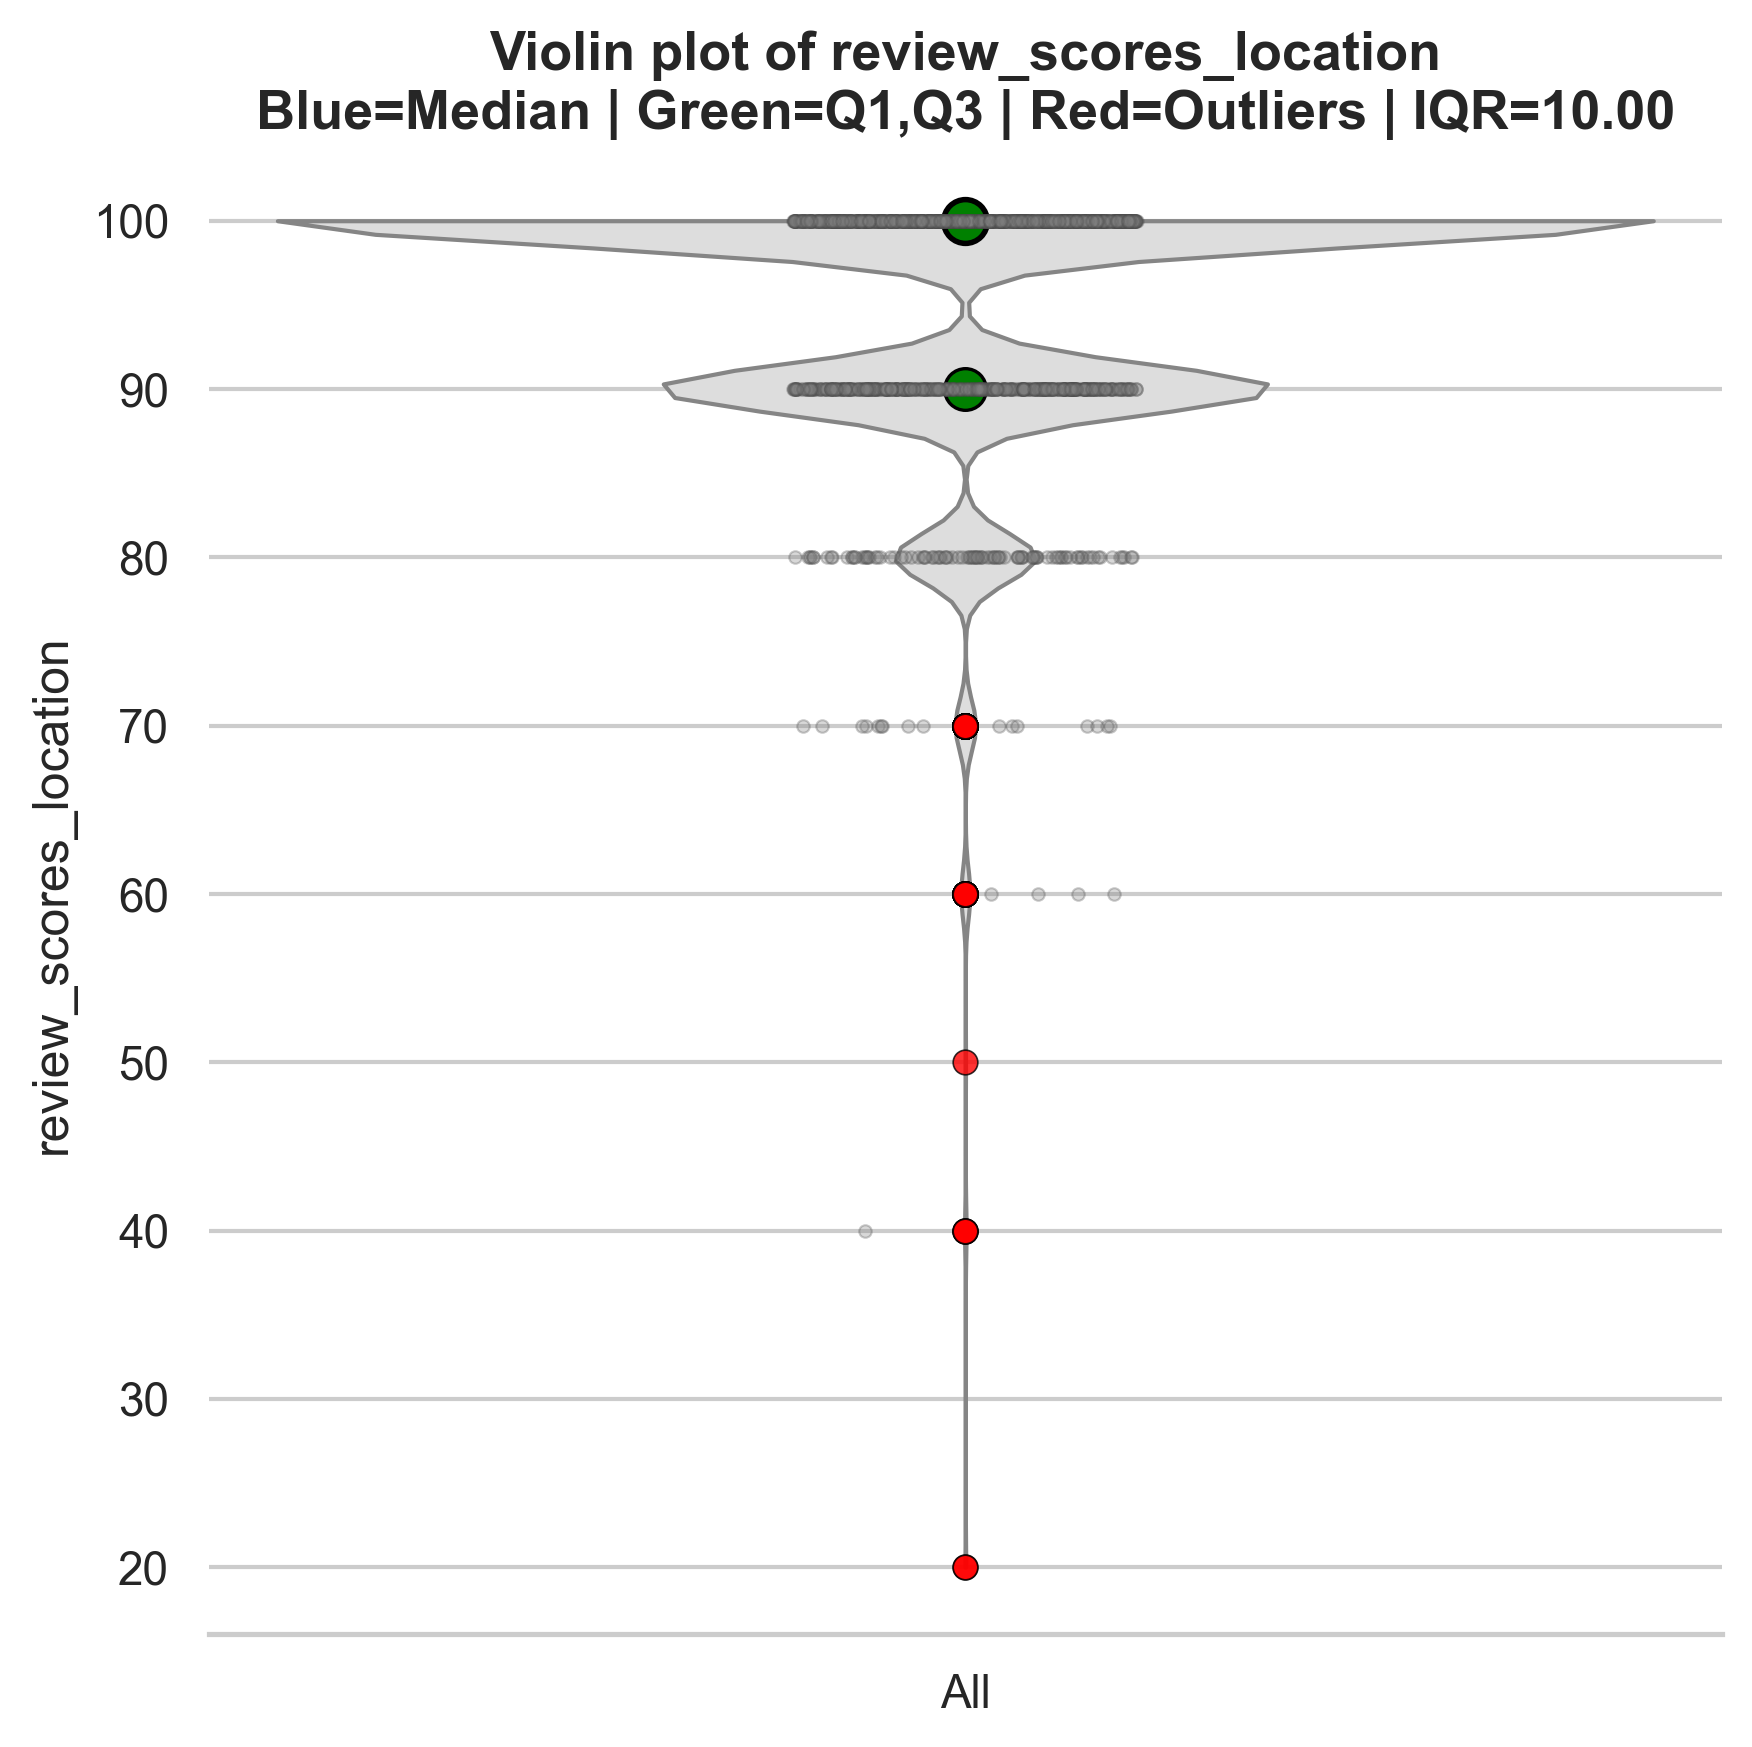

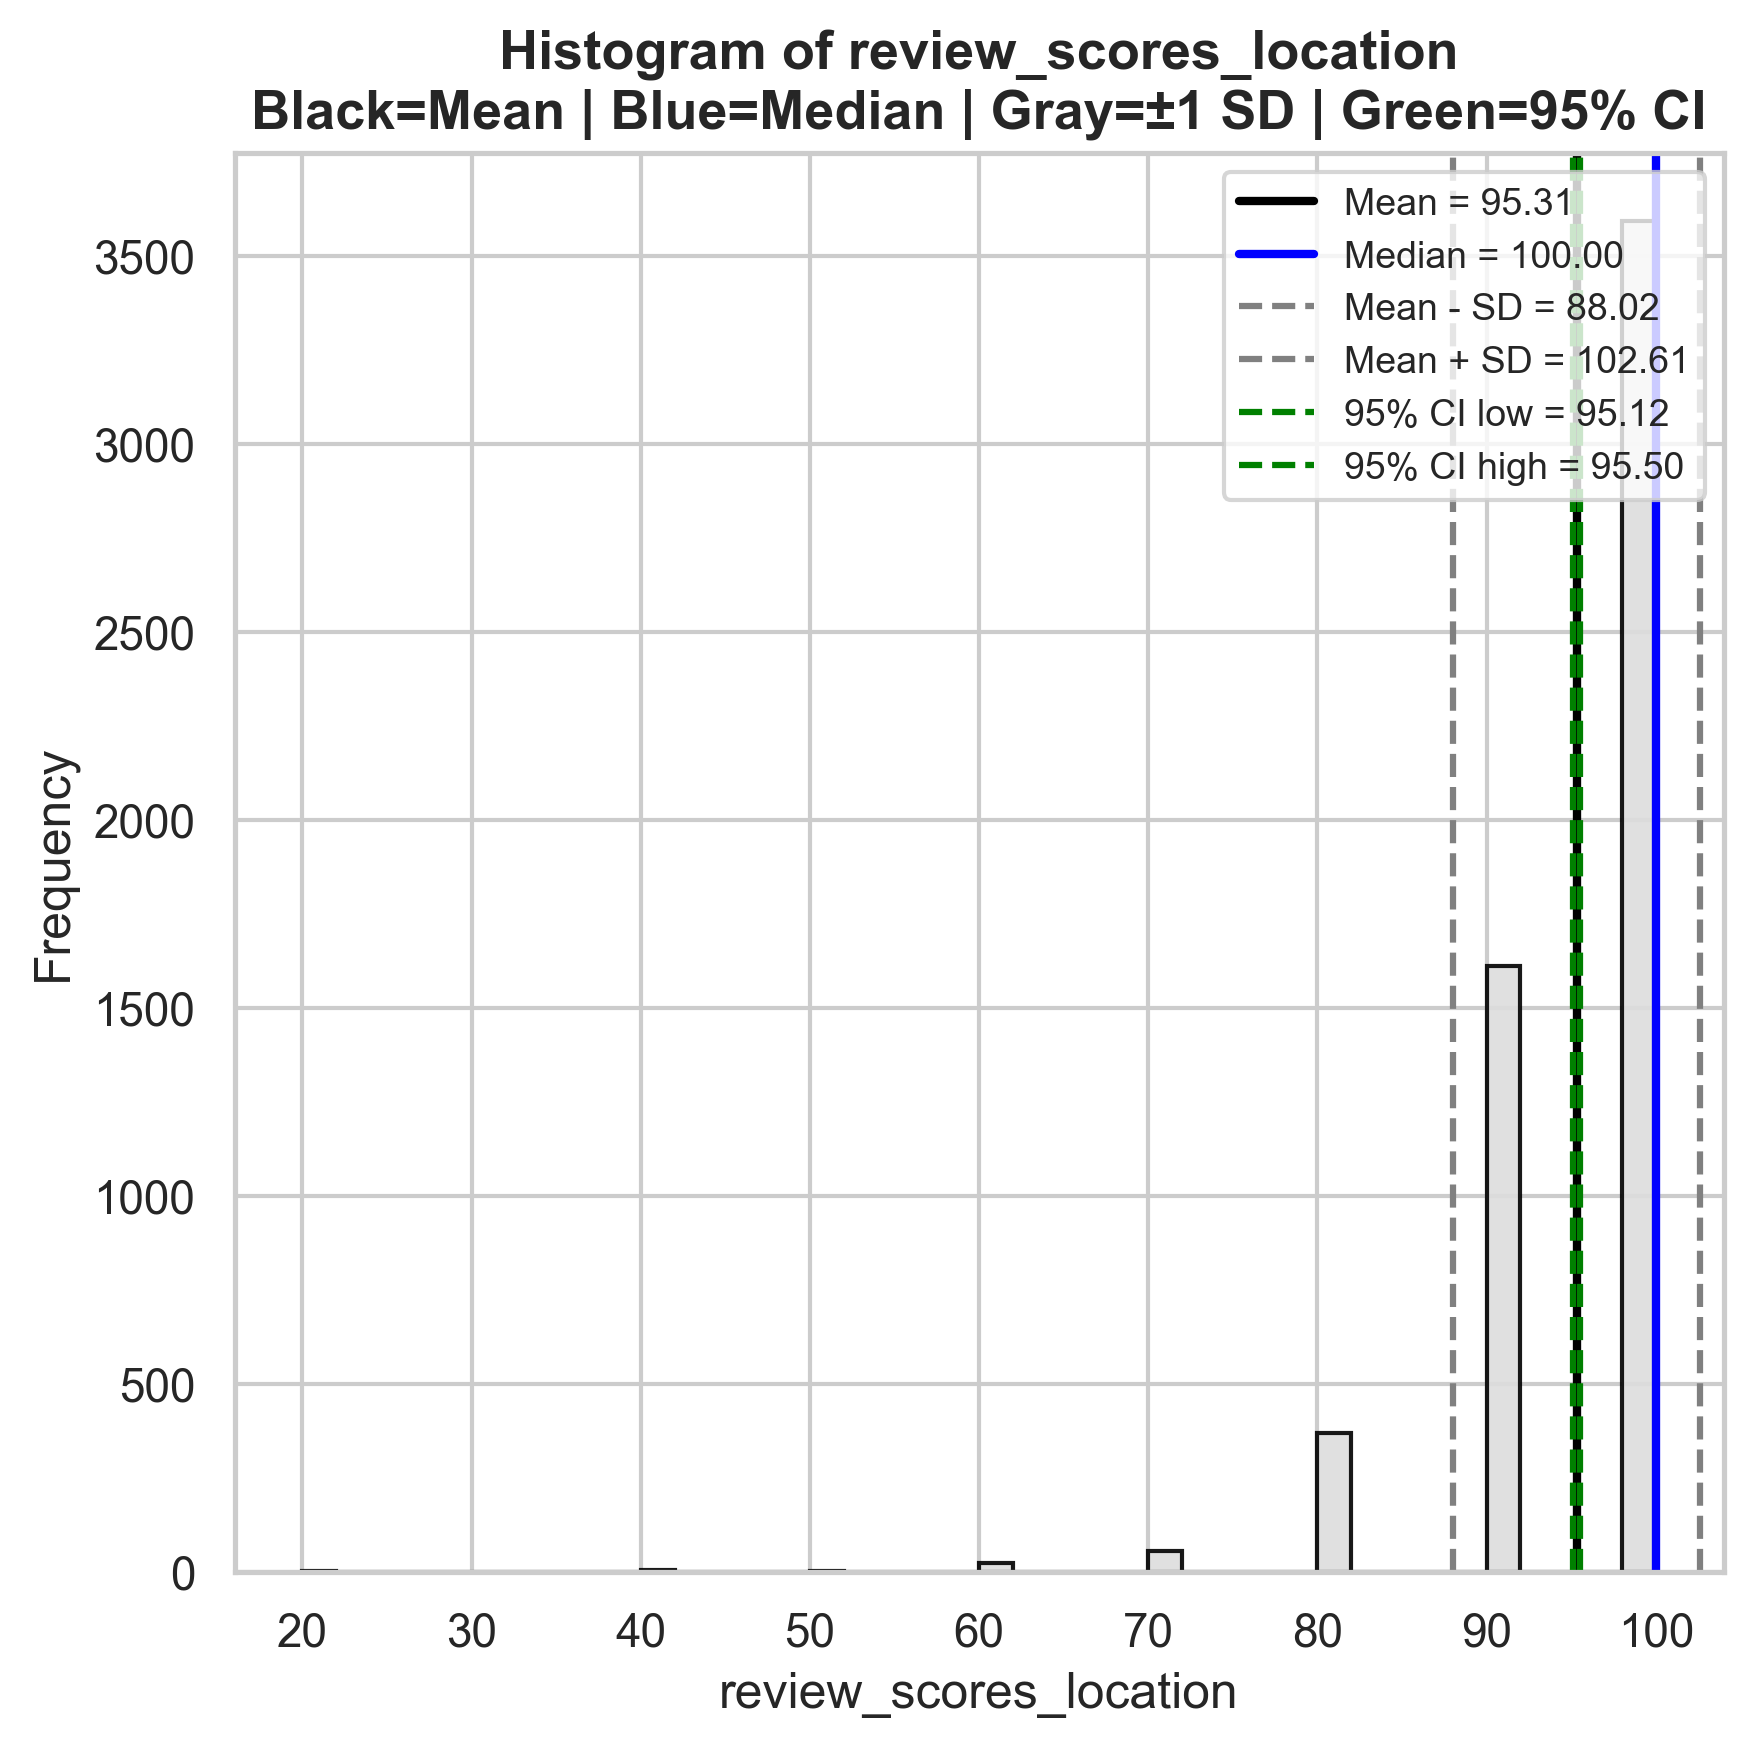

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,review_scores_location,5659,95.311893,100.0,7.295274,95.121779,95.502006,90.0,100.0,10.0,75.0,115.0,85,-2.164291,Highly skewed.



Unique values table
Number of non-nulls: 5659
Number of unique values: 8


,column,value,count,frequency_non_null
0,review_scores_location,20.0,2,0.000353
1,review_scores_location,40.0,4,0.000707
2,review_scores_location,50.0,1,0.000177
3,review_scores_location,60.0,24,0.004241
4,review_scores_location,70.0,54,0.009542
5,review_scores_location,80.0,369,0.065206
6,review_scores_location,90.0,1612,0.284856
7,review_scores_location,100.0,3593,0.634918



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,review_scores_location,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,review_scores_location,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,review_scores_location,numeric,city,categorical,Chi-square,76.546300,6.956286e-14,Significant,Statistically significant at p < 0.05.,
3,review_scores_location,numeric,room_type,categorical,Chi-square,3.567607,3.120990e-01,Not significant,Not statistically significant at p < 0.05.,
4,review_scores_location,numeric,accommodates,numeric,Pearson,-0.068598,2.400341e-07,Significant,Statistically significant at p < 0.05.,
5,review_scores_location,numeric,bathrooms,categorical,Chi-square,15.546245,1.133794e-01,Not significant,Not statistically significant at p < 0.05.,
6,review_scores_location,numeric,bedrooms,categorical,Chi-square,33.966569,3.662718e-04,Significant,Statistically significant at p < 0.05.,
7,review_scores_location,numeric,beds,numeric,Pearson,-0.080205,1.522620e-09,Significant,Statistically significant at p < 0.05.,
8,review_scores_location,numeric,price,numeric,Pearson,-0.001075,9.360352e-01,Not significant,Not statistically significant at p < 0.05.,
9,review_scores_location,numeric,minimum_nights,numeric,Pearson,-0.003706,7.804711e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-2.164291,Highly skewed.,Baseline.
1,Log Transformation,-4.181972,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-2.825958,Highly skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.636678,Moderately skewed.,Improved; skewness decreased. Improved using l...


In [53]:
analysis = analyze_single_field(df, 
                                target_col="review_scores_location", 
                                results_dir=RESULTS_DIR, 
                                show_in_notebook=True)

###### VALUE

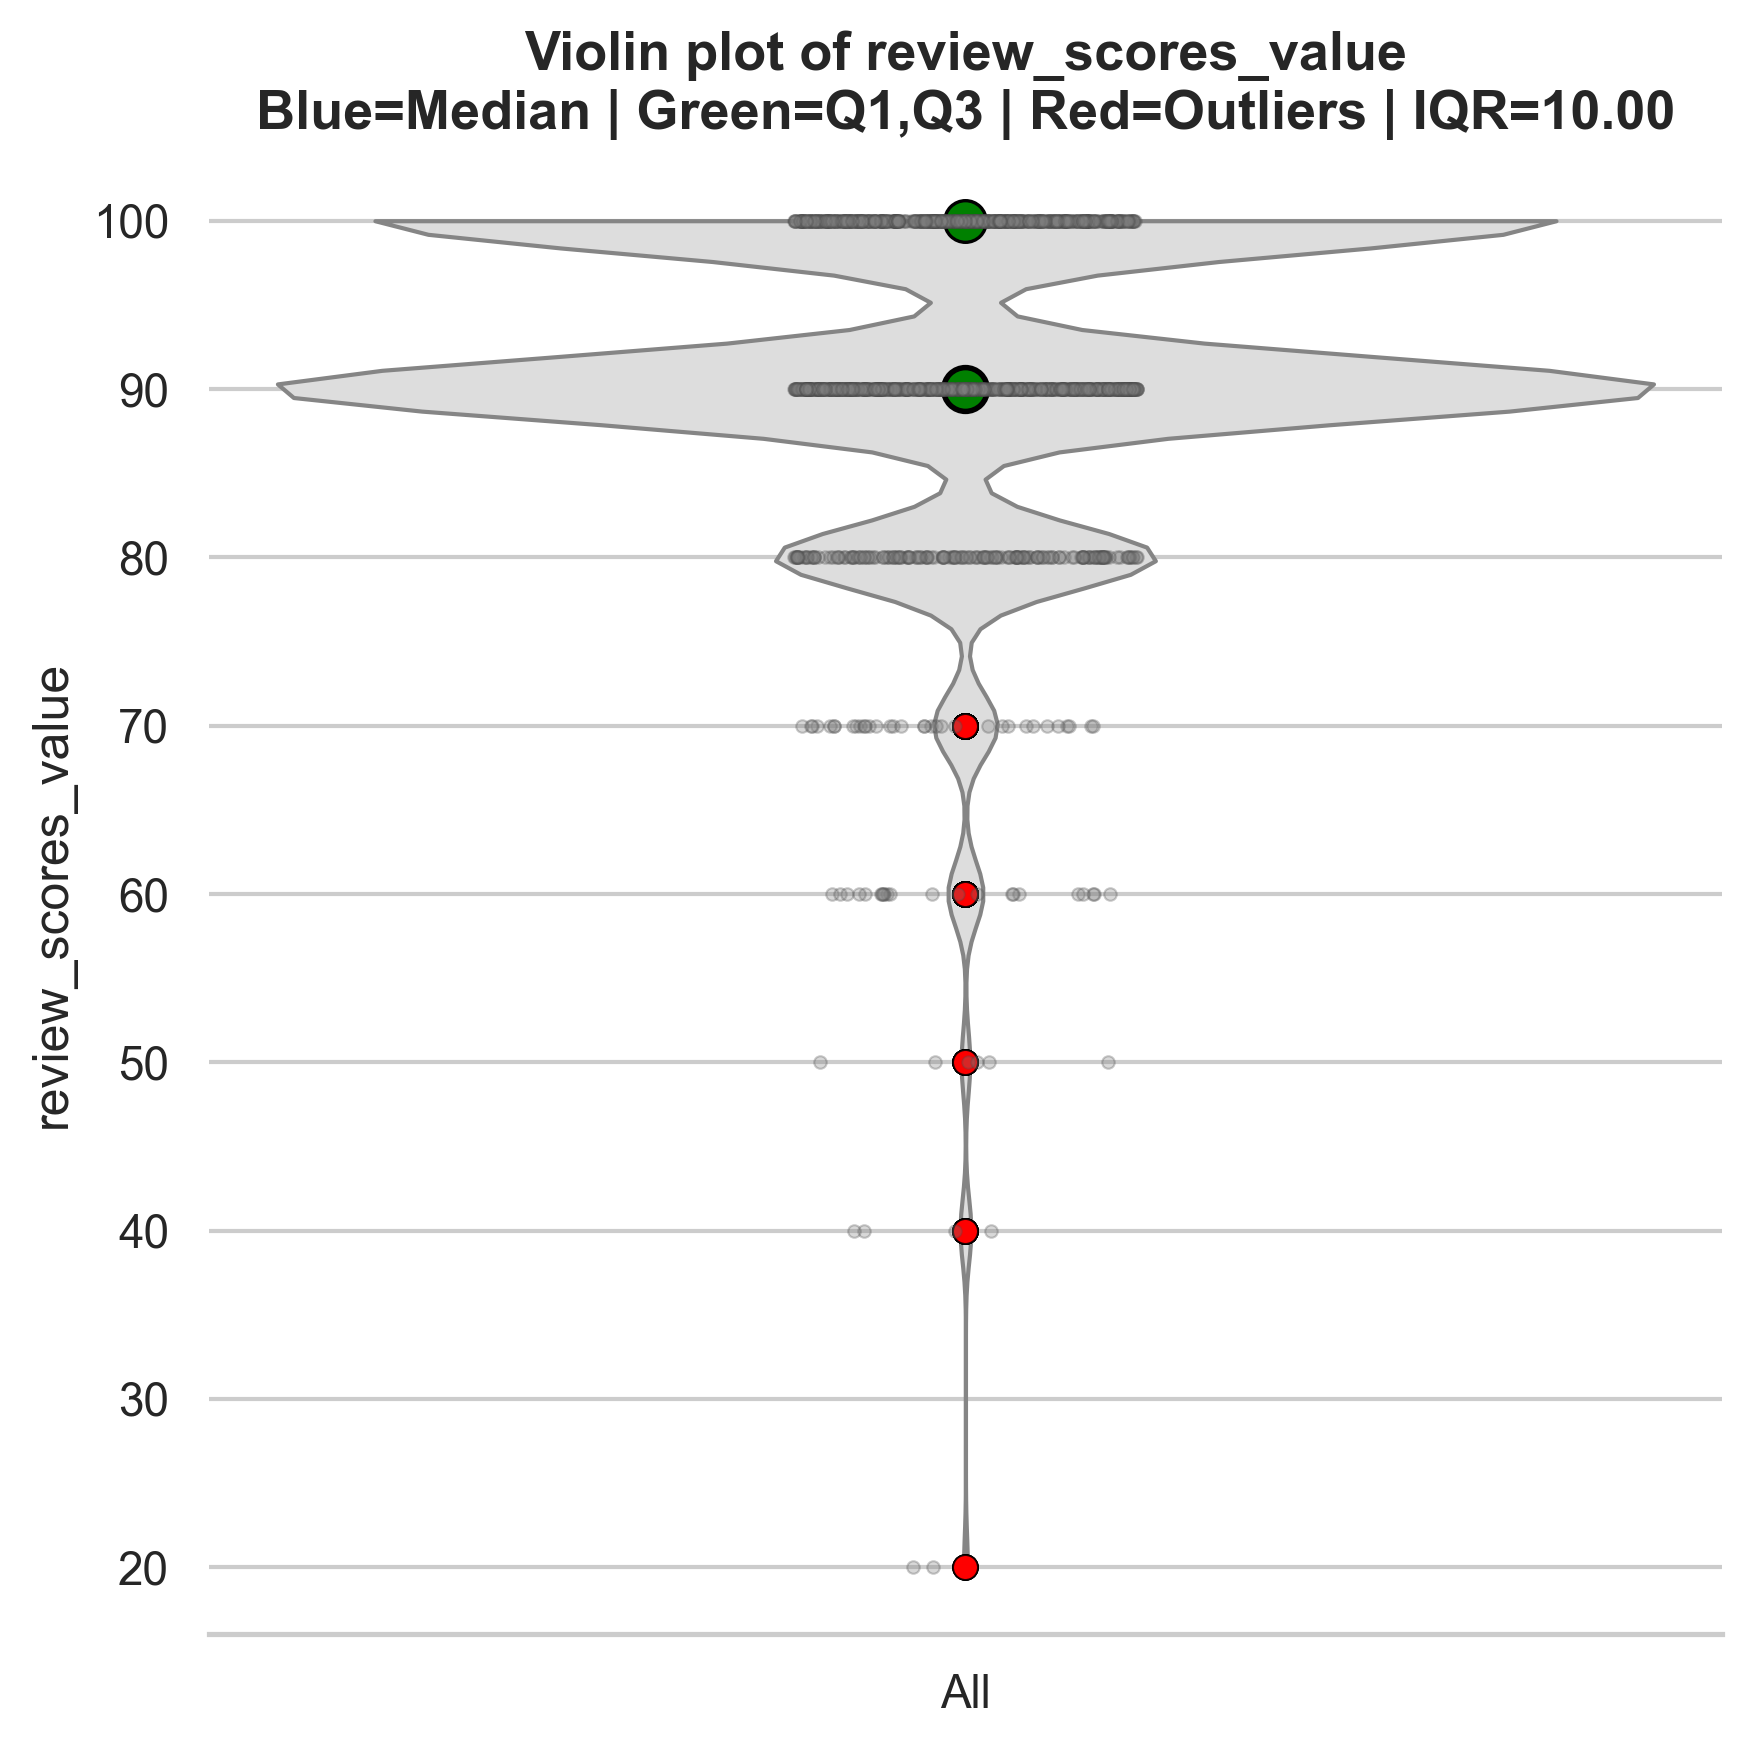

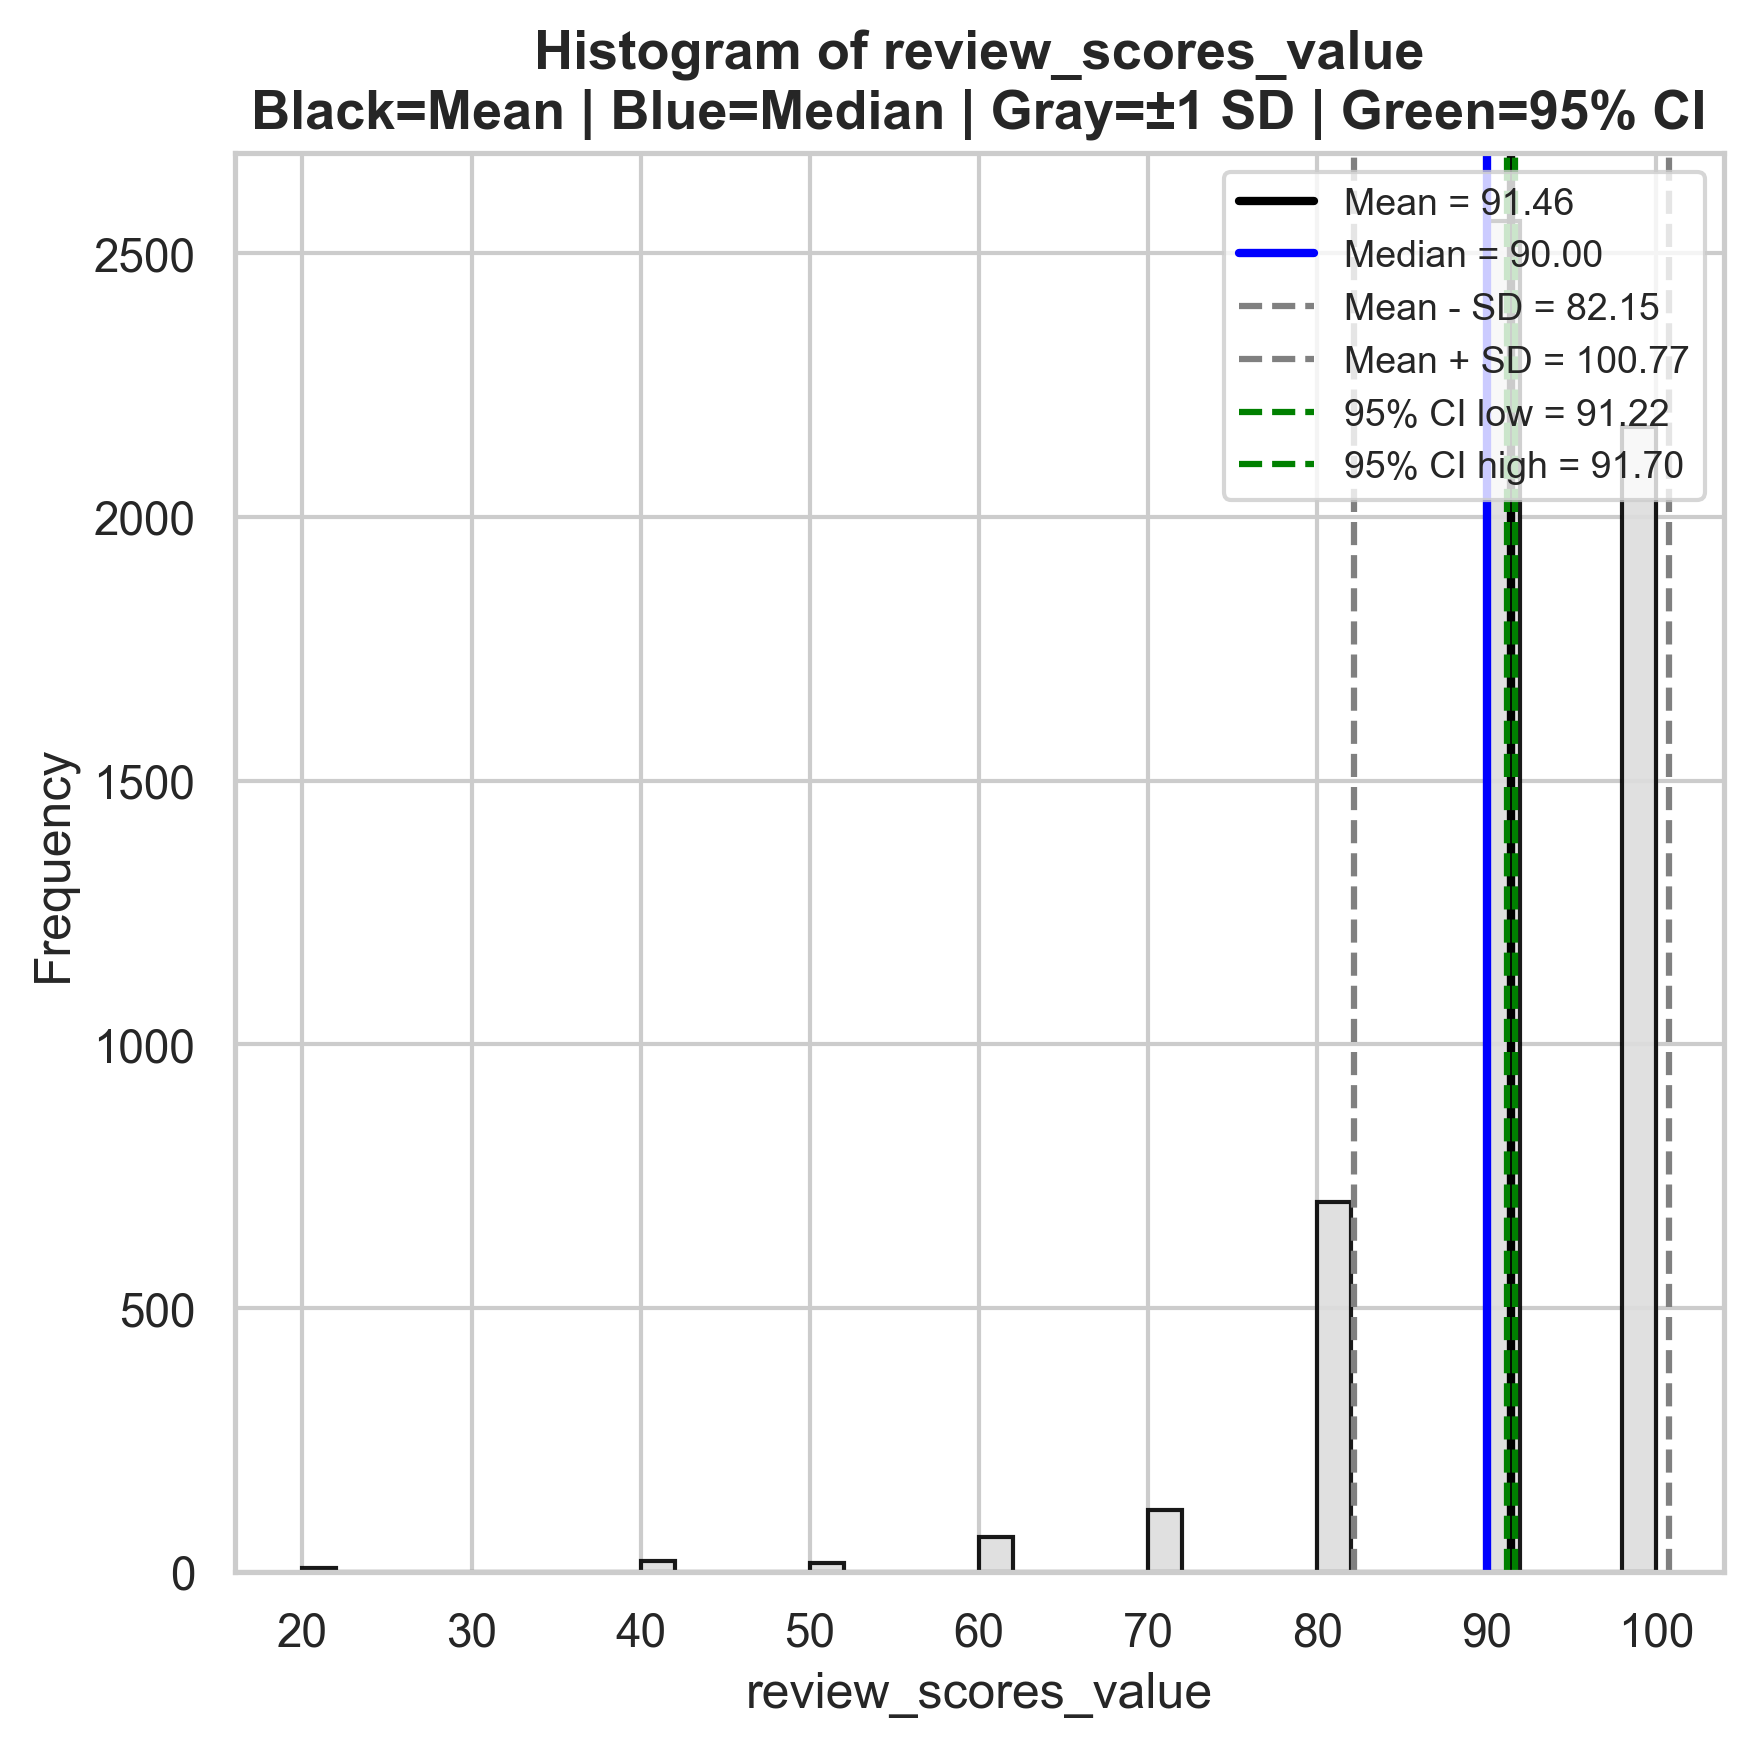

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,review_scores_value,5659,91.459622,90.0,9.309337,91.217022,91.702221,90.0,100.0,10.0,75.0,115.0,225,-2.040855,Highly skewed.



Unique values table
Number of non-nulls: 5659
Number of unique values: 8


,column,value,count,frequency_non_null
0,review_scores_value,20.0,7,0.001237
1,review_scores_value,40.0,20,0.003534
2,review_scores_value,50.0,16,0.002827
3,review_scores_value,60.0,65,0.011486
4,review_scores_value,70.0,117,0.020675
5,review_scores_value,80.0,702,0.124050
6,review_scores_value,90.0,2562,0.452730
7,review_scores_value,100.0,2170,0.383460



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,review_scores_value,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,review_scores_value,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,review_scores_value,numeric,city,categorical,Chi-square,72.185589,5.337560e-13,Significant,Statistically significant at p < 0.05.,
3,review_scores_value,numeric,room_type,categorical,Chi-square,22.608563,4.872605e-05,Significant,Statistically significant at p < 0.05.,
4,review_scores_value,numeric,accommodates,numeric,Pearson,-0.055899,2.583051e-05,Significant,Statistically significant at p < 0.05.,
5,review_scores_value,numeric,bathrooms,categorical,Chi-square,47.753312,6.884633e-07,Significant,Statistically significant at p < 0.05.,
6,review_scores_value,numeric,bedrooms,categorical,Chi-square,32.970102,5.320639e-04,Significant,Statistically significant at p < 0.05.,
7,review_scores_value,numeric,beds,numeric,Pearson,-0.048059,2.985275e-04,Significant,Statistically significant at p < 0.05.,
8,review_scores_value,numeric,price,numeric,Pearson,-0.034206,1.062858e-02,Significant,Statistically significant at p < 0.05.,
9,review_scores_value,numeric,minimum_nights,numeric,Pearson,-0.012339,3.533718e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-2.040855,Highly skewed.,Baseline.
1,Log Transformation,-4.252676,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-2.857023,Highly skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.198890,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [54]:
analysis = analyze_single_field(df, 
                                target_col="review_scores_value", 
                                results_dir=RESULTS_DIR, 
                                show_in_notebook=True)

###### Number of reviews per month

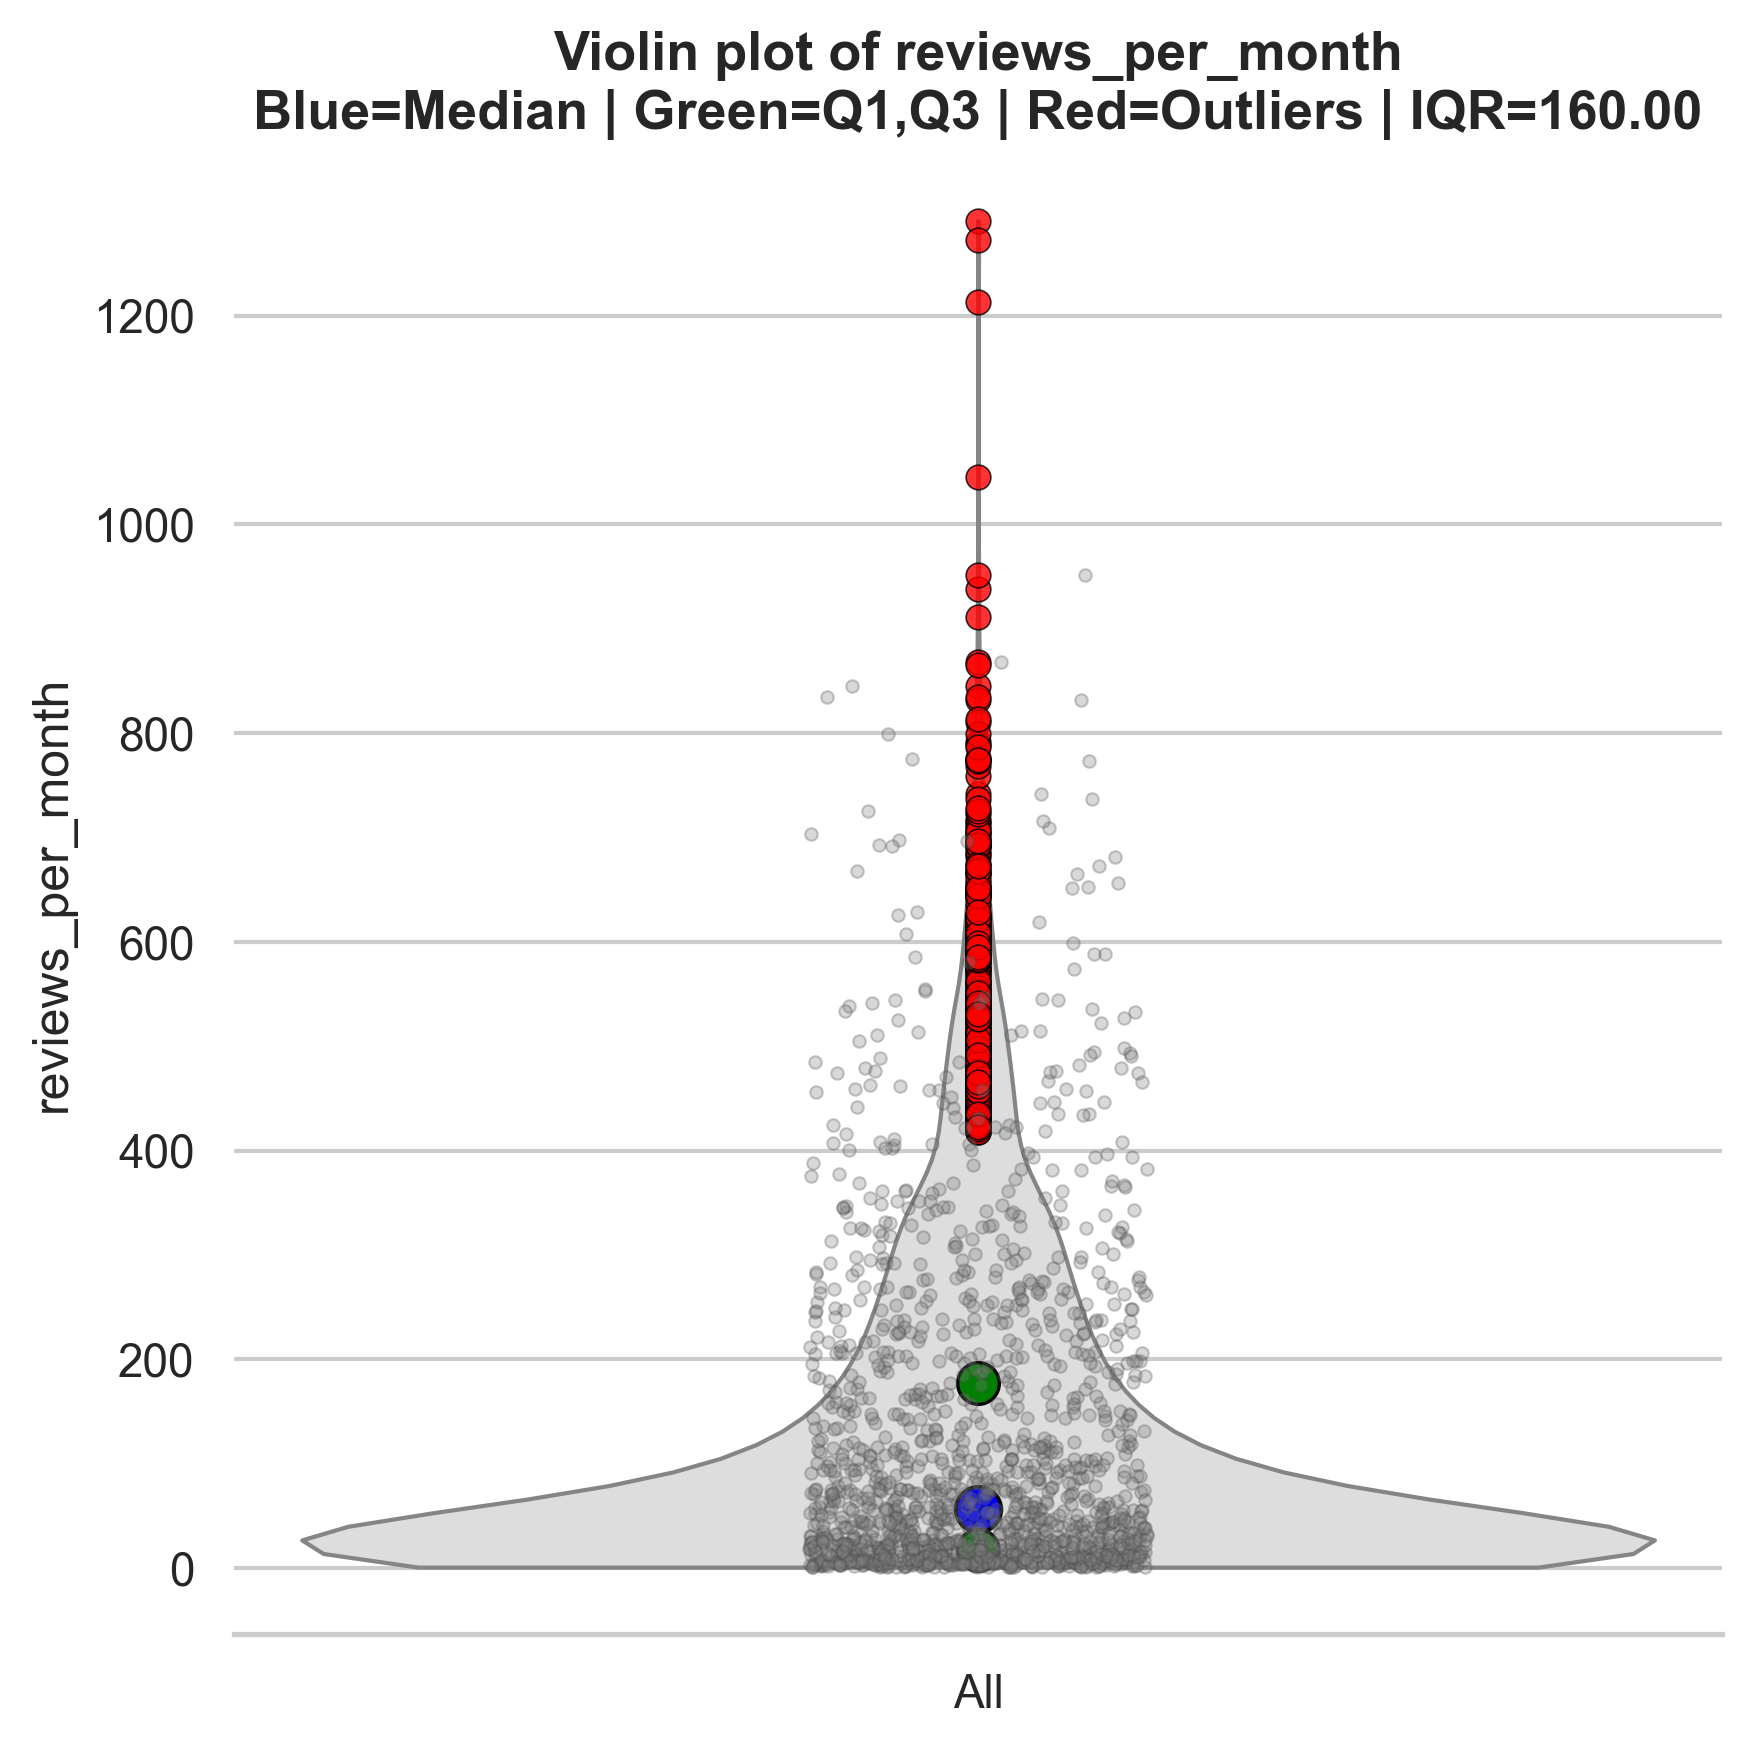

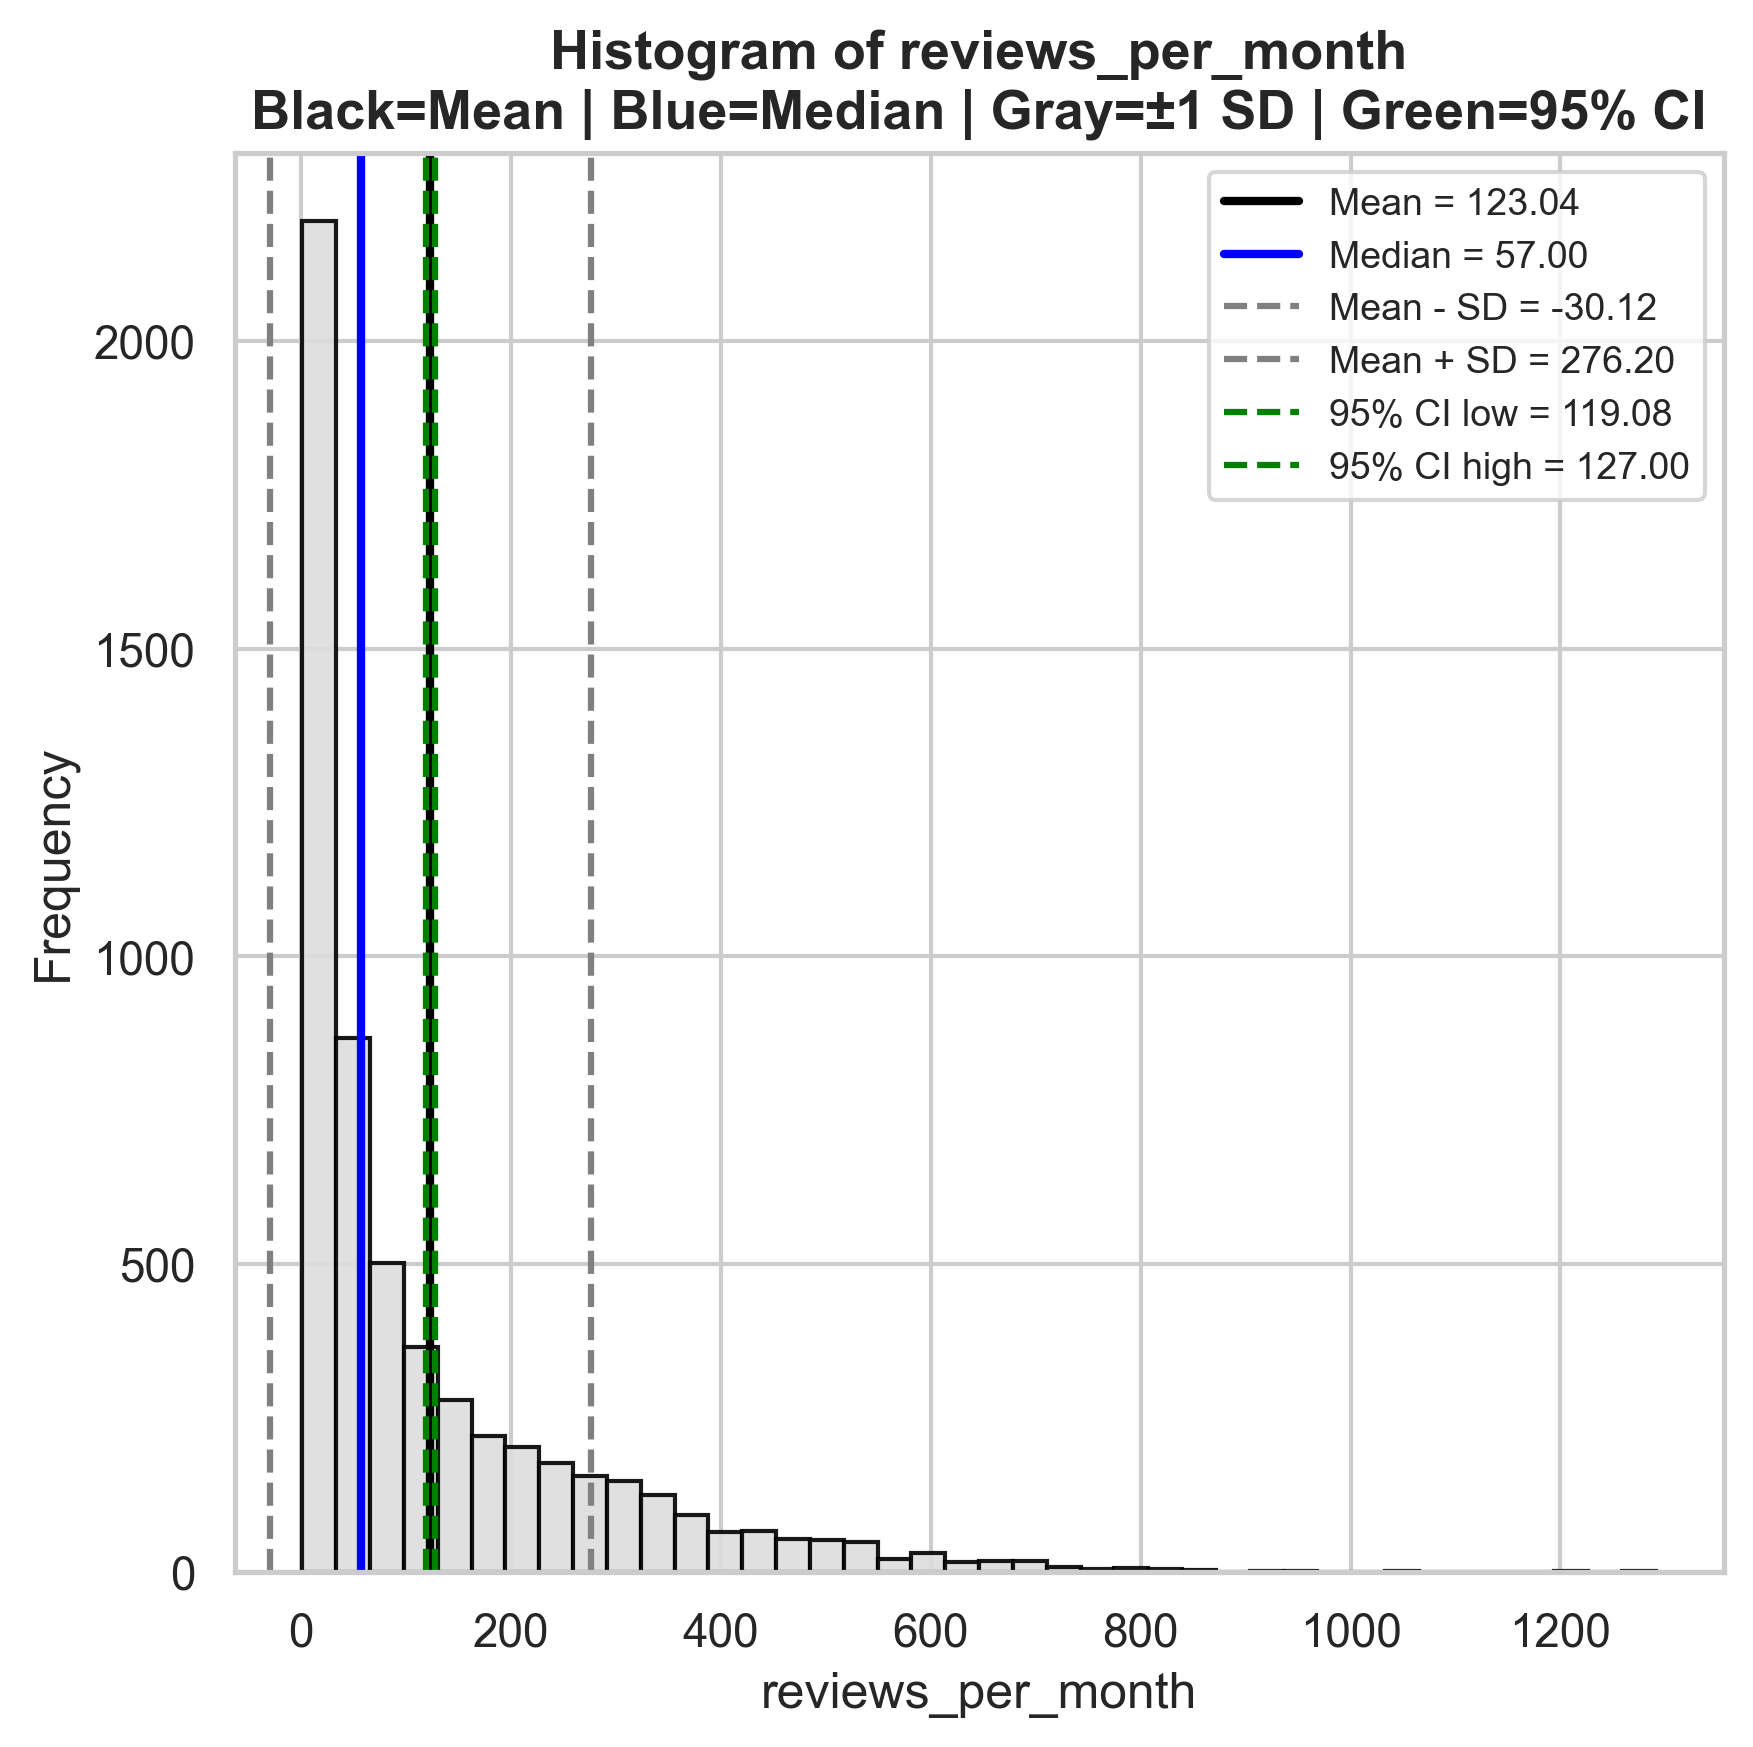

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,reviews_per_month,5747,123.041239,57.0,153.161803,119.080562,127.001916,17.0,177.0,160.0,-223.0,417.0,361,1.963949,Highly skewed.



Unique values table
Number of non-nulls: 5747
Number of unique values: 579


,column,value,count,frequency_non_null
0,reviews_per_month,1.0,76,0.013224
1,reviews_per_month,2.0,82,0.014268
2,reviews_per_month,3.0,113,0.019662
3,reviews_per_month,4.0,108,0.018792
4,reviews_per_month,5.0,109,0.018966
...,...,...,...,...
574,reviews_per_month,952.0,1,0.000174
575,reviews_per_month,1045.0,1,0.000174
576,reviews_per_month,1213.0,1,0.000174
577,reviews_per_month,1273.0,1,0.000174



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,reviews_per_month,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,reviews_per_month,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,reviews_per_month,numeric,city,categorical,Chi-square,656.268647,2.660509e-120,Significant,Statistically significant at p < 0.05.,
3,reviews_per_month,numeric,room_type,categorical,Chi-square,82.870980,1.166230e-12,Significant,Statistically significant at p < 0.05.,
4,reviews_per_month,numeric,accommodates,numeric,Pearson,-0.159347,5.391847e-34,Significant,Statistically significant at p < 0.05.,
5,reviews_per_month,numeric,bathrooms,categorical,Chi-square,251.224339,2.062296e-32,Significant,Statistically significant at p < 0.05.,
6,reviews_per_month,numeric,bedrooms,categorical,Chi-square,321.186999,8.462042e-44,Significant,Statistically significant at p < 0.05.,
7,reviews_per_month,numeric,beds,numeric,Pearson,-0.194392,4.748478e-50,Significant,Statistically significant at p < 0.05.,
8,reviews_per_month,numeric,price,numeric,Pearson,-0.191312,7.755897e-48,Significant,Statistically significant at p < 0.05.,
9,reviews_per_month,numeric,minimum_nights,numeric,Pearson,-0.112795,9.791022e-18,Significant,Statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,1.963949,Highly skewed.,Baseline.
1,Log Transformation,-0.354645,Approximately symmetric.,Improved strongly; distribution is closer to s...
2,Square Root Transformation,0.852591,Moderately skewed.,Improved; skewness decreased.
3,Box-Cox Transformation,-0.047971,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [56]:
analysis = analyze_single_field(df, 
                                target_col="reviews_per_month", 
                                results_dir=RESULTS_DIR, 
                                show_in_notebook=True)

##### **Categorical fields**

There is a hyerarchy determining Location of the accommodation:
- 'city' -> 'neighbourhood_district' -> 'neighbourhood_name'

###### Neighbourhood name

In [110]:
# Number of objects and their quota for each neighbourhood

counts = alojamentos_df['neighbourhood_name'].value_counts()
freqs = alojamentos_df['neighbourhood_name'].value_counts(normalize=True)
neighbourhood_table = pd.DataFrame({
    'count': counts,
    'frequency': freqs
})
neighbourhood_table['percentage'] = (freqs * 100).round(2)
neighbourhood_table = neighbourhood_table.reset_index()
neighbourhood_table = neighbourhood_table.rename(columns={'index': 'neighbourhood_name'})

print(neighbourhood_table.head())
print(neighbourhood_table.tail())

       neighbourhood_name  count  frequency  percentage
0  la Dreta de l'Eixample    262   0.037423        3.74
1                  Centro    227   0.032424        3.24
2             Embajadores    211   0.030139        3.01
3       Palma de Mallorca    146   0.020854        2.09
4                el Raval    141   0.020140        2.01
      neighbourhood_name  count  frequency  percentage
473     La Vall d'en Bas      1   0.000143        0.01
474  Sant Juli� de Ramis      1   0.000143        0.01
475       L'ILLA PERDUDA      1   0.000143        0.01
476      Mai� de Montcal      1   0.000143        0.01
477              B�scara      1   0.000143        0.01


In [ ]:
# Evaluation of associations with another parameters
chtest_neighb_name = chi_square_with_target(alojamentos_df, 'neighbourhood_name')

In [91]:
print(chtest_neighb_name)

         target_column         compared_column  chi2_statistic        p_value  \
0   neighbourhood_name            apartment_id      3331408.01   0.000000e+00   
1   neighbourhood_name                    name      3326157.01   0.000000e+00   
2   neighbourhood_name             description      3309400.38  1.255002e-239   
3   neighbourhood_name                 host_id      3003897.64   0.000000e+00   
4   neighbourhood_name  neighbourhood_district       254178.39   0.000000e+00   
5   neighbourhood_name               room_type         2976.64  1.255391e-110   
6   neighbourhood_name            accommodates        14897.46   0.000000e+00   
7   neighbourhood_name               bathrooms         9669.51  9.303300e-208   
8   neighbourhood_name                bedrooms        14485.32   0.000000e+00   
9   neighbourhood_name          amenities_list      3310789.39  2.316460e-171   
10  neighbourhood_name          minimum_nights        22236.17  3.719285e-113   
11  neighbourhood_name      

###### Neighbourhood district

In [112]:
# Number of objects and their quota for each neighbourhood

counts = alojamentos_df['neighbourhood_district'].value_counts()
freqs = alojamentos_df['neighbourhood_district'].value_counts(normalize=True)
neighbourhood_distr_table = pd.DataFrame({
    'count': counts,
    'frequency': freqs
})
neighbourhood_distr_table['percentage'] = (freqs * 100).round(2)
neighbourhood_distr_table = neighbourhood_distr_table.reset_index()
neighbourhood_distr_table = neighbourhood_distr_table.rename(columns={'index': 'neighbourhood_district'})

print(neighbourhood_distr_table.head())
print(neighbourhood_distr_table.tail())

  neighbourhood_district  count  frequency  percentage
0               Eixample    786   0.185334       18.53
1                 Centro    747   0.176138       17.61
2           Ciutat Vella    429   0.101155       10.12
3          Casco Antiguo    253   0.059656        5.97
4             Sant Mart�    232   0.054704        5.47
   neighbourhood_district  count  frequency  percentage
56          Cerro - Amate      3   0.000707        0.07
57       Macarena - Norte      2   0.000472        0.05
58      POBLATS DE L'OEST      1   0.000236        0.02
59              Vic�lvaro      1   0.000236        0.02
60       POBLATS DEL NORD      1   0.000236        0.02


In [113]:
# Evaluation of associations with another parameters
chtest_neighb_distr = chi_square_with_target(alojamentos_df, 'neighbourhood_district')

print(chtest_neighb_distr)

             target_column      compared_column  chi2_statistic       p_value  \
0   neighbourhood_district         apartment_id       254110.11  9.695602e-43   
1   neighbourhood_district                 name       253723.94  1.858571e-30   
2   neighbourhood_district          description       253108.02  6.643730e-23   
3   neighbourhood_district              host_id       241769.32  0.000000e+00   
4   neighbourhood_district   neighbourhood_name       254178.39  0.000000e+00   
5   neighbourhood_district            room_type          718.73  1.893516e-65   
6   neighbourhood_district         accommodates         1191.95  1.830523e-10   
7   neighbourhood_district            bathrooms          351.41  9.999976e-01   
8   neighbourhood_district             bedrooms          722.97  4.234092e-12   
9   neighbourhood_district       amenities_list       252654.68  2.862306e-18   
10  neighbourhood_district       minimum_nights         3112.33  9.765478e-43   
11  neighbourhood_district  

###### City

In [115]:
# Number of objects and their quota for each city

counts = alojamentos_df['city'].value_counts()
freqs = alojamentos_df['city'].value_counts(normalize=True)
city_table = pd.DataFrame({
    'count': counts,
    'frequency': freqs
})
city_table['percentage'] = (freqs * 100).round(2)
city_table = city_table.reset_index()
city_table = city_table.rename(columns={'index': 'neighbourhood_name'})

print(city_table)

        city  count  frequency  percentage
0  barcelona   2127   0.303814       30.38
1     madrid   1446   0.206542       20.65
2   mallorca   1144   0.163405       16.34
3     girona   1125   0.160691       16.07
4    sevilla    361   0.051564        5.16
5     malaga    350   0.049993        5.00
6   valencia    307   0.043851        4.39
7    menorca    141   0.020140        2.01


In [116]:
# Evaluation of associations with another parameters
chtest_city = chi_square_with_target(alojamentos_df, 'city')

print(chtest_city)

   target_column         compared_column  chi2_statistic        p_value  \
0           city            apartment_id        49007.00   6.981550e-10   
1           city                    name        48930.76   5.314613e-08   
2           city             description        48804.00   1.890200e-05   
3           city                 host_id        47968.49  9.988006e-318   
4           city      neighbourhood_name        48985.79   0.000000e+00   
5           city  neighbourhood_district        12723.00   0.000000e+00   
6           city               room_type         1304.80  2.270495e-263   
7           city            accommodates         2083.97   0.000000e+00   
8           city               bathrooms         1401.82  5.910536e-238   
9           city                bedrooms         2079.23   0.000000e+00   
10          city          amenities_list        48679.84   1.169439e-04   
11          city          minimum_nights         2460.44   0.000000e+00   
12          city         

###### Type of the accommodation

In [118]:
# Number of objects and their quota for each type of the rooms

counts = alojamentos_df['room_type'].value_counts()
freqs = alojamentos_df['room_type'].value_counts(normalize=True)
room_type_table = pd.DataFrame({
    'count': counts,
    'frequency': freqs
})
room_type_table['percentage'] = (freqs * 100).round(2)
room_type_table = room_type_table.reset_index()
room_type_table = room_type_table.rename(columns={'index': 'room_type'})

print(room_type_table)


         room_type  count  frequency  percentage
0  Entire home/apt   4979   0.711184       71.12
1     Private room   1942   0.277389       27.74
2      Shared room     45   0.006428        0.64
3       Hotel room     35   0.004999        0.50


In [119]:
# Evaluation of associations with another parameters
room_type_name = chi_square_with_target(alojamentos_df, 'room_type')

print(room_type_name)

   target_column         compared_column  chi2_statistic        p_value  \
0      room_type            apartment_id        20897.27   2.771725e-04   
1      room_type                    name        20890.82   9.831888e-04   
2      room_type             description        20813.19   1.397103e-02   
3      room_type                 host_id        19186.97   3.294811e-75   
4      room_type      neighbourhood_name         2976.64  1.255391e-110   
5      room_type  neighbourhood_district          718.73   1.893516e-65   
6      room_type            accommodates         4145.46   0.000000e+00   
7      room_type               bathrooms          351.05   2.616154e-53   
8      room_type                bedrooms         2608.66   0.000000e+00   
9      room_type          amenities_list        20949.49   2.307517e-03   
10     room_type          minimum_nights          664.85   8.085490e-80   
11     room_type          maximum_nights          871.54   6.731812e-40   
12     room_type        h

###### Availability condition

In [120]:
# Number of objects and their quota for each neighbourhood

counts = alojamentos_df['has_availability'].value_counts()
freqs = alojamentos_df['has_availability'].value_counts(normalize=True)
availab_cond_table = pd.DataFrame({
    'count': counts,
    'frequency': freqs
})
availab_cond_table['percentage'] = (freqs * 100).round(2)
availab_cond_table = availab_cond_table.reset_index()
availab_cond_table = availab_cond_table.rename(columns={'index': 'has_availability'})

print(availab_cond_table.head())
print(availab_cond_table.tail())

  has_availability  count  frequency  percentage
0        VERDADERO   6451        1.0       100.0
  has_availability  count  frequency  percentage
0        VERDADERO   6451        1.0       100.0


###### Instant booking condition

In [123]:
# Number of objects and their quota for each neighbourhood

counts = alojamentos_df['is_instant_bookable'].value_counts()
freqs = alojamentos_df['is_instant_bookable'].value_counts(normalize=True)
instant_book_table = pd.DataFrame({
    'count': counts,
    'frequency': freqs
})
instant_book_table['percentage'] = (freqs * 100).round(2)
instant_book_table = instant_book_table.reset_index()
instant_book_table = instant_book_table.rename(columns={'index': 'is_instant_bookable'})

print(instant_book_table)

  is_instant_bookable  count  frequency  percentage
0           VERDADERO   3740   0.534209       53.42
1               FALSO   3261   0.465791       46.58


In [124]:
# Evaluation of associations with another parameters
chtest_instant_book = chi_square_with_target(alojamentos_df, 'is_instant_bookable')

print(chtest_instant_book)

          target_column         compared_column  chi2_statistic       p_value  \
0   is_instant_bookable            apartment_id         6955.45  2.802951e-02   
1   is_instant_bookable                    name         6956.47  4.175465e-02   
2   is_instant_bookable             description         6945.88  8.983393e-02   
3   is_instant_bookable                 host_id         6631.04  1.574787e-36   
4   is_instant_bookable      neighbourhood_name          767.13  6.827280e-16   
5   is_instant_bookable  neighbourhood_district          167.80  3.851239e-12   
6   is_instant_bookable               room_type          178.07  2.297920e-38   
7   is_instant_bookable            accommodates          160.60  6.358443e-25   
8   is_instant_bookable               bathrooms           13.35  3.443547e-01   
9   is_instant_bookable                bedrooms           59.88  5.514760e-08   
10  is_instant_bookable          amenities_list         6961.69  7.238823e-02   
11  is_instant_bookable     

##### Date fields

###### First review date

In [131]:
frd_df = alojamentos_df[['apartment_id', 'host_id','first_review_date']].copy()
frd_df['first_review_date'] = pd.to_datetime(frd_df['first_review_date'], dayfirst=True)
frd_df['year'] = frd_df['first_review_date'].dt.year.astype('Int64')
frd_df['month'] = frd_df['first_review_date'].dt.month.astype('Int64')
frd_df.head(3)

,apartment_id,host_id,first_review_date,year,month
0,11964,45553,2010-01-02,2010,1
1,21853,83531,2014-10-10,2014,10
2,32347,139939,2011-01-05,2011,1


In [133]:
### BY DATE
# Number of objects and their quota for each neighbourhood

counts = frd_df['first_review_date'].value_counts()
freqs = frd_df['first_review_date'].value_counts(normalize=True)
frd_table = pd.DataFrame({
    'count': counts,
    'frequency': freqs
})
frd_table['percentage'] = (freqs * 100).round(2)
frd_table = frd_table.reset_index()
frd_table = frd_table.rename(columns={'index': 'first_review_date'})

print(frd_table.head())
print(frd_table.tail())

  first_review_date  count  frequency  percentage
0        2018-04-01     27   0.004698        0.47
1        2017-06-25     21   0.003654        0.37
2        2017-04-16     20   0.003480        0.35
3        2018-07-08     18   0.003132        0.31
4        2017-08-19     18   0.003132        0.31
     first_review_date  count  frequency  percentage
1788        2016-01-24      1   0.000174        0.02
1789        2012-03-13      1   0.000174        0.02
1790        2011-01-05      1   0.000174        0.02
1791        2014-10-10      1   0.000174        0.02
1792        2010-01-02      1   0.000174        0.02


In [144]:
### BY MONTH
# Number of objects and their quota for each neighbourhood

counts = frd_df['month'].value_counts()
freqs = frd_df['month'].value_counts(normalize=True)
frd_table = pd.DataFrame({
    'count': counts,
    'frequency': freqs
})
frd_table['percentage'] = (freqs * 100).round(2)
frd_table = frd_table.reset_index()
frd_table = frd_table.rename(columns={'index': 'month'})

print(frd_table.sort_values('month'))

    month  count  frequency  percentage
8       1    300   0.052201        5.22
9       2    286   0.049765        4.98
6       3    436   0.075866        7.59
4       4    569   0.099008         9.9
3       5    595   0.103532       10.35
2       6    648   0.112754       11.28
0       7    875   0.152253       15.23
1       8    801   0.139377       13.94
5       9    470   0.081782        8.18
7      10    337   0.058639        5.86
11     11    209   0.036367        3.64
10     12    221   0.038455        3.85


In [140]:
### BY Year
# Number of objects and their quota for each neighbourhood

counts = frd_df['year'].value_counts()
freqs = frd_df['year'].value_counts(normalize=True)
frd_table = pd.DataFrame({
    'count': counts,
    'frequency': freqs
})
frd_table['percentage'] = (freqs * 100).round(2)
frd_table = frd_table.reset_index()
frd_table = frd_table.rename(columns={'index': 'year'})

print(frd_table.sort_values('year'))

    year  count  frequency  percentage
10  2010      1   0.000174        0.02
8   2011     23   0.004002         0.4
7   2012     76   0.013224        1.32
5   2013    226   0.039325        3.93
4   2014    375   0.065251        6.53
3   2015    699   0.121629       12.16
2   2016   1232   0.214373       21.44
0   2017   1590   0.276666       27.67
1   2018   1346   0.234209       23.42
6   2019    158   0.027493        2.75
9   2020     21   0.003654        0.37


###### Last review date

In [141]:
lrd_df = alojamentos_df[['apartment_id', 'host_id','last_review_date']].copy()
lrd_df['last_review_date'] = pd.to_datetime(lrd_df['last_review_date'], dayfirst=True)
lrd_df['year'] = lrd_df['last_review_date'].dt.year.astype('Int64')
lrd_df['month'] = lrd_df['last_review_date'].dt.month.astype('Int64')
lrd_df.head(3)

,apartment_id,host_id,last_review_date,year,month
0,11964,45553,2017-09-05,2017,9
1,21853,83531,2018-07-15,2018,7
2,32347,139939,2019-07-22,2019,7


In [142]:
### BY DATE
# Number of objects and their quota for each neighbourhood

counts = lrd_df['last_review_date'].value_counts()
freqs = lrd_df['last_review_date'].value_counts(normalize=True)
lrd_table = pd.DataFrame({
    'count': counts,
    'frequency': freqs
})
lrd_table['percentage'] = (freqs * 100).round(2)
lrd_table = lrd_table.reset_index()
lrd_table = lrd_table.rename(columns={'index': 'last_review_date'})

print(lrd_table.head())
print(lrd_table.tail())

  last_review_date  count  frequency  percentage
0       2020-03-08     28   0.004873        0.49
1       2018-11-04     24   0.004177        0.42
2       2019-08-24     24   0.004177        0.42
3       2018-08-18     24   0.004177        0.42
4       2020-03-15     24   0.004177        0.42
     last_review_date  count  frequency  percentage
1454       2020-07-04      1   0.000174        0.02
1455       2018-11-28      1   0.000174        0.02
1456       2021-01-10      1   0.000174        0.02
1457       2020-09-07      1   0.000174        0.02
1458       2020-07-06      1   0.000174        0.02


In [145]:
### BY MONTH
# Number of objects and their quota for each neighbourhood

counts = lrd_df['month'].value_counts()
freqs = lrd_df['month'].value_counts(normalize=True)
lrd_table = pd.DataFrame({
    'count': counts,
    'frequency': freqs
})
lrd_table['percentage'] = (freqs * 100).round(2)
lrd_table = lrd_table.reset_index()
lrd_table = lrd_table.rename(columns={'index': 'month'})

print(lrd_table.sort_values('month'))

    month  count  frequency  percentage
6       1    408   0.071006         7.1
10      2    306   0.053254        5.33
4       3    512   0.089105        8.91
9       4    328   0.057083        5.71
8       5    364   0.063348        6.33
5       6    411   0.071528        7.15
3       7    573   0.099722        9.97
0       8    904   0.157327       15.73
1       9    682   0.118691       11.87
2      10    606   0.105465       10.55
7      11    369   0.064219        6.42
11     12    283   0.049252        4.93


In [146]:
### BY Year
# Number of objects and their quota for each neighbourhood

counts = lrd_df['year'].value_counts()
freqs = lrd_df['year'].value_counts(normalize=True)
lrd_table = pd.DataFrame({
    'count': counts,
    'frequency': freqs
})
lrd_table['percentage'] = (freqs * 100).round(2)
lrd_table = lrd_table.reset_index()
lrd_table = lrd_table.rename(columns={'index': 'year'})

print(lrd_table.sort_values('year'))

   year  count  frequency  percentage
9  2012      1   0.000174        0.02
8  2013      4   0.000696        0.07
7  2014     11   0.001914        0.19
5  2015     68   0.011834        1.18
4  2016    300    0.05221        5.22
2  2017    935   0.162722       16.27
0  2018   1828   0.318134       31.81
1  2019   1762   0.306648       30.66
3  2020    821   0.142882       14.29
6  2021     16   0.002785        0.28


###### Date of data exporting

In [147]:
insdate_df = alojamentos_df[['apartment_id', 'host_id','insert_date']].copy()
insdate_df['insert_date'] = pd.to_datetime(insdate_df['insert_date'], dayfirst=True)
insdate_df['year'] = insdate_df['insert_date'].dt.year.astype('Int64')
insdate_df['month'] = insdate_df['insert_date'].dt.month.astype('Int64')
insdate_df.head(3)

,apartment_id,host_id,insert_date,year,month
0,11964,45553,2018-07-31,2018,7
1,21853,83531,2020-01-10,2020,1
2,32347,139939,2019-07-29,2019,7


In [148]:
### BY DATE
# Number of objects and their quota for each neighbourhood

counts = insdate_df['insert_date'].value_counts()
freqs = insdate_df['insert_date'].value_counts(normalize=True)
insdate_table = pd.DataFrame({
    'count': counts,
    'frequency': freqs
})
insdate_table['percentage'] = (freqs * 100).round(2)
insdate_table = insdate_table.reset_index()
insdate_table = insdate_table.rename(columns={'index': 'insert_date'})

print(insdate_table.head())
print(insdate_table.tail())

  insert_date  count  frequency  percentage
0  2018-05-14    136   0.019426        1.94
1  2018-04-12    127   0.018140        1.81
2  2018-07-10    124   0.017712        1.77
3  2019-12-31    122   0.017426        1.74
4  2018-01-17    119   0.016998        1.70
    insert_date  count  frequency  percentage
159  2021-01-19      7   0.001000        0.10
160  2019-07-31      7   0.001000        0.10
161  2020-12-30      7   0.001000        0.10
162  2020-01-30      6   0.000857        0.09
163  2020-10-29      6   0.000857        0.09


In [149]:
### BY MONTH
# Number of objects and their quota for each neighbourhood

counts = insdate_df['month'].value_counts()
freqs = insdate_df['month'].value_counts(normalize=True)
insdate_table = pd.DataFrame({
    'count': counts,
    'frequency': freqs
})
insdate_table['percentage'] = (freqs * 100).round(2)
insdate_table = insdate_table.reset_index()
insdate_table = insdate_table.rename(columns={'index': 'month'})

print(insdate_table.sort_values('month'))

    month  count  frequency  percentage
3       1    621   0.088702        8.87
4       2    602   0.085988         8.6
10      3    526   0.075132        7.51
0       4    680   0.097129        9.71
1       5    638    0.09113        9.11
11      6    420   0.059991         6.0
6       7    593   0.084702        8.47
9       8    549   0.078417        7.84
5       9    600   0.085702        8.57
8      10    572   0.081703        8.17
2      11    622   0.088844        8.88
7      12    578    0.08256        8.26


In [150]:
### BY Year
# Number of objects and their quota for each neighbourhood

counts = insdate_df['year'].value_counts()
freqs = insdate_df['year'].value_counts(normalize=True)
insdate_table = pd.DataFrame({
    'count': counts,
    'frequency': freqs
})
insdate_table['percentage'] = (freqs * 100).round(2)
insdate_table = insdate_table.reset_index()
insdate_table = insdate_table.rename(columns={'index': 'year'})

print(insdate_table.sort_values('year'))

   year  count  frequency  percentage
3  2017    806   0.115126       11.51
1  2018   2011   0.287245       28.72
0  2019   2255   0.322097       32.21
2  2020   1661   0.237252       23.73
4  2021    268    0.03828        3.83
